In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import scipy.stats
import warnings
from scipy.stats import norm
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.3f}'.format

import pmdarima as pm
import arch
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# 데이터 불러오기
original = pd.read_csv('c:\\python\\data2(filtered).csv', dtype={2: 'str'}).iloc[:,2:7]

original = original.reset_index(drop = True)
# 신고중량이 0으로 신고된 수입건 제외
original = original.drop(original[original['신고중량'] == 0].index)
# 1년간 수입한 일수가 100일 미만은 품목 제외
#year_ago = original['수리일자'].max() - 10000
#hs_hole = list(original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts()[original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts() < 100].index)
#original = original[~original['HS10단위부호'].isin(hs_hole)]

# 연도_주차 구하기
original['수리일자'] = original['수리일자'].astype(str)
original['수리일자'] = pd.to_datetime(original['수리일자'])
original['연도'] = original['수리일자'].dt.year
original['월'] = original['수리일자'].dt.month
original['주차'] = original['수리일자'].dt.isocalendar().week
original['연도주차'] = original['연도'] * 100 + original['주차']
original['연도주차'][(original['월'] == 1) & (original['주차'] > 5)] -= 100
original['연도주차'][(original['월'] == 12) & (original['주차'] < 5)] += 100
original['연도주차'] = original['연도주차'].apply(lambda x : str(x)[2:4] + '_' + str(x)[4:])

# 전체 연도_주차 데이터 생성
date_index = original['연도주차'].unique()
# 사용하는 컬럼 정리
use_col = ['HS10단위부호', '연도주차', '무역거래처국가코드', '신고중량', '과세가격미화금액']

p_eriod = -52

HS Code : 3102109000
      연도주차    단가         신고중량
0    17_04 0.255  5332959.546
1    17_05 0.262  6013912.829
2    17_06 0.266  5785572.955
3    17_07 0.274  6293268.930
4    17_08 0.273  5994605.184
..     ...   ...          ...
292  22_34 0.685 15555657.293
293  22_35 0.675 15785998.656
294  22_36 0.667 13272932.558
295  22_37 0.668 13644743.548
296  22_38 0.678  8370437.638

[297 rows x 3 columns]
21_40주차
0    0.273
1    0.276
2    0.277
3    0.278
4    0.281
5    0.284
6    0.285
7    0.285
8    0.287
9    0.287
10   0.302
11   0.307
12   0.308
13   0.310
14   0.304
15   0.304
16   0.306
17   0.310
18   0.312
19   0.320
20   0.329
21   0.332
22   0.341
23   0.347
24   0.351
25   0.360
26   0.366
27   0.367
28   0.368
29   0.368
30   0.365
31   0.365
32   0.368
33   0.371
34   0.373
35   0.375
36   0.372
37   0.387
38   0.398
39   0.402
40   0.417
41   0.433
42   0.446
43   0.464
44   0.470
45   0.479
46   0.501
47   0.500
48   0.498
49   0.499
50   0.483
51   0.481
Name: 단가, dtype

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     4572083.900
1     5892192.336
2     8621320.361
3    10201257.261
4     8196479.362
5     6882415.227
6     8418110.158
7     7855938.056
8     8487338.055
9     8919522.904
10    4435313.673
11    6660056.188
12    6811887.337
13    7471432.525
14    7864346.467
15    5347890.630
16    7432961.455
17    8070404.966
18    8843312.073
19   10624074.923
20    8296150.698
21    8180610.250
22    8354064.775
23    8072254.700
24    8002639.450
25    8352437.450
26    8854407.613
27   10328720.263
28   11331233.588
29   10156752.738
30   10261927.073
31    9077961.354
32    8502465.854
33    8615999.854
34    7802192.782
35    7344091.600
36    6219938.750
37    6375404.451
38    7696558.251
39    6727892.449
40    7502416.181
41    7598691.656
42    6315530.731
43    7714197.942
44    7765348.082
45    7315423.024
46    8273032.774
47    9008222.665
48    8702170.893
49  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     2940932.594
1     4572083.900
2     5892192.336
3     8621320.361
4    10201257.261
5     8196479.362
6     6882415.227
7     8418110.158
8     7855938.056
9     8487338.055
10    8919522.904
11    4435313.673
12    6660056.188
13    6811887.337
14    7471432.525
15    7864346.467
16    5347890.630
17    7432961.455
18    8070404.966
19    8843312.073
20   10624074.923
21    8296150.698
22    8180610.250
23    8354064.775
24    8072254.700
25    8002639.450
26    8352437.450
27    8854407.613
28   10328720.263
29   11331233.588
30   10156752.738
31   10261927.073
32    9077961.354
33    8502465.854
34    8615999.854
35    7802192.782
36    7344091.600
37    6219938.750
38    6375404.451
39    7696558.251
40    6727892.449
41    7502416.181
42    7598691.656
43    6315530.731
44    7714197.942
45    7765348.082
46    7315423.024
47    8273032.774
48    9008222.665
49  

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     2996353.069
1     3415777.144
2     2940932.594
3     4572083.900
4     5892192.336
5     8621320.361
6    10201257.261
7     8196479.362
8     6882415.227
9     8418110.158
10    7855938.056
11    8487338.055
12    8919522.904
13    4435313.673
14    6660056.188
15    6811887.337
16    7471432.525
17    7864346.467
18    5347890.630
19    7432961.455
20    8070404.966
21    8843312.073
22   10624074.923
23    8296150.698
24    8180610.250
25    8354064.775
26    8072254.700
27    8002639.450
28    8352437.450
29    8854407.613
30   10328720.263
31   11331233.588
32   10156752.738
33   10261927.073
34    9077961.354
35    8502465.854
36    8615999.854
37    7802192.782
38    7344091.600
39    6219938.750
40    6375404.451
41    7696558.251
42    6727892.449
43    7502416.181
44    7598691.656
45    6315530.731
46    7714197.942
47    7765348.082
48    7315423.024
49  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     3575184.192
1     2996353.069
2     3415777.144
3     2940932.594
4     4572083.900
5     5892192.336
6     8621320.361
7    10201257.261
8     8196479.362
9     6882415.227
10    8418110.158
11    7855938.056
12    8487338.055
13    8919522.904
14    4435313.673
15    6660056.188
16    6811887.337
17    7471432.525
18    7864346.467
19    5347890.630
20    7432961.455
21    8070404.966
22    8843312.073
23   10624074.923
24    8296150.698
25    8180610.250
26    8354064.775
27    8072254.700
28    8002639.450
29    8352437.450
30    8854407.613
31   10328720.263
32   11331233.588
33   10156752.738
34   10261927.073
35    9077961.354
36    8502465.854
37    8615999.854
38    7802192.782
39    7344091.600
40    6219938.750
41    6375404.451
42    7696558.251
43    6727892.449
44    7502416.181
45    7598691.656
46    6315530.731
47    7714197.942
48    7765348.082
49  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     6505523.432
1     5793011.707
2     3575184.192
3     2996353.069
4     3415777.144
5     2940932.594
6     4572083.900
7     5892192.336
8     8621320.361
9    10201257.261
10    8196479.362
11    6882415.227
12    8418110.158
13    7855938.056
14    8487338.055
15    8919522.904
16    4435313.673
17    6660056.188
18    6811887.337
19    7471432.525
20    7864346.467
21    5347890.630
22    7432961.455
23    8070404.966
24    8843312.073
25   10624074.923
26    8296150.698
27    8180610.250
28    8354064.775
29    8072254.700
30    8002639.450
31    8352437.450
32    8854407.613
33   10328720.263
34   11331233.588
35   10156752.738
36   10261927.073
37    9077961.354
38    8502465.854
39    8615999.854
40    7802192.782
41    7344091.600
42    6219938.750
43    6375404.451
44    7696558.251
45    6727892.449
46    7502416.181
47    7598691.656
48    6315530.731
49  

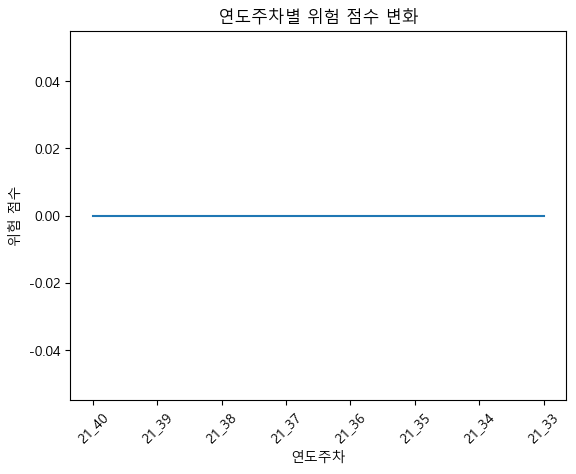

HS Code : 3707901010
      연도주차      단가      신고중량
0    17_04 219.044 17693.709
1    17_05 213.153 21010.400
2    17_06 216.113 19536.734
3    17_07 227.025 18619.221
4    17_08 223.977 18453.471
..     ...     ...       ...
292  22_34 414.585 19852.651
293  22_35 379.294 22915.441
294  22_36 378.936 22876.105
295  22_37 377.473 23998.908
296  22_38 338.724 23399.665

[297 rows x 3 columns]
19_30주차
0    232.394
1    239.664
2    243.658
3    241.069
4    270.627
5    241.770
6    275.102
7    270.882
8    274.426
9    273.856
10   243.639
11   240.823
12   231.794
13   251.146
14   277.998
15   272.614
16   292.676
17   274.076
18   287.220
19   326.250
20   296.285
21   286.282
22   246.525
23   210.616
24   234.737
25   244.200
26   254.369
27   261.244
28   261.333
29   265.613
30   314.574
31   282.201
32   294.642
33   300.052
34   298.393
35   320.318
36   326.430
37   290.426
38   265.435
39   246.845
40   263.072
41   289.953
42   264.308
43   268.393
44   240.992
45   257.939
4

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
19_25주차
0    263.955
1    257.525
2    258.863
3    226.261
4    260.158
5    232.394
6    239.664
7    243.658
8    241.069
9    270.627
10   241.770
11   275.102
12   270.882
13   274.426
14   273.856
15   243.639
16   240.823
17   231.794
18   251.146
19   277.998
20   272.614
21   292.676
22   274.076
23   287.220
24   326.250
25   296.285
26   286.282
27   246.525
28   210.616
29   234.737
30   244.200
31   254.369
32   261.244
33   261.333
34   265.613
35   314.574
36   282.201
37   294.642
38   300.052
39   298.393
40   320.318
41   326.430
42   290.426
43   265.435
44   246.845
45   263.072
46   289.953
47   264.308
48   268.393
49   240.992
50   257.939
51   281.740
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=717.080, Time=0.01 sec
 ARIMA(1

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    20625.178
1    20649.105
2    22119.247
3    21859.940
4    24197.684
5    23064.973
6    23492.327
7    25873.863
8    23569.524
9    23905.783
10   22048.571
11   23912.596
12   22698.219
13   23856.776
14   21067.980
15   20785.282
16   27609.976
17   27166.385
18   30817.958
19   26050.878
20   22238.050
21   23637.975
22   22112.843
23   23692.447
24   24448.219
25   23265.845
26   26184.196
27   28616.635
28   23505.060
29   23269.247
30   24918.181
31   21452.173
32   26369.655
33   22313.457
34   21298.425
35   20713.954
36   15445.896
37   19374.191
38   17233.539
39   16416.350
40   18044.492
41   16707.494
42   16586.676
43   19796.508
44   21651.176
45   20952.854
46   19916.705
47   17220.232
48   18771.470
49   21654.570
50   21445.539
51   22872.781
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=469.759, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=717.378, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=469.485, Time=0.08 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=467.485, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=469.422, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=456.199, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=462.547, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=454.255, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=479.223, Time=0.12 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=456.181, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.16 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercep

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    20864.880
1    20625.178
2    20649.105
3    22119.247
4    21859.940
5    24197.684
6    23064.973
7    23492.327
8    25873.863
9    23569.524
10   23905.783
11   22048.571
12   23912.596
13   22698.219
14   23856.776
15   21067.980
16   20785.282
17   27609.976
18   27166.385
19   30817.958
20   26050.878
21   22238.050
22   23637.975
23   22112.843
24   23692.447
25   24448.219
26   23265.845
27   26184.196
28   28616.635
29   23505.060
30   23269.247
31   24918.181
32   21452.173
33   26369.655
34   22313.457
35   21298.425
36   20713.954
37   15445.896
38   19374.191
39   17233.539
40   16416.350
41   18044.492
42   16707.494
43   16586.676
44   19796.508
45   21651.176
46   20952.854
47   19916.705
48   17220.232
49   18771.470
50   21654.570
51   21445.539
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   

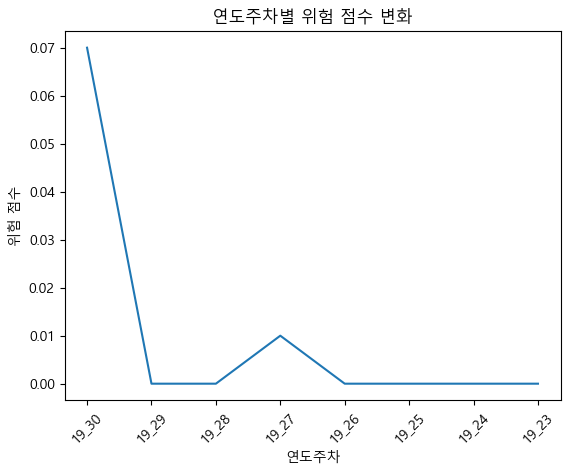

HS Code : 4407191000
      연도주차    단가       신고중량
0    17_04 1.321 239293.247
1    17_05 1.320 250460.747
2    17_06 1.335 267243.948
3    17_07 1.353 205743.000
4    17_08 1.355 166353.875
..     ...   ...        ...
292  22_34 1.459  46860.691
293  22_35 1.597  55567.169
294  22_36 1.587  60067.169
295  22_37 1.328  54362.169
296  22_38 1.313  49607.857

[297 rows x 3 columns]
21_14주차
0    1.168
1    1.273
2    1.278
3    1.296
4    1.307
5    1.282
6    1.246
7    1.225
8    1.222
9    1.217
10   1.240
11   1.241
12   1.239
13   1.256
14   1.291
15   1.279
16   1.276
17   1.256
18   1.236
19   1.272
20   1.268
21   1.283
22   1.301
23   1.275
24   1.316
25   1.192
26   1.178
27   1.191
28   1.172
29   1.283
30   1.298
31   1.299
32   1.309
33   1.323
34   1.315
35   1.257
36   1.252
37   1.248
38   1.271
39   1.309
40   1.326
41   1.275
42   1.288
43   1.294
44   1.303
45   1.369
46   1.390
47   1.353
48   1.318
49   1.269
50   1.271
51   1.276
Name: 단가, dtype: float64
Performing ste

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    232849.132
1    208142.443
2    212974.443
3    174660.487
4    192153.237
5    174147.462
6    208127.462
7    197927.225
8    169040.725
9    189372.250
10   165649.963
11   171324.713
12   171240.088
13   180231.838
14   141282.547
15   167364.547
16   177168.922
17   156222.672
18   213491.250
19   192786.750
20   188341.750
21   193563.500
22   174705.000
23   172996.750
24   184079.750
25   285911.500
26   259840.750
27   241460.250
28   269135.500
29   163658.500
30   178406.150
31   201221.900
32   191856.150
33   202767.150
34   214060.000
35   232524.750
36   251751.250
37   275461.250
38   300222.750
39   298335.750
40   234772.250
41   256456.250
42   313227.000
43   288588.500
44   311393.500
45   230289.000
46   107791.719
47   123319.969
48   108600.531
49   140338.781
50   188917.062
51   158085.312
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_13주차
0    1.207
1    1.168
2    1.273
3    1.278
4    1.296
5    1.307
6    1.282
7    1.246
8    1.225
9    1.222
10   1.217
11   1.240
12   1.241
13   1.239
14   1.256
15   1.291
16   1.279
17   1.276
18   1.256
19   1.236
20   1.272
21   1.268
22   1.283
23   1.301
24   1.275
25   1.316
26   1.192
27   1.178
28   1.191
29   1.172
30   1.283
31   1.298
32   1.299
33   1.309
34   1.323
35   1.315
36   1.257
37   1.252
38   1.248
39   1.271
40   1.309
41   1.326
42   1.275
43   1.288
44   1.294
45   1.303
46   1.369
47   1.390
48   1.353
49   1.318
50   1.269
51   1.271
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-182.555, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-180.634, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-18

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_07주차
0    1.268
1    1.253
2    1.261
3    1.290
4    1.208
5    1.205
6    1.207
7    1.168
8    1.273
9    1.278
10   1.296
11   1.307
12   1.282
13   1.246
14   1.225
15   1.222
16   1.217
17   1.240
18   1.241
19   1.239
20   1.256
21   1.291
22   1.279
23   1.276
24   1.256
25   1.236
26   1.272
27   1.268
28   1.283
29   1.301
30   1.275
31   1.316
32   1.192
33   1.178
34   1.191
35   1.172
36   1.283
37   1.298
38   1.299
39   1.309
40   1.323
41   1.315
42   1.257
43   1.252
44   1.248
45   1.271
46   1.309
47   1.326
48   1.275
49   1.288
50   1.294
51   1.303
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=170.440, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     91211.383
1     94948.500
2    138382.343
3    188889.978
4    240923.167
5    245405.167
6    255033.016
7    232849.132
8    208142.443
9    212974.443
10   174660.487
11   192153.237
12   174147.462
13   208127.462
14   197927.225
15   169040.725
16   189372.250
17   165649.963
18   171324.713
19   171240.088
20   180231.838
21   141282.547
22   167364.547
23   177168.922
24   156222.672
25   213491.250
26   192786.750
27   188341.750
28   193563.500
29   174705.000
30   172996.750
31   184079.750
32   285911.500
33   259840.750
34   241460.250
35   269135.500
36   163658.500
37   178406.150
38   201221.900
39   191856.150
40   202767.150
41   214060.000
42   232524.750
43   251751.250
44   275461.250
45   300222.750
46   298335.750
47   234772.250
48   256456.250
49   313227.000
50   288588.500
51   311393.500
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


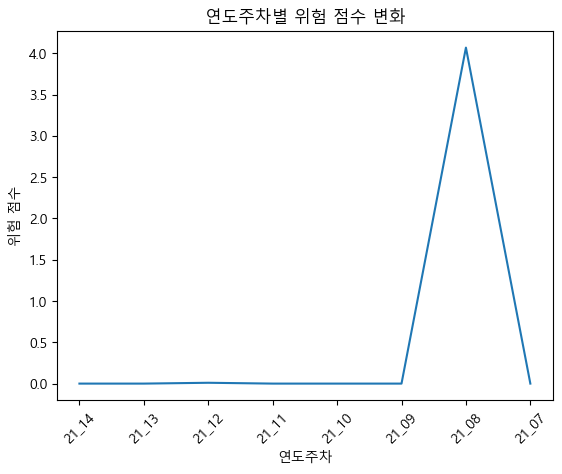

HS Code : 8111000000
      연도주차    단가        신고중량
0    17_04 2.294 1589538.823
1    17_05 2.322 1797062.025
2    17_06 2.349 2135029.125
3    17_07 2.255 2589847.688
4    17_08 2.222 2647460.135
..     ...   ...         ...
292  22_34 2.417 1887338.301
293  22_35 2.470 1322372.493
294  22_36 2.402 1172857.531
295  22_37 2.328 1437803.669
296  22_38 2.315  991759.689

[297 rows x 3 columns]
21_45주차
0    1.529
1    1.524
2    1.523
3    1.519
4    1.540
5    1.577
6    1.619
7    1.670
8    1.729
9    1.849
10   1.911
11   1.981
12   2.053
13   2.281
14   2.331
15   2.448
16   2.445
17   2.461
18   2.481
19   2.490
20   2.479
21   2.496
22   2.483
23   2.499
24   2.559
25   2.567
26   2.589
27   2.603
28   2.582
29   2.566
30   2.541
31   2.551
32   2.547
33   2.577
34   2.583
35   2.612
36   2.658
37   2.695
38   2.774
39   2.806
40   2.897
41   3.019
42   3.186
43   3.614
44   3.963
45   4.185
46   4.269
47   4.371
48   4.494
49   4.554
50   4.631
51   4.919
Name: 단가, dtype: float64
Pe

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-126.258, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-97.645, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-129.957, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-115.437, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-80.044, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-128.215, Time=0.10 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-128.135, Time=0.07 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-127.245, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-128.956, Time=0.02 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 0.609 seconds


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1864895.908
1    1838912.570
2    1881359.907
3    2331514.192
4    2123058.496
5    1726439.953
6    2127137.453
7    1450353.759
8    1715679.800
9    1913412.288
10   1845113.619
11   1992666.875
12   1927276.746
13   1775287.477
14   1647085.896
15   2087361.094
16   1930276.436
17   1892042.360
18   2327552.947
19   2080499.897
20   1978193.060
21   2013177.680
22   1261457.280
23   1229109.535
24   1599007.763
25   1391967.667
26   1454628.980
27   1914836.804
28   1866438.329
29   2335814.701
30   2427450.519
31   2029275.732
32   2095024.151
33   1781438.359
34   1602083.096
35   1677452.446
36   1452950.308
37   1621217.283
38   1848261.698
39   1840776.135
40   1795978.520
41   1959161.235
42   1715385.078
43   1304780.421
44   1465378.476
45   1293928.439
46   1331297.794
47   1507800.150
48   1262928.720
49   1258666.346
50   1324774.866
51   1649782.991
Na

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1503132.158
1    1716228.895
2    1499314.407
3    1864895.908
4    1838912.570
5    1881359.907
6    2331514.192
7    2123058.496
8    1726439.953
9    2127137.453
10   1450353.759
11   1715679.800
12   1913412.288
13   1845113.619
14   1992666.875
15   1927276.746
16   1775287.477
17   1647085.896
18   2087361.094
19   1930276.436
20   1892042.360
21   2327552.947
22   2080499.897
23   1978193.060
24   2013177.680
25   1261457.280
26   1229109.535
27   1599007.763
28   1391967.667
29   1454628.980
30   1914836.804
31   1866438.329
32   2335814.701
33   2427450.519
34   2029275.732
35   2095024.151
36   1781438.359
37   1602083.096
38   1677452.446
39   1452950.308
40   1621217.283
41   1848261.698
42   1840776.135
43   1795978.520
44   1959161.235
45   1715385.078
46   1304780.421
47   1465378.476
48   1293928.439
49   1331297.794
50   1507800.150
51   1262928.720
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1616.082, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1431.044, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1584.471, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1429.594, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1428.668, Time=0.09 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1429.222, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1425.765, Time=0.08 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=1421.777, Time=0.07 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=1422.820, Time=0.06 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=1410.816, Time=0.19 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=1418.338, Time=0.27 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=1415.990, Time=0.15 sec
 ARIMA(5,0,1)(0,0,0)[0] i

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1526437.145
1    1216028.464
2    1503132.158
3    1716228.895
4    1499314.407
5    1864895.908
6    1838912.570
7    1881359.907
8    2331514.192
9    2123058.496
10   1726439.953
11   2127137.453
12   1450353.759
13   1715679.800
14   1913412.288
15   1845113.619
16   1992666.875
17   1927276.746
18   1775287.477
19   1647085.896
20   2087361.094
21   1930276.436
22   1892042.360
23   2327552.947
24   2080499.897
25   1978193.060
26   2013177.680
27   1261457.280
28   1229109.535
29   1599007.763
30   1391967.667
31   1454628.980
32   1914836.804
33   1866438.329
34   2335814.701
35   2427450.519
36   2029275.732
37   2095024.151
38   1781438.359
39   1602083.096
40   1677452.446
41   1452950.308
42   1621217.283
43   1848261.698
44   1840776.135
45   1795978.520
46   1959161.235
47   1715385.078
48   1304780.421
49   1465378.476
50   1293928.439
51   1331297.794
Na

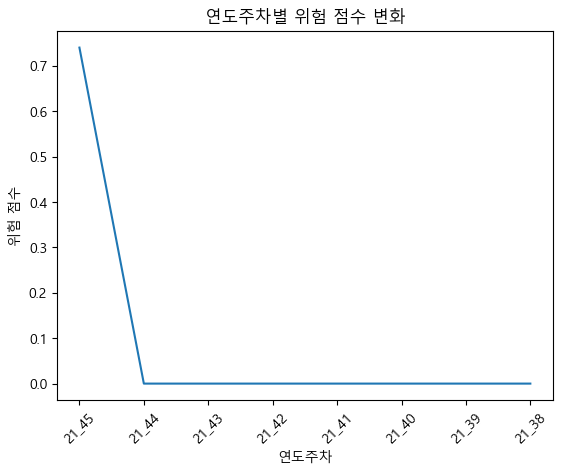

HS Code : 2701129010
      연도주차    단가          신고중량
0    17_04 0.177 163414532.500
1    17_05 0.183 128339537.000
2    17_06 0.187  77542167.000
3    17_07 0.178  87019096.075
4    17_08 0.165 107989167.275
..     ...   ...           ...
292  22_34 0.285 145518255.411
293  22_35 0.274 197342702.911
294  22_36 0.280 214007115.594
295  22_37 0.268 198569715.141
296  22_38 0.273 160074550.041

[297 rows x 3 columns]
21_51주차
0    0.103
1    0.107
2    0.107
3    0.110
4    0.113
5    0.116
6    0.116
7    0.126
8    0.122
9    0.119
10   0.127
11   0.123
12   0.136
13   0.134
14   0.131
15   0.127
16   0.116
17   0.115
18   0.130
19   0.130
20   0.130
21   0.131
22   0.120
23   0.128
24   0.134
25   0.134
26   0.137
27   0.138
28   0.134
29   0.133
30   0.151
31   0.167
32   0.174
33   0.184
34   0.187
35   0.196
36   0.192
37   0.191
38   0.190
39   0.186
40   0.187
41   0.210
42   0.248
43   0.243
44   0.252
45   0.255
46   0.256
47   0.270
48   0.265
49   0.261
50   0.279
51   0.290
Nam

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    225731607.798
1    183787999.567
2    224709651.750
3    202500680.500
4    217664043.000
5    242124105.935
6    234179063.435
7    209051809.935
8    270433729.435
9    246078410.135
10   236893702.635
11   274214557.385
12   221917945.020
13   306853383.385
14   279513383.385
15   233950465.885
16   161579432.000
17   130868025.000
18   197016285.000
19   204183060.500
20   221980002.213
21   208183477.213
22   153015439.713
23   199522831.713
24   238091066.250
25   252316802.250
26   277259142.250
27   250790692.250
28   204994413.750
29   171660050.312
30   198360228.343
31   183492035.843
32   209718206.593
33   189149366.030
34   128546625.500
35   122018825.500
36   150357287.812
37   232514775.562
38   228022300.562
39   184764075.562
40   141161503.338
41    91263233.588
42   134879871.458
43   140552371.458
44   133248162.870
45    90026962.025
46    653875

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1886.301, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1892.165, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1894.170, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1894.181, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1890.275, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1892.256, Time=0.08 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1894.886, Time=0.05 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=1886.890, Time=0.13 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=1890.065, Time=0.12 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.07 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1893.300, Time=0.09 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=1895.638, Time=0.05 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=1885.096, Time=0.20 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.28 sec
 ARIMA(3,1,4)(0,0,0)[0] intercept   : AIC=inf, Time=0.28 sec
 ARIMA(2,1,4)(0,0,0)[0] i

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    189521504.668
1    157750269.985
2    219737703.548
3    225731607.798
4    183787999.567
5    224709651.750
6    202500680.500
7    217664043.000
8    242124105.935
9    234179063.435
10   209051809.935
11   270433729.435
12   246078410.135
13   236893702.635
14   274214557.385
15   221917945.020
16   306853383.385
17   279513383.385
18   233950465.885
19   161579432.000
20   130868025.000
21   197016285.000
22   204183060.500
23   221980002.213
24   208183477.213
25   153015439.713
26   199522831.713
27   238091066.250
28   252316802.250
29   277259142.250
30   250790692.250
31   204994413.750
32   171660050.312
33   198360228.343
34   183492035.843
35   209718206.593
36   189149366.030
37   128546625.500
38   122018825.500
39   150357287.812
40   232514775.562
41   228022300.562
42   184764075.562
43   141161503.338
44    91263233.588
45   134879871.458
46   1405523

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0    0.104
1    0.111
2    0.106
3    0.107
4    0.107
5    0.103
6    0.107
7    0.107
8    0.110
9    0.113
10   0.116
11   0.116
12   0.126
13   0.122
14   0.119
15   0.127
16   0.123
17   0.136
18   0.134
19   0.131
20   0.127
21   0.116
22   0.115
23   0.130
24   0.130
25   0.130
26   0.131
27   0.120
28   0.128
29   0.134
30   0.134
31   0.137
32   0.138
33   0.134
34   0.133
35   0.151
36   0.167
37   0.174
38   0.184
39   0.187
40   0.196
41   0.192
42   0.191
43   0.190
44   0.186
45   0.187
46   0.210
47   0.248
48   0.243
49   0.252
50   0.255
51   0.256
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-323.400, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-330.328, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-329.281, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AI

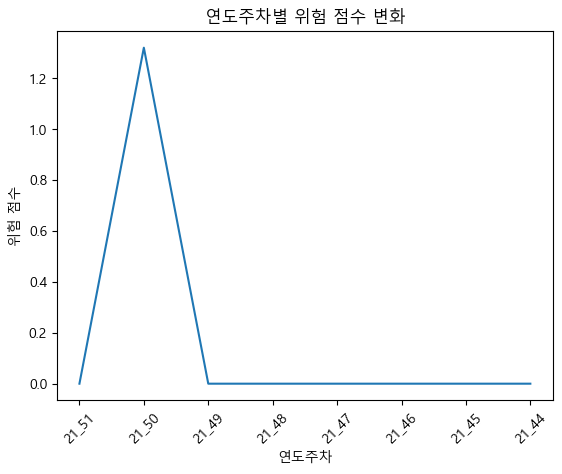

HS Code : 2804701000
      연도주차    단가       신고중량
0    17_04 2.811 160032.550
1    17_05 2.856 164322.550
2    17_06 2.862 142277.500
3    17_07 2.849 143690.000
4    17_08 2.827 128430.000
..     ...   ...        ...
292  22_34 7.502 144652.712
293  22_35 7.193 160465.212
294  22_36 7.270 198465.212
295  22_37 7.206 209505.000
296  22_38 7.230 164662.500

[297 rows x 3 columns]
21_51주차
0    2.941
1    3.446
2    3.332
3    3.499
4    3.310
5    2.799
6    2.863
7    2.831
8    2.821
9    2.890
10   2.824
11   2.865
12   2.883
13   2.876
14   2.908
15   2.917
16   2.906
17   2.891
18   2.912
19   2.931
20   2.909
21   2.869
22   2.830
23   2.816
24   2.820
25   2.829
26   2.819
27   2.800
28   2.900
29   2.929
30   2.988
31   3.028
32   3.024
33   3.037
34   3.074
35   3.121
36   3.081
37   3.062
38   3.018
39   3.040
40   3.063
41   3.375
42   3.465
43   4.208
44   4.980
45   5.144
46   5.250
47   5.232
48   5.226
49   5.269
50   5.266
51   5.299
Name: 단가, dtype: float64
Performing ste

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    254742.525
1    178310.470
2    196105.482
3    147182.957
4    187867.957
5    262452.513
6    280122.500
7    252057.500
8    253210.000
9    211705.000
10   222757.500
11   283655.000
12   246677.500
13   237352.500
14   224752.500
15   209272.500
16   171292.500
17   187030.000
18   150935.000
19   106027.500
20   161752.750
21   214187.750
22   202865.250
23   249897.750
24   274160.106
25   187000.106
26   197975.106
27   184582.606
28   152185.000
29   207612.500
30   225595.000
31   212912.506
32   234002.506
33   193567.506
34   283595.006
35   243605.000
36   201602.500
37   295390.000
38   202497.500
39   221440.050
40   290885.050
41   230882.550
42   187692.550
43   263942.500
44   245167.500
45   205882.500
46   257912.500
47   219172.500
48   177952.500
49   331577.500
50   326935.000
51   302522.606
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_50주차
0    2.884
1    2.941
2    3.446
3    3.332
4    3.499
5    3.310
6    2.799
7    2.863
8    2.831
9    2.821
10   2.890
11   2.824
12   2.865
13   2.883
14   2.876
15   2.908
16   2.917
17   2.906
18   2.891
19   2.912
20   2.931
21   2.909
22   2.869
23   2.830
24   2.816
25   2.820
26   2.829
27   2.819
28   2.800
29   2.900
30   2.929
31   2.988
32   3.028
33   3.024
34   3.037
35   3.074
36   3.121
37   3.081
38   3.062
39   3.018
40   3.040
41   3.063
42   3.375
43   3.465
44   4.208
45   4.980
46   5.144
47   5.250
48   5.232
49   5.226
50   5.269
51   5.266
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-21.853, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-19.656, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-25.251, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    240420.000
1    253835.025
2    254742.525
3    178310.470
4    196105.482
5    147182.957
6    187867.957
7    262452.513
8    280122.500
9    252057.500
10   253210.000
11   211705.000
12   222757.500
13   283655.000
14   246677.500
15   237352.500
16   224752.500
17   209272.500
18   171292.500
19   187030.000
20   150935.000
21   106027.500
22   161752.750
23   214187.750
24   202865.250
25   249897.750
26   274160.106
27   187000.106
28   197975.106
29   184582.606
30   152185.000
31   207612.500
32   225595.000
33   212912.506
34   234002.506
35   193567.506
36   283595.006
37   243605.000
38   201602.500
39   295390.000
40   202497.500
41   221440.050
42   290885.050
43   230882.550
44   187692.550
45   263942.500
46   245167.500
47   205882.500
48   257912.500
49   219172.500
50   177952.500
51   331577.500
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
0    3.003
1    2.965
2    2.951
3    2.920
4    2.930
5    2.884
6    2.941
7    3.446
8    3.332
9    3.499
10   3.310
11   2.799
12   2.863
13   2.831
14   2.821
15   2.890
16   2.824
17   2.865
18   2.883
19   2.876
20   2.908
21   2.917
22   2.906
23   2.891
24   2.912
25   2.931
26   2.909
27   2.869
28   2.830
29   2.816
30   2.820
31   2.829
32   2.819
33   2.800
34   2.900
35   2.929
36   2.988
37   3.028
38   3.024
39   3.037
40   3.074
41   3.121
42   3.081
43   3.062
44   3.018
45   3.040
46   3.063
47   3.375
48   3.465
49   4.208
50   4.980
51   5.144
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-14.164, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=261.099, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    149527.500
1    212565.000
2    203110.000
3    209822.500
4    240420.000
5    253835.025
6    254742.525
7    178310.470
8    196105.482
9    147182.957
10   187867.957
11   262452.513
12   280122.500
13   252057.500
14   253210.000
15   211705.000
16   222757.500
17   283655.000
18   246677.500
19   237352.500
20   224752.500
21   209272.500
22   171292.500
23   187030.000
24   150935.000
25   106027.500
26   161752.750
27   214187.750
28   202865.250
29   249897.750
30   274160.106
31   187000.106
32   197975.106
33   184582.606
34   152185.000
35   207612.500
36   225595.000
37   212912.506
38   234002.506
39   193567.506
40   283595.006
41   243605.000
42   201602.500
43   295390.000
44   202497.500
45   221440.050
46   290885.050
47   230882.550
48   187692.550
49   263942.500
50   245167.500
51   205882.500
Name: 신고중량, dtype: float64
Performing stepwise search 

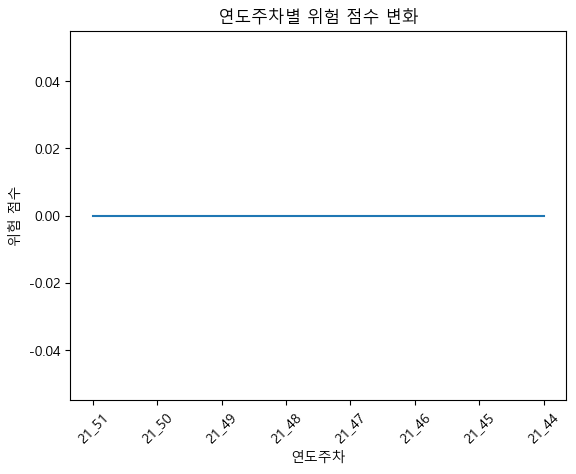

HS Code : 1511901000
      연도주차    단가        신고중량
0    17_04 0.735  936849.355
1    17_05 0.734  930738.055
2    17_06 0.754  893311.305
3    17_07 0.756 1637404.305
4    17_08 0.774 1212247.700
..     ...   ...         ...
292  22_34 1.468  759382.356
293  22_35 1.501  785201.626
294  22_36 1.488  774298.645
295  22_37 1.569  271958.020
296  22_38 1.391  698774.770

[297 rows x 3 columns]
22_02주차
0    0.938
1    0.929
2    0.964
3    0.970
4    1.038
5    1.039
6    1.047
7    1.055
8    1.030
9    1.030
10   1.033
11   1.022
12   1.038
13   1.037
14   1.030
15   1.036
16   1.043
17   1.050
18   1.048
19   1.040
20   1.088
21   1.083
22   1.091
23   1.091
24   1.162
25   1.105
26   1.101
27   1.101
28   1.102
29   1.106
30   1.106
31   1.109
32   1.108
33   1.101
34   1.080
35   1.079
36   1.080
37   1.099
38   1.122
39   1.122
40   1.120
41   1.109
42   1.141
43   1.204
44   1.204
45   1.204
46   1.318
47   1.342
48   1.344
49   1.343
50   1.368
51   1.381
Name: 단가, dtype: float64
Pe

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1436.560, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1565.477, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1441.891, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1533.350, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1435.781, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1527.919, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1437.442, Time=0.02 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=1437.928, Time=0.07 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=1525.339, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1435.988, Time=0.02 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=1438.123, Time=0.13 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=1432.000, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=1431.306, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1429.503, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1436.978, Time=0.01 sec
 ARIMA(1,0

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1263995.631
1     963353.856
2    1457994.656
3    1457994.550
4    1537650.550
5    1535177.550
6    1032601.750
7    1655937.250
8     901391.250
9     973333.000
10   1148300.000
11   1083733.000
12   1088981.800
13    763810.916
14   1151875.166
15   1176337.916
16   1176921.116
17   1216909.500
18    654403.250
19   1242982.505
20   1237151.685
21   1172861.685
22   1246969.185
23    993985.680
24   1034286.500
25   1033762.562
26    959130.562
27    998984.062
28    958687.062
29   1065545.500
30   1065545.000
31    106864.500
32    505444.000
33   1275959.425
34   1275959.425
35   1281584.425
36    987838.425
37    490000.475
38    495087.975
39    489462.975
40    564624.475
41   1008377.250
42   1013817.250
43   1017617.250
44    986828.000
45   1091162.500
46   1080635.500
47   1076840.000
48    932494.250
49    834659.750
50   1345274.250
51   1345279.750
Na

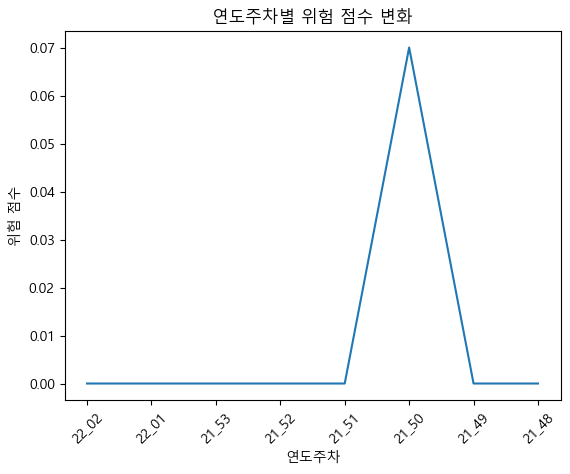

HS Code : 305531000
      연도주차     단가       신고중량
0    17_04 10.143 112739.000
1    17_05 10.020 106671.250
2    17_06  9.953 107973.500
3    17_07  9.665  98612.500
4    17_08  9.570  93437.500
..     ...    ...        ...
292  22_34 10.917 132790.114
293  22_35 10.543 146227.391
294  22_36 10.839 132587.659
295  22_37 10.828 108393.587
296  22_38 10.431  98649.147

[297 rows x 3 columns]
22_07주차
0    10.195
1    10.037
2    10.390
3    10.453
4    10.162
5     9.852
6     9.621
7     9.196
8     9.350
9     9.638
10   10.013
11    9.977
12   10.147
13   10.167
14    9.490
15    9.620
16    9.601
17    9.705
18   10.421
19   10.462
20   10.554
21   10.553
22   10.477
23   10.527
24   10.073
25   10.360
26   10.401
27   10.182
28   10.092
29    9.916
30    9.802
31   10.003
32   10.436
33   10.247
34    9.902
35    9.951
36   10.039
37    9.968
38   10.168
39    9.876
40    9.483
41    9.885
42   10.229
43   10.752
44   11.275
45   11.267
46   11.123
47   11.133
48   11.177
49   11.263


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    109895.575
1     94605.349
2    119550.149
3    125476.449
4    146197.870
5    150753.546
6    140290.640
7    128867.112
8    114120.290
9    106992.423
10   101408.020
11   121817.874
12   125381.400
13   152749.953
14   164129.761
15   156312.136
16   155368.886
17   131997.200
18   147524.700
19   141420.950
20   163775.950
21   152476.650
22   135051.675
23   136310.425
24   121478.925
25   122820.025
26   123487.025
27   128552.833
28   134701.334
29   159496.571
30   138344.546
31   135972.598
32   134916.348
33   117055.535
34   141450.535
35   183725.625
36   217210.145
37   250383.895
38   253445.520
39   217404.070
40   188713.705
41   170419.833
42   172665.066
43   163551.146
44   155913.791
45   110987.989
46   108721.130
47    89789.350
48   115454.990
49   129676.618
50   101362.868
51   109106.643
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_04주차
0     9.967
1     9.942
2    10.309
3    10.195
4    10.037
5    10.390
6    10.453
7    10.162
8     9.852
9     9.621
10    9.196
11    9.350
12    9.638
13   10.013
14    9.977
15   10.147
16   10.167
17    9.490
18    9.620
19    9.601
20    9.705
21   10.421
22   10.462
23   10.554
24   10.553
25   10.477
26   10.527
27   10.073
28   10.360
29   10.401
30   10.182
31   10.092
32    9.916
33    9.802
34   10.003
35   10.436
36   10.247
37    9.902
38    9.951
39   10.039
40    9.968
41   10.168
42    9.876
43    9.483
44    9.885
45   10.229
46   10.752
47   11.275
48   11.267
49   11.123
50   11.133
51   11.177
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=383.163, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1128.901, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1130.747, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1130.922, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1126.974, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1132.573, Time=0.05 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.235 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_53주차
0    10.391
1     9.905
2     9.881
3     9.969
4     9.967
5     9.942
6    10.309
7    10.195
8    10.037
9    10.390
10   10.453
11   10.162
12    9.852
13    9.621
14    9.196
15    9.350
16    9.638
17   10.013
18    9.977
19   10.147
20   10.167
21    9.490
22    9.620
23    9.601
24    9.705
25   10.421
26   10.462
27   10.554
28   10.553
29   10.477
30   10.527
31   10.073
32   10.360
33   10.401
34

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=382.198, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=26.789, Time=0.07 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=8.471, Time=0.11 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=12.402, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=21.811, Time=0.12 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=37.157, Time=0.01 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec
 ARIMA

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


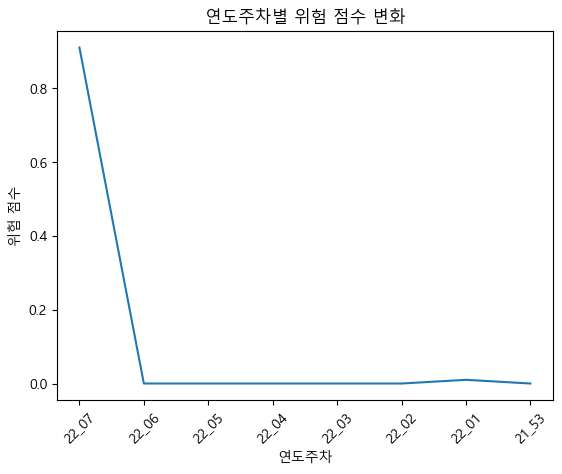

HS Code : 302140000
      연도주차     단가       신고중량
0    17_04 12.297 248997.765
1    17_05 11.776 247770.110
2    17_06 11.204 258943.758
3    17_07 10.781 262438.498
4    17_08 10.400 279016.205
..     ...    ...        ...
292  22_34 13.914 361472.777
293  22_35 13.643 378891.888
294  22_36 13.112 381338.341
295  22_37 12.738 381753.838
296  22_38 12.394 386434.054

[297 rows x 3 columns]
22_08주차
0     9.300
1     9.672
2     9.979
3    10.184
4    10.329
5    10.529
6    10.716
7    10.961
8    11.144
9    11.442
10   11.862
11   12.057
12   11.951
13   11.591
14   11.142
15   10.882
16   10.815
17   10.860
18   10.877
19   10.978
20   11.150
21   11.291
22   11.276
23   10.982
24   10.477
25    9.980
26    9.511
27    9.247
28    9.175
29    9.185
30    9.278
31    9.490
32    9.675
33    9.960
34   10.165
35   10.085
36    9.902
37    9.799
38    9.744
39    9.815
40   10.170
41   10.750
42   11.324
43   11.664
44   11.969
45   11.867
46   11.705
47   11.741
48   11.693
49   11.803


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    615575.662
1    615668.297
2    608740.494
3    627113.382
4    585409.915
5    590562.853
6    581756.949
7    566239.359
8    605266.935
9    607921.714
10   610291.216
11   587542.344
12   568714.768
13   554575.273
14   548016.885
15   551181.215
16   555615.528
17   545638.383
18   529042.071
19   525406.401
20   509545.128
21   500883.440
22   518561.440
23   510946.748
24   514015.178
25   528387.253
26   539033.973
27   631475.125
28   586985.324
29   629805.906
30   642438.201
31   577162.016
32   615438.152
33   569505.405
34   552960.362
35   549822.237
36   571503.554
37   590480.932
38   589051.338
39   565396.492
40   577042.093
41   601337.080
42   632981.690
43   507369.182
44   512505.143
45   475348.563
46   438346.065
47   642530.095
48   555571.410
49   555137.095
50   567404.683
51   494787.818
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_07주차
0     8.719
1     9.300
2     9.672
3     9.979
4    10.184
5    10.329
6    10.529
7    10.716
8    10.961
9    11.144
10   11.442
11   11.862
12   12.057
13   11.951
14   11.591
15   11.142
16   10.882
17   10.815
18   10.860
19   10.877
20   10.978
21   11.150
22   11.291
23   11.276
24   10.982
25   10.477
26    9.980
27    9.511
28    9.247
29    9.175
30    9.185
31    9.278
32    9.490
33    9.675
34    9.960
35   10.165
36   10.085
37    9.902
38    9.799
39    9.744
40    9.815
41   10.170
42   10.750
43   11.324
44   11.664
45   11.969
46   11.867
47   11.705
48   11.741
49   11.693
50   11.803
51   12.216
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-25.213, Time=0.16 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=387.957, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    560299.449
1    559853.442
2    567748.774
3    588090.171
4    590361.155
5    615575.662
6    615668.297
7    608740.494
8    627113.382
9    585409.915
10   590562.853
11   581756.949
12   566239.359
13   605266.935
14   607921.714
15   610291.216
16   587542.344
17   568714.768
18   554575.273
19   548016.885
20   551181.215
21   555615.528
22   545638.383
23   529042.071
24   525406.401
25   509545.128
26   500883.440
27   518561.440
28   510946.748
29   514015.178
30   528387.253
31   539033.973
32   631475.125
33   586985.324
34   629805.906
35   642438.201
36   577162.016
37   615438.152
38   569505.405
39   552960.362
40   549822.237
41   571503.554
42   590480.932
43   589051.338
44   565396.492
45   577042.093
46   601337.080
47   632981.690
48   507369.182
49   512505.143
50   475348.563
51   438346.065
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_02주차
0     8.298
1     8.031
2     7.962
3     8.044
4     8.228
5     8.719
6     9.300
7     9.672
8     9.979
9    10.184
10   10.329
11   10.529
12   10.716
13   10.961
14   11.144
15   11.442
16   11.862
17   12.057
18   11.951
19   11.591
20   11.142
21   10.882
22   10.815
23   10.860
24   10.877
25   10.978
26   11.150
27   11.291
28   11.276
29   10.982
30   10.477
31    9.980
32    9.511
33    9.247
34    9.175
35    9.185
36    9.278
37    9.490
38    9.675
39    9.960
40   10.165
41   10.085
42    9.902
43    9.799
44    9.744
45    9.815
46   10.170
47   10.750
48   11.324
49   11.664
50   11.969
51   11.867
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=384.651, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1209.423, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1499.168, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1465.646, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1207.928, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1459.839, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1206.053, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1207.704, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1196.704, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1207.446, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1195.576, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1219.243, Time=0.00 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1196.014, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1198.086, Time=0.04 sec

Best model:  ARIMA(

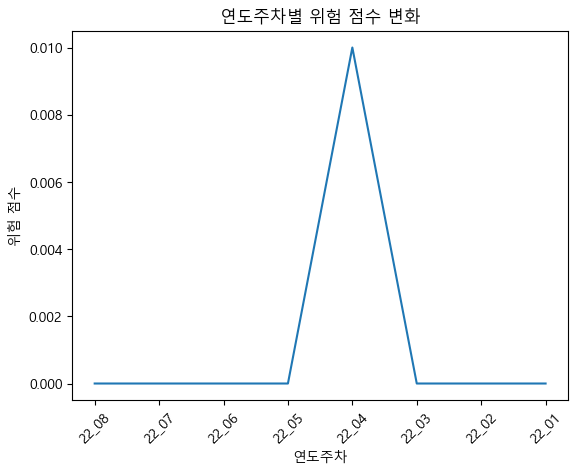

HS Code : 1003901000
      연도주차    단가        신고중량
0    17_04   NaN         NaN
1    17_05   NaN         NaN
2    17_06   NaN         NaN
3    17_07   NaN         NaN
4    17_08 0.288 1533750.000
..     ...   ...         ...
292  22_34 0.474  136245.000
293  22_35 0.442  384820.000
294  22_36 0.448  399849.500
295  22_37 0.461  360794.500
296  22_38 0.454  345794.500

[297 rows x 3 columns]
22_07주차
0    0.216
1    0.217
2    0.217
3    0.217
4    0.217
5    0.216
6    0.216
7    0.216
8    0.216
9    0.223
10   0.225
11   0.227
12   0.224
13   0.216
14   0.222
15   0.222
16   0.224
17   0.226
18   0.224
19   0.231
20   0.228
21   0.230
22   0.228
23   0.223
24   0.225
25   0.219
26   0.219
27   0.220
28   0.220
29   0.220
30   0.220
31   0.227
32   0.233
33   0.232
34   0.233
35   0.229
36   0.229
37   0.240
38   0.240
39   0.247
40   0.245
41   0.238
42   0.247
43   0.239
44   0.242
45   0.252
46   0.229
47   0.229
48   0.229
49   0.229
50   0.229
51   0.228
Name: 단가, dtype: float64
Pe

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     828835.000
1     717547.500
2     615187.500
3     411495.000
4     364135.000
5     267075.000
6     417842.500
7     604052.500
8     648885.000
9     808762.000
10    630552.000
11    520297.000
12    703284.500
13    697550.000
14    855198.250
15    934663.250
16    959354.500
17    805212.000
18    841536.250
19    820790.750
20    843592.000
21   1156483.500
22   1040701.000
23   1188999.000
24    856121.500
25    699435.000
26    543867.500
27    462302.500
28    874930.000
29    718725.000
30    873942.500
31    946175.000
32    533547.500
33    892700.000
34    944717.500
35    566387.500
36    669247.500
37    587656.900
38    588656.900
39    711246.900
40    811201.900
41    737535.000
42    704745.000
43    686440.000
44    483625.000
45    279730.000
46    104285.000
47    104285.000
48    104285.000
49    104285.000
50    103875.000
51    521090.000
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     624857.500
1     833205.000
2     623622.500
3     932005.000
4     828835.000
5     717547.500
6     615187.500
7     411495.000
8     364135.000
9     267075.000
10    417842.500
11    604052.500
12    648885.000
13    808762.000
14    630552.000
15    520297.000
16    703284.500
17    697550.000
18    855198.250
19    934663.250
20    959354.500
21    805212.000
22    841536.250
23    820790.750
24    843592.000
25   1156483.500
26   1040701.000
27   1188999.000
28    856121.500
29    699435.000
30    543867.500
31    462302.500
32    874930.000
33    718725.000
34    873942.500
35    946175.000
36    533547.500
37    892700.000
38    944717.500
39    566387.500
40    669247.500
41    587656.900
42    588656.900
43    711246.900
44    811201.900
45    737535.000
46    704745.000
47    686440.000
48    483625.000
49    279730.000
50    104285.000
51    104285.000
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1526.468, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1383.413, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1494.637, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1381.753, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=1383.326, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1379.523, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1381.359, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1377.750, Time=0.09 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=1377.902, Time=0.12 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=1376.657, Time=0.09 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=1378.672, Time=0.14 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=1381.237, Time=0.09 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=1379.044, Time=0.23 sec
 ARIMA(3,0,2)(0,0,0)

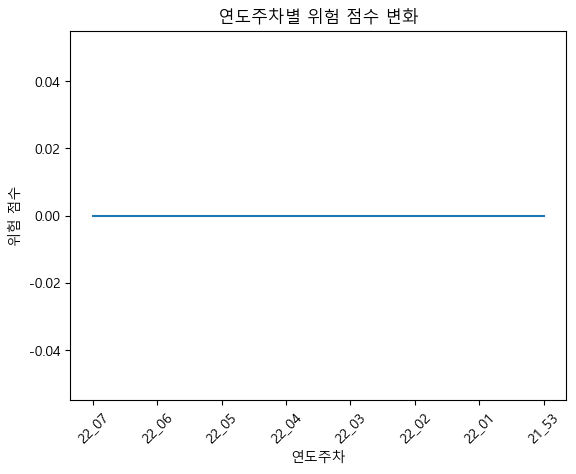

HS Code : 1003902000
      연도주차    단가        신고중량
0    17_04 0.192 3149912.500
1    17_05 0.192 3412412.500
2    17_06 0.192 2054420.000
3    17_07 0.192 1861815.000
4    17_08 0.192  354402.500
..     ...   ...         ...
292  22_34 0.383  183362.562
293  22_35 0.383  183362.562
294  22_36 0.366  116280.000
295  22_37 0.379   75557.500
296  22_38 0.379   75557.500

[297 rows x 3 columns]
22_07주차
0    0.244
1    0.239
2    0.236
3    0.247
4    0.254
5    0.254
6    0.246
7    0.256
8    0.283
9    0.283
10   0.283
11   0.282
12   0.278
13   0.272
14   0.272
15   0.269
16   0.281
17   0.293
18   0.293
19   0.287
20   0.268
21   0.269
22   0.269
23   0.277
24   0.279
25   0.289
26   0.271
27   0.266
28   0.264
29   0.264
30   0.267
31   0.279
32   0.286
33   0.281
34   0.288
35   0.281
36   0.281
37   0.291
38   0.278
39   0.284
40   0.306
41   0.306
42   0.335
43   0.327
44   0.329
45   0.331
46   0.344
47   0.348
48   0.346
49   0.346
50   0.347
51   0.340
Name: 단가, dtype: float64
Pe

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    2992217.500
1     869097.500
2     683327.500
3     269977.500
4     164995.000
5     298164.750
6     298164.750
7     266651.000
8     235016.000
9     249818.000
10    249818.000
11    249814.250
12    376146.750
13    252635.000
14    380320.000
15    380320.000
16    357498.000
17    360203.750
18    232518.975
19    232518.975
20    156960.975
21    225107.725
22    278897.500
23    278897.500
24    229272.500
25     96159.750
26     42369.750
27    216612.000
28    264614.500
29    347134.750
30    347134.750
31    227985.000
32    278295.000
33    244757.000
34    362449.500
35    340447.000
36    290589.500
37    251491.000
38    133798.500
39    226133.500
40    152028.500
41    255394.500
42    260529.500
43    140104.500
44    185647.000
45     55677.500
46     50542.500
47   1421842.500
48   3579985.000
49   4216345.000
50   4216345.000
51   3090045.000
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1563.437, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1490.370, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1476.024, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=1484.923, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1485.526, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1482.176, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1487.306, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1474.112, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1490.363, Time=0.01 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=1484.286, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1485.320, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1484.356, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=1483.939, Time=0.09 sec

Best model:  ARIMA(

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    3067715.000
1    3253485.000
2    3652617.500
3    2992217.500
4     869097.500
5     683327.500
6     269977.500
7     164995.000
8     298164.750
9     298164.750
10    266651.000
11    235016.000
12    249818.000
13    249818.000
14    249814.250
15    376146.750
16    252635.000
17    380320.000
18    380320.000
19    357498.000
20    360203.750
21    232518.975
22    232518.975
23    156960.975
24    225107.725
25    278897.500
26    278897.500
27    229272.500
28     96159.750
29     42369.750
30    216612.000
31    264614.500
32    347134.750
33    347134.750
34    227985.000
35    278295.000
36    244757.000
37    362449.500
38    340447.000
39    290589.500
40    251491.000
41    133798.500
42    226133.500
43    152028.500
44    255394.500
45    260529.500
46    140104.500
47    185647.000
48     55677.500
49     50542.500
50   1421842.500
51   3579985.000
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     998147.500
1    3067715.000
2    3253485.000
3    3652617.500
4    2992217.500
5     869097.500
6     683327.500
7     269977.500
8     164995.000
9     298164.750
10    298164.750
11    266651.000
12    235016.000
13    249818.000
14    249818.000
15    249814.250
16    376146.750
17    252635.000
18    380320.000
19    380320.000
20    357498.000
21    360203.750
22    232518.975
23    232518.975
24    156960.975
25    225107.725
26    278897.500
27    278897.500
28    229272.500
29     96159.750
30     42369.750
31    216612.000
32    264614.500
33    347134.750
34    347134.750
35    227985.000
36    278295.000
37    244757.000
38    362449.500
39    340447.000
40    290589.500
41    251491.000
42    133798.500
43    226133.500
44    152028.500
45    255394.500
46    260529.500
47    140104.500
48    185647.000
49     55677.500
50     50542.500
51   1421842.500
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     135235.000
1     153807.500
2     998147.500
3    3067715.000
4    3253485.000
5    3652617.500
6    2992217.500
7     869097.500
8     683327.500
9     269977.500
10    164995.000
11    298164.750
12    298164.750
13    266651.000
14    235016.000
15    249818.000
16    249818.000
17    249814.250
18    376146.750
19    252635.000
20    380320.000
21    380320.000
22    357498.000
23    360203.750
24    232518.975
25    232518.975
26    156960.975
27    225107.725
28    278897.500
29    278897.500
30    229272.500
31     96159.750
32     42369.750
33    216612.000
34    264614.500
35    347134.750
36    347134.750
37    227985.000
38    278295.000
39    244757.000
40    362449.500
41    340447.000
42    290589.500
43    251491.000
44    133798.500
45    226133.500
46    152028.500
47    255394.500
48    260529.500
49    140104.500
50    185647.000
51     55677.500
Na

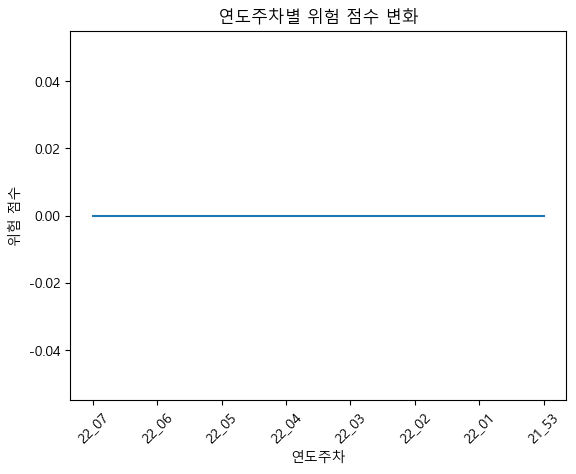

HS Code : 1104230000
      연도주차    단가       신고중량
0    17_04 0.389  38475.125
1    17_05 0.430 166375.125
2    17_06 0.477 415325.600
3    17_07 0.478 462700.475
4    17_08 0.475 537900.475
..     ...   ...        ...
292  22_34 0.451 446502.199
293  22_35 0.448 560500.000
294  22_36 0.447 413250.000
295  22_37 0.465 337250.000
296  22_38 0.473 231750.000

[297 rows x 3 columns]
22_07주차
0    0.415
1    0.410
2    0.404
3    0.412
4    0.411
5    0.414
6    0.410
7    0.424
8    0.414
9    0.418
10   0.420
11   0.408
12   0.414
13   0.407
14   0.405
15   0.392
16   0.392
17   0.392
18   0.394
19   0.394
20   0.396
21   0.397
22   0.395
23   0.395
24   0.394
25   0.394
26   0.396
27   0.397
28   0.397
29   0.405
30   0.407
31   0.411
32   0.411
33   0.411
34   0.412
35   0.410
36   0.411
37   0.410
38   0.410
39   0.411
40   0.409
41   0.410
42   0.411
43   0.411
44   0.411
45   0.412
46   0.416
47   0.416
48   0.418
49   0.418
50   0.421
51   0.421
Name: 단가, dtype: float64
Performing ste

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    432751.167
1    475500.542
2    323250.542
3    405750.000
4    345500.125
5    364500.125
6    295501.375
7    255501.375
8    341751.250
9    467001.250
10   424251.000
11   394501.000
12   285251.000
13    98251.000
14   131500.000
15   213750.000
16   237500.000
17   266000.000
18   300750.000
19   262750.000
20   206000.000
21   353250.000
22   485000.000
23   442250.000
24   418250.000
25   399250.000
26   213750.000
27   285000.000
28   285000.000
29   228000.000
30   285000.000
31   237500.000
32   280250.000
33   223250.000
34   180500.000
35   166251.350
36   294501.350
37   275501.350
38   318251.350
39   323000.500
40   152000.620
41   171000.620
42   289750.620
43   275502.870
44   275502.750
45   232752.750
46    14252.750
47    14252.750
48    99750.000
49   199500.000
50   432250.000
51   574750.875
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    359001.392
1    432751.167
2    475500.542
3    323250.542
4    405750.000
5    345500.125
6    364500.125
7    295501.375
8    255501.375
9    341751.250
10   467001.250
11   424251.000
12   394501.000
13   285251.000
14    98251.000
15   131500.000
16   213750.000
17   237500.000
18   266000.000
19   300750.000
20   262750.000
21   206000.000
22   353250.000
23   485000.000
24   442250.000
25   418250.000
26   399250.000
27   213750.000
28   285000.000
29   285000.000
30   228000.000
31   285000.000
32   237500.000
33   280250.000
34   223250.000
35   180500.000
36   166251.350
37   294501.350
38   275501.350
39   318251.350
40   323000.500
41   152000.620
42   171000.620
43   289750.620
44   275502.870
45   275502.750
46   232752.750
47    14252.750
48    14252.750
49    99750.000
50   199500.000
51   432250.000
Name: 신고중량, dtype: float64
Performing stepwise search 

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    577286.988
1    667524.312
2    368274.537
3    235263.788
4    449250.850
5    359001.392
6    432751.167
7    475500.542
8    323250.542
9    405750.000
10   345500.125
11   364500.125
12   295501.375
13   255501.375
14   341751.250
15   467001.250
16   424251.000
17   394501.000
18   285251.000
19    98251.000
20   131500.000
21   213750.000
22   237500.000
23   266000.000
24   300750.000
25   262750.000
26   206000.000
27   353250.000
28   485000.000
29   442250.000
30   418250.000
31   399250.000
32   213750.000
33   285000.000
34   285000.000
35   228000.000
36   285000.000
37   237500.000
38   280250.000
39   223250.000
40   180500.000
41   166251.350
42   294501.350
43   275501.350
44   318251.350
45   323000.500
46   152000.620
47   171000.620
48   289750.620
49   275502.870
50   275502.750
51   232752.750
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    498780.800
1    577286.988
2    667524.312
3    368274.537
4    235263.788
5    449250.850
6    359001.392
7    432751.167
8    475500.542
9    323250.542
10   405750.000
11   345500.125
12   364500.125
13   295501.375
14   255501.375
15   341751.250
16   467001.250
17   424251.000
18   394501.000
19   285251.000
20    98251.000
21   131500.000
22   213750.000
23   237500.000
24   266000.000
25   300750.000
26   262750.000
27   206000.000
28   353250.000
29   485000.000
30   442250.000
31   418250.000
32   399250.000
33   213750.000
34   285000.000
35   285000.000
36   228000.000
37   285000.000
38   237500.000
39   280250.000
40   223250.000
41   180500.000
42   166251.350
43   294501.350
44   275501.350
45   318251.350
46   323000.500
47   152000.620
48   171000.620
49   289750.620
50   275502.870
51   275502.750
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


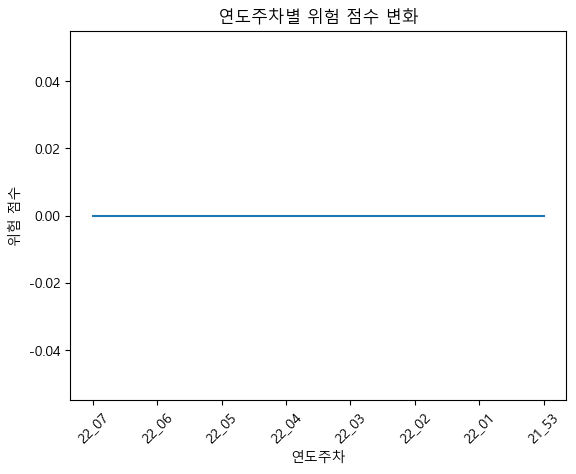

HS Code : 2710121000
      연도주차    단가         신고중량
0    17_04 0.551  2149886.250
1    17_05 0.550  4114309.500
2    17_06 0.549  6381111.750
3    17_07 0.549  4234150.250
4    17_08 0.547  9687853.750
..     ...   ...          ...
292  22_34 0.801 16626932.000
293  22_35 0.955  9728367.250
294  22_36 0.916  8810688.000
295  22_37 0.916  8810688.000
296  22_38 0.713 14231087.750

[297 rows x 3 columns]
22_07주차
0    0.557
1    0.587
2    0.587
3    0.598
4    0.633
5    0.647
6    0.646
7    0.642
8    0.633
9    0.622
10   0.633
11   0.634
12   0.663
13   0.658
14   0.527
15   0.571
16   0.570
17   0.559
18   0.679
19   0.687
20   0.724
21   0.730
22   0.733
23   0.733
24   0.732
25   0.782
26   0.663
27   0.663
28   0.665
29   0.679
30   0.692
31   0.695
32   0.692
33   0.707
34   0.735
35   0.758
36   0.879
37   0.838
38   0.827
39   0.812
40   0.812
41   0.752
42   0.741
43   0.779
44   0.629
45   0.578
46   0.712
47   0.694
48   0.811
49   0.808
50   0.817
51   0.836
Name: 단가, dtype

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     8765766.000
1    15930045.000
2    11130138.000
3    12556530.250
4    12704250.250
5     5539971.250
6     5569408.000
7      177156.750
8     1138045.250
9     7136791.200
10    8301232.700
11   11013298.730
12   14520791.730
13    8523733.280
14   11248927.030
15    8536861.000
16    3920911.075
17    4805742.575
18    3517106.575
19    4965419.825
20    4965268.250
21    4274324.250
22    1866883.750
23     418570.500
24    1410867.750
25    9980065.750
26   10202026.250
27   10202026.250
28    9209729.000
29     444956.000
30    3372983.000
31    3372983.000
32    3461937.025
33    7450133.775
34    4077150.775
35    4080928.025
36    5485082.500
37    1501508.750
38    1964684.500
39    2269316.500
40    1069348.500
41   11854664.500
42   13540607.500
43   15329507.750
44   15036367.250
45    5562107.000
46    3412988.250
47    2504424.250
48    4502742.250
49  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    10787000.250
1     8765766.000
2    15930045.000
3    11130138.000
4    12556530.250
5    12704250.250
6     5539971.250
7     5569408.000
8      177156.750
9     1138045.250
10    7136791.200
11    8301232.700
12   11013298.730
13   14520791.730
14    8523733.280
15   11248927.030
16    8536861.000
17    3920911.075
18    4805742.575
19    3517106.575
20    4965419.825
21    4965268.250
22    4274324.250
23    1866883.750
24     418570.500
25    1410867.750
26    9980065.750
27   10202026.250
28   10202026.250
29    9209729.000
30     444956.000
31    3372983.000
32    3372983.000
33    3461937.025
34    7450133.775
35    4077150.775
36    4080928.025
37    5485082.500
38    1501508.750
39    1964684.500
40    2269316.500
41    1069348.500
42   11854664.500
43   13540607.500
44   15329507.750
45   15036367.250
46    5562107.000
47    3412988.250
48    2504424.250
49  

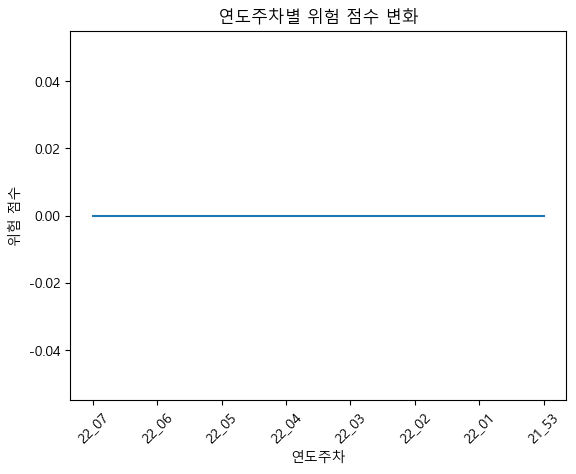

HS Code : 3104200000
      연도주차    단가         신고중량
0    17_04 0.299 11374102.375
1    17_05 0.298 16317880.400
2    17_06 0.291 12415604.100
3    17_07 0.291 10819745.700
4    17_08 0.289 11582318.950
..     ...   ...          ...
292  22_34 0.992 29386228.624
293  22_35 1.007  9666683.242
294  22_36 1.006  9627907.123
295  22_37 1.007  9785683.655
296  22_38 1.010  2767031.598

[297 rows x 3 columns]
22_07주차
0    0.265
1    0.271
2    0.268
3    0.272
4    0.261
5    0.260
6    0.260
7    0.260
8    0.299
9    0.280
10   0.279
11   0.280
12   0.276
13   0.299
14   0.283
15   0.283
16   0.278
17   0.278
18   0.274
19   0.280
20   0.286
21   0.288
22   0.295
23   0.343
24   0.356
25   0.368
26   0.368
27   0.369
28   0.388
29   0.389
30   0.369
31   0.372
32   0.363
33   0.353
34   0.355
35   0.380
36   0.380
37   0.533
38   0.445
39   0.435
40   0.435
41   0.436
42   0.427
43   0.428
44   0.418
45   0.436
46   0.455
47   0.452
48   0.475
49   0.738
50   0.738
51   0.608
Name: 단가, dtype

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1748.572, Time=0.01 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=1750.534, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1750.622, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1749.099, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1741.237, Time=0.06 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=1738.865, Time=0.07 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=1751.664, Time=0.03 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=1732.098, Time=0.10 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=1739.496, Time=0.05 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=1734.529, Time=0.10 sec
 ARIMA(5,0,1)(0,0,0)[0] intercept   : AIC=1726.229, Time=0.11 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=1726.275, Time=0.10 sec
 ARIMA(5,0,0)(0,0,0)[0] intercept   : AIC=1733.385, Time=0.06 sec
 ARIMA(5,0,2)(0,0,0)[0] intercept   : AIC=1725.116, Time=0.17 sec
 ARIMA(4,0,2)(0

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1750.819, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1800.925, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1749.032, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1750.475, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1748.491, Time=0.01 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=1750.485, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1742.365, Time=0.06 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=1739.297, Time=0.06 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=1751.654, Time=0.03 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=1732.563, Time=0.11 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=1739.261, Time=0.04 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=1734.111, Time=0.14 sec
 ARIMA(5,0,1)(0,0,0)[0] intercept   : AIC=1726.401, Time=0.11 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=1725.848, Time=0.10 sec
 ARIMA(3,0,1)(0

...

 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1753.131, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1839.786, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1753.937, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1810.498, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1751.433, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1802.263, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1750.067, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1751.583, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1749.579, Time=0.01 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=1751.560, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1742.947, Time=0.07 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=1740.328, Time=0.08 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=1752.434, Time=0.03 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=1732.197, Time=0.10 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=1737.781, Time=0.04 sec
 ARIMA(5,0

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    11439086.318
1    10078878.595
2    17623980.602
3    18941973.165
4    19154089.112
5    26388053.882
6    10848408.987
7    10939364.025
8    17474054.190
9     9429601.715
10   23952649.830
11   23754948.883
12   16850661.767
13   17458618.276
14    3554086.133
15   12218383.606
16   12107366.281
17   11516935.784
18   10898136.424
19    2380387.074
20   12491971.349
21   13279410.200
22   21462436.948
23   21448138.023
24   18889077.523
25   32493832.810
26   27363068.125
27   28248164.212
28   19755683.589
29   12855464.362
30   11266343.705
31    8980520.543
32   15271725.124
33    8758476.601
34    8075621.746
35    8125543.596
36   15975057.496
37   15181597.234
38   14553112.171
39   21637837.078
40    7805084.988
41    9257912.913
42    9115744.375
43    2115823.407
44   14469094.569
45   12821669.932
46   19510271.358
47   19376502.529
48   13172263.136
49  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    10245594.258
1    11439086.318
2    10078878.595
3    17623980.602
4    18941973.165
5    19154089.112
6    26388053.882
7    10848408.987
8    10939364.025
9    17474054.190
10    9429601.715
11   23952649.830
12   23754948.883
13   16850661.767
14   17458618.276
15    3554086.133
16   12218383.606
17   12107366.281
18   11516935.784
19   10898136.424
20    2380387.074
21   12491971.349
22   13279410.200
23   21462436.948
24   21448138.023
25   18889077.523
26   32493832.810
27   27363068.125
28   28248164.212
29   19755683.589
30   12855464.362
31   11266343.705
32    8980520.543
33   15271725.124
34    8758476.601
35    8075621.746
36    8125543.596
37   15975057.496
38   15181597.234
39   14553112.171
40   21637837.078
41    7805084.988
42    9257912.913
43    9115744.375
44    2115823.407
45   14469094.569
46   12821669.932
47   19510271.358
48   19376502.529
49  

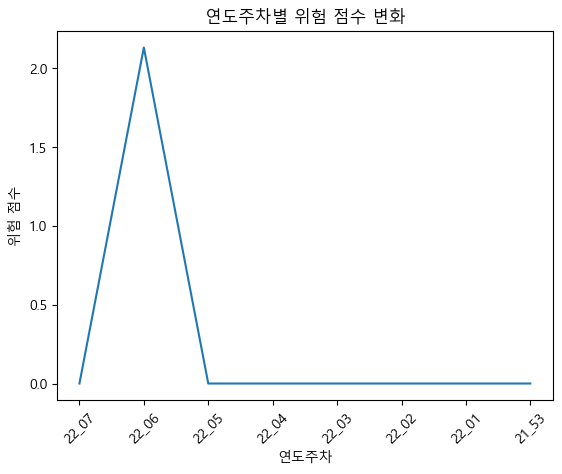

HS Code : 2905172000
      연도주차    단가       신고중량
0    17_04 1.801  49211.300
1    17_05 1.754  65983.925
2    17_06 1.838  79977.625
3    17_07 1.857  61760.131
4    17_08 1.863  63759.256
..     ...   ...        ...
292  22_34 3.054 100640.853
293  22_35 3.011 131752.708
294  22_36 2.871 136344.133
295  22_37 2.882  95667.133
296  22_38 2.817  62904.505

[297 rows x 3 columns]
22_16주차
0    1.868
1    1.884
2    1.888
3    1.972
4    1.982
5    2.164
6    2.211
7    2.363
8    2.266
9    2.237
10   2.206
11   2.106
12   2.144
13   2.074
14   2.136
15   2.217
16   2.281
17   2.268
18   2.303
19   2.208
20   2.411
21   2.438
22   2.393
23   2.378
24   2.260
25   2.278
26   2.390
27   2.436
28   2.515
29   2.421
30   2.293
31   2.319
32   2.320
33   2.359
34   2.538
35   2.443
36   2.374
37   2.305
38   2.150
39   2.380
40   2.506
41   2.610
42   2.648
43   2.670
44   2.786
45   2.745
46   2.751
47   2.780
48   2.781
49   2.885
50   2.877
51   2.891
Name: 단가, dtype: float64
Performing ste

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1141.271, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1143.945, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1144.776, Time=0.08 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=1144.273, Time=0.14 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1135.345, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1133.407, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1136.822, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1131.374, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1148.090, Time=0.00 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1133.313, Time=0.02 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.540 seconds


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_14주차
0    1.838
1    1.870
2    1.868
3    1.884
4    1.888
5    1.972
6    1.982
7    2.164
8    2.211
9    2.363
10   2.266
11   2.237
12   2.206
13   2.106
14   2.144
15   2.074
16   2.136
17   2.217
18   2.281
19   2.268
20   2.303
21   2.208
22   2.411
23   2.438
24   2.393
25   2.378
26   2.260
27   2.278
28   2.390
29   2.436
30   2.515
31   2.421
32   2.293
33   2.319
34   2.320
35   2.359
36   2.538
37   2.443
38   2.374
39   2.305
40   2.150
41   2.380
42   2.506
43   2.610
44   2.648
45   2.670
46   2.786
47   2.745
48   2.751
49   2.780
50   2.781
51   2.885
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-98.027, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-96.040, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-96.0

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_11주차
0    1.776
1    1.813
2    1.771
3    1.838
4    1.870
5    1.868
6    1.884
7    1.888
8    1.972
9    1.982
10   2.164
11   2.211
12   2.363
13   2.266
14   2.237
15   2.206
16   2.106
17   2.144
18   2.074
19   2.136
20   2.217
21   2.281
22   2.268
23   2.303
24   2.208
25   2.411
26   2.438
27   2.393
28   2.378
29   2.260
30   2.278
31   2.390
32   2.436
33   2.515
34   2.421
35   2.293
36   2.319
37   2.320
38   2.359
39   2.538
40   2.443
41   2.374
42   2.305
43   2.150
44   2.380
45   2.506
46   2.610
47   2.648
48   2.670
49   2.786
50   2.745
51   2.751
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-97.269, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-95.271, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-95.2

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    112124.425
1    114662.050
2    105335.050
3     90309.875
4     77989.250
5     59863.625
6    102581.150
7    104593.403
8    103831.328
9    105693.828
10    74423.258
11    78403.830
12    91800.905
13    79802.405
14    68082.700
15    95649.625
16    88584.375
17   110632.875
18   104293.025
19   106678.025
20    75903.300
21    97053.180
22   122183.780
23    87141.280
24   103501.257
25    70622.625
26    58022.625
27    50237.625
28    52562.625
29    61041.878
30    82435.753
31    99243.253
32    89308.001
33    96727.526
34    65742.525
35    58675.775
36    85142.028
37    74414.746
38    90915.052
39    90009.327
40    76833.325
41    97113.232
42    84427.926
43   100970.401
44   103185.761
45    81704.994
46   108125.469
47   125458.219
48   123127.732
49   122870.850
50   106302.875
51    82512.625
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


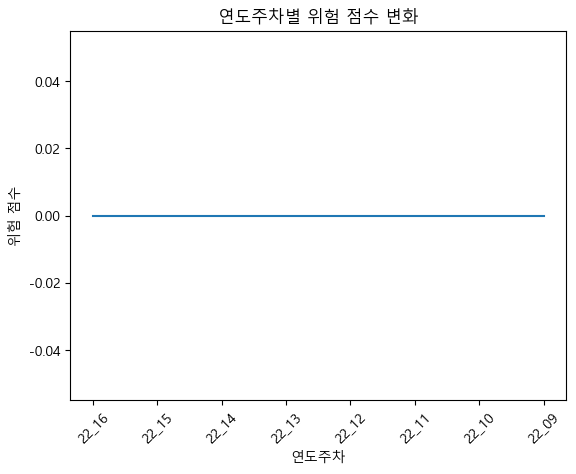

[0, np.float64(0.07), np.float64(4.07), np.float64(0.74), np.float64(1.32), 0, np.float64(0.07), np.float64(0.91), np.float64(0.01), 0, 0, 0, 0, np.float64(2.13), 0]
[0, 166, 83, 46, 41, 0, 41, 31, 34, 0, 0, 0, 0, 32, 0]


In [2]:
추출용 = [3102109000,3707901010,4407191000,8111000000,2701129010,2804701000,1511901000,305531000,302140000,1003901000,1003902000,1104230000,2710121000,3104200000,2905172000]
b = [59, 174, 85, 54, 48, 48, 44, 39, 38, 39, 39, 39, 39, 39, 30]

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
    print(df_price_4w)
    
   
    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        res_resid = df_price_4w['단가'].iloc[p_eriod-l:-l]
        res_resid = res_resid.reset_index(drop=True)
        
        print(res_resid)
        n_test = 1
        
        train_y, test_y = res_resid[:-n_test], res_resid[-n_test:]
        
        model = pm.auto_arima(train_y, seasonal=False, trace=True)
        p, d, q = model.order

        model = SARIMAX(train_y, order=(p, d, q), seasonal_order=(1, 1, 1, 12), 
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)
        forecast1 = model_fit.forecast(steps=1)
                
        print('======================= 여기부터 GARCH 모델링 =================================')
        est_residuals = model_fit.resid
                
        # NaN 또는 inf가 있는 경우 제거하거나 대체
        est_residuals = est_residuals.replace([np.inf, -np.inf], np.nan)
        est_residuals = est_residuals.dropna()

        # GARCH에 적용
        if len(est_residuals) > 0:
            garch = arch.arch_model(est_residuals, vol="GARCH", p=1, q=1)
            garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        else:
            print("⚠ GARCH 입력 데이터가 부족합니다. 모델링 생략")
        
        print('=========== GARCH forecast =============')
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        stand_quant = (test_y.iloc[0] - forecast1.iloc[0])/ garch_std

        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)

      #=================== 신고중량 ======================
         
        res_resid = df_price_4w['신고중량'].iloc[p_eriod-l:-l]
        res_resid = res_resid.reset_index(drop=True)
        
        print(res_resid)
        n_test = 1
        
        train_y, test_y = res_resid[:-n_test], res_resid[-n_test:]
        
        model = pm.auto_arima(train_y, seasonal=False, trace=True)
        p, d, q = model.order

        model = SARIMAX(train_y, order=(p, d, q), seasonal_order=(1, 1, 1, 12), 
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)
        forecast1 = model_fit.forecast(steps=1)
                
        print('======================= 여기부터 GARCH 모델링 =================================')
        est_residuals = model_fit.resid
                
        # NaN 또는 inf가 있는 경우 제거하거나 대체
        est_residuals = est_residuals.replace([np.inf, -np.inf], np.nan)
        est_residuals = est_residuals.dropna()

        # GARCH에 적용
        if len(est_residuals) > 0:
            garch = arch.arch_model(est_residuals, vol="GARCH", p=1, q=1)
            garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        else:
            print("⚠ GARCH 입력 데이터가 부족합니다. 모델링 생략")
        
        print('=========== GARCH forecast =============')
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        stand_quant = (test_y.iloc[0] - forecast1.iloc[0])/ garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y
      
    if(z[j]>1.85):
        o[j] = 1
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)


# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:14, 'Model14(1)'] = o
collect.loc[15, 'Model14(1)'] = np.sum(o)
collect.loc[:14, 'Model14(2)'] = z
collect.loc[15, 'Model14(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[:14, 'y_scores[15]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[:14, 'y_scores[15]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[:14, 'y_scores[15]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)

HS Code : 3926909000
21_49주차
0    12.129
1    11.984
2    12.347
3    11.683
4    12.158
5    12.330
6    12.285
7    12.515
8    13.271
9    13.807
10   14.311
11   15.821
12   14.435
13   13.925
14   13.304
15   12.550
16   12.274
17   11.901
18   11.674
19   11.701
20   11.671
21   11.323
22   11.439
23   11.235
24   11.117
25   11.300
26   11.127
27   11.482
28   12.033
29   12.253
30   12.344
31   12.359
32   12.300
33   12.373
34   12.857
35   12.908
36   12.585
37   12.790
38   12.298
39   13.513
40   14.026
41   14.352
42   14.920
43   13.624
44   13.439
45   12.984
46   12.977
47   13.023
48   12.822
49   12.741
50   12.760
51   12.512
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=87.602, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=405.936, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]     

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1819475.697
1    1759198.849
2    1702628.788
3    1772732.696
4    1801110.265
5    1942272.072
6    2063378.412
7    2135877.091
8    1910684.931
9    1698594.161
10   1497006.522
11   1216500.177
12   1387471.016
13   1557317.076
14   1733684.614
15   1946767.614
16   2011353.845
17   2040727.035
18   2103305.349
19   2129829.188
20   2062311.091
21   2044849.603
22   1955011.476
23   1939171.723
24   1918588.422
25   1881981.178
26   1850456.215
27   1771389.791
28   1784857.980
29   1773956.662
30   1795661.931
31   1861654.184
32   1857961.823
33   1846204.722
34   1896762.862
35   1794810.335
36   1869589.479
37   1878669.796
38   1893962.304
39   1966106.705
40   1759797.708
41   1856764.017
42   1732404.326
43   1697385.546
44   1834109.354
45   1785889.886
46   1913378.676
47   1930866.467
48   1985621.832
49   1947465.647
50   1929595.306
51   2031017.054
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1332.102, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1618.424, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1585.190, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1323.441, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1579.046, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1332.195, Time=0.03 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=1322.224, Time=0.09 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=1579.201, Time=0.03 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=1320.147, Time=0.18 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=1319.821, Time=0.17 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=1322.691, Time=0.22 sec
 ARIMA(3,0,4)(0,0,0)[0]             : AIC=inf, Time=0.28 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(4,0,2)(0,0,0)[0]       

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1822660.710
1    1818218.133
2    1827889.699
3    1834954.843
4    1855586.740
5    1859284.460
6    1819475.697
7    1759198.849
8    1702628.788
9    1772732.696
10   1801110.265
11   1942272.072
12   2063378.412
13   2135877.091
14   1910684.931
15   1698594.161
16   1497006.522
17   1216500.177
18   1387471.016
19   1557317.076
20   1733684.614
21   1946767.614
22   2011353.845
23   2040727.035
24   2103305.349
25   2129829.188
26   2062311.091
27   2044849.603
28   1955011.476
29   1939171.723
30   1918588.422
31   1881981.178
32   1850456.215
33   1771389.791
34   1784857.980
35   1773956.662
36   1795661.931
37   1861654.184
38   1857961.823
39   1846204.722
40   1896762.862
41   1794810.335
42   1869589.479
43   1878669.796
44   1893962.304
45   1966106.705
46   1759797.708
47   1856764.017
48   1732404.326
49   1697385.546
50   1834109.354
51   1785889.886
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    12.582
1    12.519
2    12.091
3    12.131
4    11.941
5    12.034
6    12.379
7    12.129
8    11.984
9    12.347
10   11.683
11   12.158
12   12.330
13   12.285
14   12.515
15   13.271
16   13.807
17   14.311
18   15.821
19   14.435
20   13.925
21   13.304
22   12.550
23   12.274
24   11.901
25   11.674
26   11.701
27   11.671
28   11.323
29   11.439
30   11.235
31   11.117
32   11.300
33   11.127
34   11.482
35   12.033
36   12.253
37   12.344
38   12.359
39   12.300
40   12.373
41   12.857
42   12.908
43   12.585
44   12.790
45   12.298
46   13.513
47   14.026
48   14.352
49   14.920
50   13.624
51   13.439
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=405.137, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1838946.665
1    1822660.710
2    1818218.133
3    1827889.699
4    1834954.843
5    1855586.740
6    1859284.460
7    1819475.697
8    1759198.849
9    1702628.788
10   1772732.696
11   1801110.265
12   1942272.072
13   2063378.412
14   2135877.091
15   1910684.931
16   1698594.161
17   1497006.522
18   1216500.177
19   1387471.016
20   1557317.076
21   1733684.614
22   1946767.614
23   2011353.845
24   2040727.035
25   2103305.349
26   2129829.188
27   2062311.091
28   2044849.603
29   1955011.476
30   1939171.723
31   1918588.422
32   1881981.178
33   1850456.215
34   1771389.791
35   1784857.980
36   1773956.662
37   1795661.931
38   1861654.184
39   1857961.823
40   1846204.722
41   1896762.862
42   1794810.335
43   1869589.479
44   1878669.796
45   1893962.304
46   1966106.705
47   1759797.708
48   1856764.017
49   1732404.326
50   1697385.546
51   1834109.354
Na

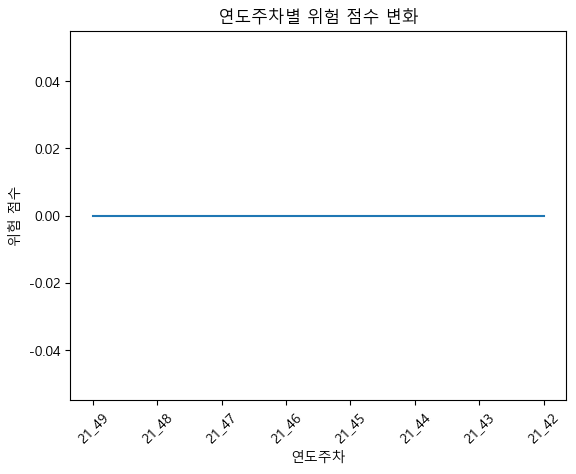

HS Code : 7326909000
21_49주차
0    3.834
1    3.985
2    4.133
3    4.049
4    4.178
5    4.165
6    4.174
7    4.239
8    4.336
9    4.360
10   4.582
11   4.783
12   4.699
13   4.419
14   4.331
15   4.257
16   4.197
17   4.334
18   4.160
19   4.222
20   4.080
21   4.029
22   4.205
23   4.097
24   4.330
25   4.476
26   4.382
27   4.371
28   4.282
29   4.434
30   4.414
31   4.308
32   4.474
33   4.490
34   4.532
35   4.701
36   4.380
37   4.060
38   4.080
39   4.143
40   4.257
41   4.221
42   4.220
43   4.160
44   4.188
45   4.201
46   4.087
47   4.143
48   4.173
49   4.280
50   4.135
51   4.159
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.18 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=294.893, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-49.906, Time=0.02 sec
 ARIMA(2,0,1)(0,0,

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     9715405.734
1     9794627.961
2     9478324.210
3     9022161.538
4     9422341.837
5     8958114.316
6     9136034.447
7     9371354.125
8     9026954.088
9     8496187.737
10    8498653.435
11    7805880.210
12    7345828.460
13    7944217.924
14    8059489.703
15    9088337.616
16    9725865.154
17    9843348.104
18   10461909.664
19   10516870.233
20   10660959.379
21   10823314.582
22   10418023.225
23   10193539.467
24   10480084.041
25   10635030.073
26   10389724.092
27   10231758.284
28    9751462.372
29    9509626.703
30    9397969.806
31    9961440.152
32   10335565.766
33    9873671.660
34    9655675.481
35    9109766.998
36    8584630.329
37    9117232.692
38    9747339.496
39    9708618.958
40    9864434.209
41    8778994.153
42    8761410.720
43    8807710.327
44    8747199.427
45    9505631.447
46    9300774.848
47    9556558.352
48    9453523.929
49  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    3.624
1    3.714
2    3.834
3    3.985
4    4.133
5    4.049
6    4.178
7    4.165
8    4.174
9    4.239
10   4.336
11   4.360
12   4.582
13   4.783
14   4.699
15   4.419
16   4.331
17   4.257
18   4.197
19   4.334
20   4.160
21   4.222
22   4.080
23   4.029
24   4.205
25   4.097
26   4.330
27   4.476
28   4.382
29   4.371
30   4.282
31   4.434
32   4.414
33   4.308
34   4.474
35   4.490
36   4.532
37   4.701
38   4.380
39   4.060
40   4.080
41   4.143
42   4.257
43   4.221
44   4.220
45   4.160
46   4.188
47   4.201
48   4.087
49   4.143
50   4.173
51   4.280
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=294.426, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1476.012, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1785.451, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1752.135, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1476.707, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1478.639, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1476.748, Time=0.01 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=1474.637, Time=0.18 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=1746.253, Time=0.03 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1746.050, Time=0.02 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=1748.113, Time=0.03 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=inf, Time=0.18 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     9106923.669
1     9217759.098
2     9256478.654
3     9439360.481
4     9582455.769
5     9810446.971
6     9715405.734
7     9794627.961
8     9478324.210
9     9022161.538
10    9422341.837
11    8958114.316
12    9136034.447
13    9371354.125
14    9026954.088
15    8496187.737
16    8498653.435
17    7805880.210
18    7345828.460
19    7944217.924
20    8059489.703
21    9088337.616
22    9725865.154
23    9843348.104
24   10461909.664
25   10516870.233
26   10660959.379
27   10823314.582
28   10418023.225
29   10193539.467
30   10480084.041
31   10635030.073
32   10389724.092
33   10231758.284
34    9751462.372
35    9509626.703
36    9397969.806
37    9961440.152
38   10335565.766
39    9873671.660
40    9655675.481
41    9109766.998
42    8584630.329
43    9117232.692
44    9747339.496
45    9708618.958
46    9864434.209
47    8778994.153
48    8761410.720
49  

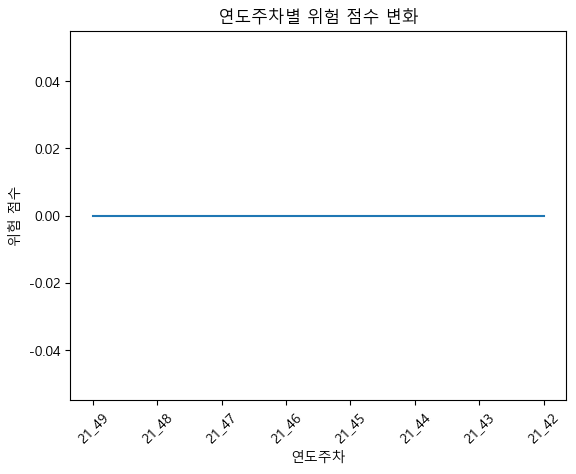

HS Code : 8708999000
21_49주차
0    14.864
1    14.780
2    14.506
3    14.466
4    14.632
5    14.446
6    14.692
7    14.774
8    14.350
9    14.510
10   14.644
11   15.057
12   15.278
13   15.356
14   14.923
15   14.652
16   15.201
17   15.301
18   15.140
19   15.478
20   14.721
21   14.850
22   15.336
23   14.648
24   14.531
25   14.007
26   13.881
27   14.143
28   14.621
29   14.497
30   14.400
31   14.131
32   13.859
33   14.443
34   14.132
35   14.716
36   14.272
37   13.614
38   14.205
39   13.951
40   14.120
41   14.038
42   14.460
43   14.996
44   15.642
45   16.467
46   15.027
47   14.686
48   13.669
49   13.437
50   13.527
51   13.163
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=420.203, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]        

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1564.525, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1531.551, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1295.571, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1293.191, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1294.600, Time=0.08 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1290.776, Time=0.16 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1525.634, Time=0.02 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=1289.929, Time=0.08 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=1525.296, Time=0.02 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=1289.229, Time=0.11 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=1284.146, Time=0.17 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(4,0,3)(0,0,0)[0]       

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1092321.981
1    1037095.745
2    1063425.756
3    1091410.350
4    1111543.475
5    1147660.053
6    1060236.535
7     997432.779
8    1080343.683
9    1058891.039
10   1151357.071
11   1199251.204
12   1138334.547
13   1048002.693
14   1046140.631
15    976627.393
16    894438.853
17   1077237.978
18   1113352.156
19   1229534.614
20   1307775.964
21   1180429.764
22   1155041.842
23   1090928.599
24   1038416.335
25   1024048.681
26    983070.550
27   1033698.270
28   1109445.525
29   1159773.967
30   1190345.384
31   1123803.251
32   1117668.599
33   1078423.856
34   1077162.885
35   1180097.572
36   1172265.875
37   1153859.640
38   1023783.038
39   1008650.690
40    993780.542
41   1059122.093
42   1185970.623
43   1103439.657
44   1080228.512
45    946105.909
46   1040592.970
47   1056417.755
48   1052176.844
49   1088443.171
50    983110.775
51   1034989.680
Na

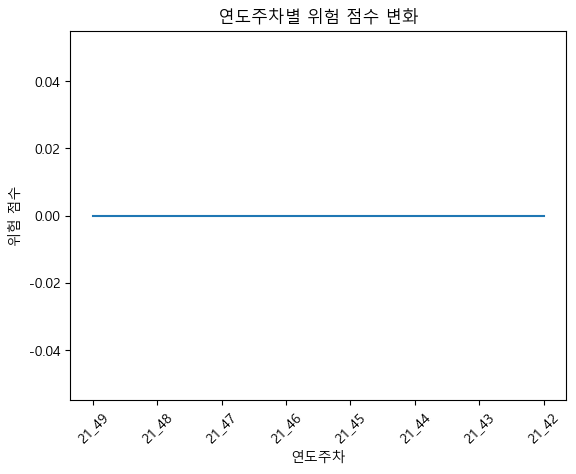

HS Code : 2106909099
21_49주차
0    30.593
1    28.459
2    27.590
3    24.369
4    24.924
5    26.267
6    26.436
7    27.241
8    25.988
9    26.008
10   25.668
11   27.228
12   26.945
13   26.874
14   25.740
15   23.675
16   23.194
17   22.879
18   22.957
19   24.092
20   25.188
21   24.300
22   26.033
23   25.691
24   23.988
25   23.960
26   22.640
27   22.399
28   23.656
29   22.847
30   22.755
31   23.143
32   22.483
33   22.269
34   23.032
35   21.742
36   22.539
37   24.902
38   26.445
39   28.277
40   29.857
41   27.695
42   27.241
43   28.329
44   26.939
45   28.766
46   27.940
47   27.826
48   28.926
49   28.200
50   29.259
51   27.167
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=477.953, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]        

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1462191.182
1    1439376.622
2    1437371.941
3    1364004.554
4    1382447.568
5    1390671.633
6    1425981.735
7    1350678.512
8    1474688.966
9    1415681.133
10   1364841.412
11   1553107.167
12   1534554.360
13   1459785.140
14   1534417.363
15   1539912.319
16   1468109.150
17   1723540.423
18   1785415.611
19   1841932.449
20   1937097.027
21   1890610.736
22   1756093.744
23   1789778.667
24   1698466.847
25   1631714.081
26   1780501.389
27   1644895.390
28   1761011.467
29   1949838.122
30   1890891.464
31   1958184.733
32   1906565.297
33   1772892.223
34   1808104.031
35   1807024.343
36   1806961.038
37   1836575.289
38   1868881.091
39   1919855.379
40   1994051.698
41   1918346.347
42   1725725.437
43   1601808.376
44   1530774.596
45   1355010.495
46   1605566.474
47   1630927.086
48   1561069.045
49   1791972.254
50   1585092.786
51   1556211.379
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=177.194, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=477.812, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=173.845, Time=0.06 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=365.825, Time=0.07 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=175.353, Time=0.03 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=174.018, Time=0.09 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=177.305, Time=0.04 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=169.472, Time=0.19 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=171.744, Time=0.17 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(3,0,4)(0,0,0)[0]             : AIC=164.189

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1518267.401
1    1462191.182
2    1439376.622
3    1437371.941
4    1364004.554
5    1382447.568
6    1390671.633
7    1425981.735
8    1350678.512
9    1474688.966
10   1415681.133
11   1364841.412
12   1553107.167
13   1534554.360
14   1459785.140
15   1534417.363
16   1539912.319
17   1468109.150
18   1723540.423
19   1785415.611
20   1841932.449
21   1937097.027
22   1890610.736
23   1756093.744
24   1789778.667
25   1698466.847
26   1631714.081
27   1780501.389
28   1644895.390
29   1761011.467
30   1949838.122
31   1890891.464
32   1958184.733
33   1906565.297
34   1772892.223
35   1808104.031
36   1807024.343
37   1806961.038
38   1836575.289
39   1868881.091
40   1919855.379
41   1994051.698
42   1918346.347
43   1725725.437
44   1601808.376
45   1530774.596
46   1355010.495
47   1605566.474
48   1630927.086
49   1561069.045
50   1791972.254
51   1585092.786
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1491944.475
1    1518267.401
2    1462191.182
3    1439376.622
4    1437371.941
5    1364004.554
6    1382447.568
7    1390671.633
8    1425981.735
9    1350678.512
10   1474688.966
11   1415681.133
12   1364841.412
13   1553107.167
14   1534554.360
15   1459785.140
16   1534417.363
17   1539912.319
18   1468109.150
19   1723540.423
20   1785415.611
21   1841932.449
22   1937097.027
23   1890610.736
24   1756093.744
25   1789778.667
26   1698466.847
27   1631714.081
28   1780501.389
29   1644895.390
30   1761011.467
31   1949838.122
32   1890891.464
33   1958184.733
34   1906565.297
35   1772892.223
36   1808104.031
37   1807024.343
38   1806961.038
39   1836575.289
40   1868881.091
41   1919855.379
42   1994051.698
43   1918346.347
44   1725725.437
45   1601808.376
46   1530774.596
47   1355010.495
48   1605566.474
49   1630927.086
50   1561069.045
51   1791972.254
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


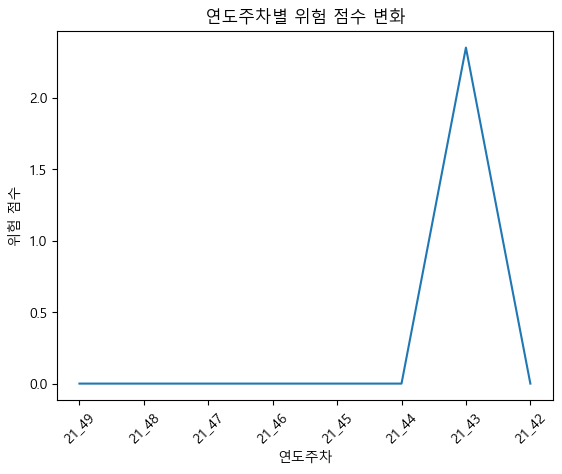

HS Code : 4911990000
21_49주차
0    31.889
1    26.694
2    20.066
3    27.773
4    28.758
5    34.575
6    28.508
7    19.205
8    20.105
9    15.976
10   18.177
11   36.025
12   46.020
13   38.914
14   44.076
15   32.960
16   25.394
17   37.994
18   28.626
19   36.832
20   37.516
21   31.605
22   36.665
23   22.455
24   29.634
25   26.087
26   26.901
27   45.386
28   49.568
29   56.153
30   65.112
31   77.807
32   70.767
33   68.448
34   47.387
35   25.319
36   24.198
37   24.514
38   36.792
39   34.226
40   22.457
41   23.756
42   20.052
43   21.737
44   28.928
45   28.451
46   24.885
47   35.497
48   32.926
49   30.967
50   38.114
51   30.916
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=372.178, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=514.501, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=371.852, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    31987.349
1    31920.607
2    31671.601
3    34234.887
4    31260.776
5    34954.207
6    47627.303
7    50995.766
8    45683.273
9    39107.184
10   35738.056
11   31846.155
12   30913.891
13   38750.404
14   34721.116
15   35188.926
16   37032.027
17   33044.941
18   42030.655
19   45695.521
20   42908.317
21   42501.615
22   34417.483
23   42464.689
24   43555.230
25   44156.331
26   42523.815
27   36675.460
28   36301.648
29   37859.513
30   39021.552
31   32634.367
32   33512.701
33   30641.472
34   35376.392
35   35386.881
36   38317.745
37   37702.641
38   29278.220
39   30673.554
40   33443.827
41   39760.620
42   41884.238
43   38732.110
44   36932.444
45   30671.492
46   38173.572
47   41700.433
48   43991.419
49   45769.655
50   38796.773
51   39028.844
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    24080.367
1    31987.349
2    31920.607
3    31671.601
4    34234.887
5    31260.776
6    34954.207
7    47627.303
8    50995.766
9    45683.273
10   39107.184
11   35738.056
12   31846.155
13   30913.891
14   38750.404
15   34721.116
16   35188.926
17   37032.027
18   33044.941
19   42030.655
20   45695.521
21   42908.317
22   42501.615
23   34417.483
24   42464.689
25   43555.230
26   44156.331
27   42523.815
28   36675.460
29   36301.648
30   37859.513
31   39021.552
32   32634.367
33   33512.701
34   30641.472
35   35376.392
36   35386.881
37   38317.745
38   37702.641
39   29278.220
40   30673.554
41   33443.827
42   39760.620
43   41884.238
44   38732.110
45   36932.444
46   30671.492
47   38173.572
48   41700.433
49   43991.419
50   45769.655
51   38796.773
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    35547.719
1    24080.367
2    31987.349
3    31920.607
4    31671.601
5    34234.887
6    31260.776
7    34954.207
8    47627.303
9    50995.766
10   45683.273
11   39107.184
12   35738.056
13   31846.155
14   30913.891
15   38750.404
16   34721.116
17   35188.926
18   37032.027
19   33044.941
20   42030.655
21   45695.521
22   42908.317
23   42501.615
24   34417.483
25   42464.689
26   43555.230
27   44156.331
28   42523.815
29   36675.460
30   36301.648
31   37859.513
32   39021.552
33   32634.367
34   33512.701
35   30641.472
36   35376.392
37   35386.881
38   38317.745
39   37702.641
40   29278.220
41   30673.554
42   33443.827
43   39760.620
44   41884.238
45   38732.110
46   36932.444
47   30671.492
48   38173.572
49   41700.433
50   43991.419
51   45769.655
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0    18.278
1    28.161
2    38.313
3    31.889
4    26.694
5    20.066
6    27.773
7    28.758
8    34.575
9    28.508
10   19.205
11   20.105
12   15.976
13   18.177
14   36.025
15   46.020
16   38.914
17   44.076
18   32.960
19   25.394
20   37.994
21   28.626
22   36.832
23   37.516
24   31.605
25   36.665
26   22.455
27   29.634
28   26.087
29   26.901
30   45.386
31   49.568
32   56.153
33   65.112
34   77.807
35   70.767
36   68.448
37   47.387
38   25.319
39   24.198
40   24.514
41   36.792
42   34.226
43   22.457
44   23.756
45   20.052
46   21.737
47   28.928
48   28.451
49   24.885
50   35.497
51   32.926
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=375.232, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=513.831, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=373.767, Time=

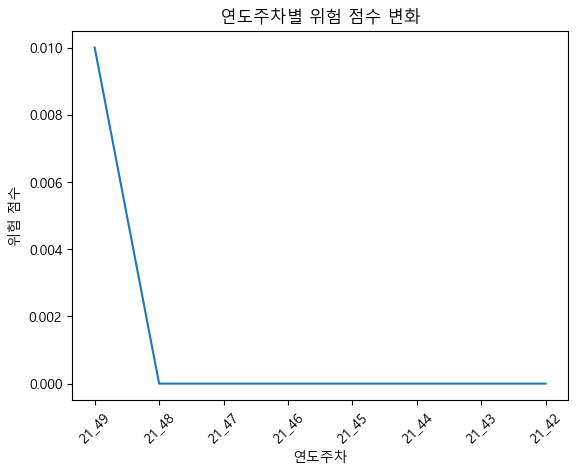

HS Code : 6403999000
21_49주차
0    56.651
1    57.430
2    61.704
3    59.156
4    58.785
5    56.215
6    55.136
7    53.046
8    53.916
9    55.969
10   60.142
11   69.866
12   73.783
13   73.991
14   68.629
15   66.752
16   64.875
17   64.729
18   65.305
19   60.903
20   61.623
21   57.752
22   54.839
23   57.454
24   53.092
25   53.606
26   54.857
27   54.729
28   57.214
29   60.208
30   61.342
31   62.758
32   61.777
33   62.208
34   60.837
35   55.581
36   53.511
37   48.890
38   48.163
39   48.104
40   49.620
41   51.017
42   51.319
43   52.885
44   55.537
45   58.611
46   58.966
47   60.728
48   58.845
49   56.422
50   55.847
51   55.922
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=252.115, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=562.003, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]    

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    57.958
1    56.651
2    57.430
3    61.704
4    59.156
5    58.785
6    56.215
7    55.136
8    53.046
9    53.916
10   55.969
11   60.142
12   69.866
13   73.783
14   73.991
15   68.629
16   66.752
17   64.875
18   64.729
19   65.305
20   60.903
21   61.623
22   57.752
23   54.839
24   57.454
25   53.092
26   53.606
27   54.857
28   54.729
29   57.214
30   60.208
31   61.342
32   62.758
33   61.777
34   62.208
35   60.837
36   55.581
37   53.511
38   48.890
39   48.163
40   48.104
41   49.620
42   51.017
43   51.319
44   52.885
45   55.537
46   58.611
47   58.966
48   60.728
49   58.845
50   56.422
51   55.847
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=254.480, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=562.073, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    197149.150
1    199147.776
2    198311.164
3    175366.949
4    152396.321
5    170796.983
6    167876.837
7    188928.668
8    211172.313
9    228826.520
10   226487.680
11   223980.398
12   192257.358
13   149261.509
14   152139.095
15   156269.393
16   187880.168
17   200660.488
18   205405.231
19   189411.643
20   176598.295
21   179478.138
22   176979.336
23   194145.809
24   205295.028
25   195456.959
26   212772.457
27   217841.734
28   218682.024
29   223989.285
30   199180.026
31   188918.611
32   179352.688
33   182767.727
34   188786.063
35   184185.342
36   192432.930
37   203234.962
38   205521.795
39   225247.443
40   217302.086
41   219814.068
42   212203.655
43   200144.419
44   214928.326
45   192098.482
46   186003.176
47   180867.923
48   174774.205
49   177966.628
50   192173.427
51   201199.847
Name: 신고중량, dtype: float64
Performing stepwise search 

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    128461.305
1    129962.521
2    144262.954
3    169456.410
4    197149.150
5    199147.776
6    198311.164
7    175366.949
8    152396.321
9    170796.983
10   167876.837
11   188928.668
12   211172.313
13   228826.520
14   226487.680
15   223980.398
16   192257.358
17   149261.509
18   152139.095
19   156269.393
20   187880.168
21   200660.488
22   205405.231
23   189411.643
24   176598.295
25   179478.138
26   176979.336
27   194145.809
28   205295.028
29   195456.959
30   212772.457
31   217841.734
32   218682.024
33   223989.285
34   199180.026
35   188918.611
36   179352.688
37   182767.727
38   188786.063
39   184185.342
40   192432.930
41   203234.962
42   205521.795
43   225247.443
44   217302.086
45   219814.068
46   212203.655
47   200144.419
48   214928.326
49   192098.482
50   186003.176
51   180867.923
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    158728.234
1    128461.305
2    129962.521
3    144262.954
4    169456.410
5    197149.150
6    199147.776
7    198311.164
8    175366.949
9    152396.321
10   170796.983
11   167876.837
12   188928.668
13   211172.313
14   228826.520
15   226487.680
16   223980.398
17   192257.358
18   149261.509
19   152139.095
20   156269.393
21   187880.168
22   200660.488
23   205405.231
24   189411.643
25   176598.295
26   179478.138
27   176979.336
28   194145.809
29   205295.028
30   195456.959
31   212772.457
32   217841.734
33   218682.024
34   223989.285
35   199180.026
36   188918.611
37   179352.688
38   182767.727
39   188786.063
40   184185.342
41   192432.930
42   203234.962
43   205521.795
44   225247.443
45   217302.086
46   219814.068
47   212203.655
48   200144.419
49   214928.326
50   192098.482
51   186003.176
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


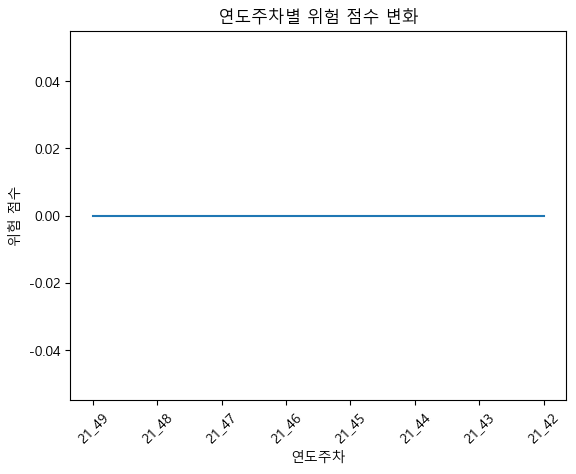

HS Code : 9031809099
21_49주차
0    118.813
1    130.360
2    144.109
3    139.926
4    131.068
5    120.233
6    110.134
7    113.228
8    116.638
9    119.542
10   126.038
11   172.230
12   168.641
13   158.830
14   162.813
15   127.183
16   138.774
17   132.574
18    99.811
19    99.872
20    90.912
21    96.972
22   130.949
23   141.057
24   132.804
25   137.055
26   134.151
27   119.467
28   110.096
29   104.505
30   116.429
31   126.678
32   162.260
33   178.553
34   159.912
35   160.643
36   148.701
37   135.297
38   135.422
39   123.892
40   120.175
41   112.424
42   111.989
43   116.235
44   112.779
45   130.123
46   117.327
47   127.949
48   132.913
49   125.392
50   137.810
51   139.566
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=644.260, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AI

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    159405.718
1    141906.169
2    123214.065
3    126757.859
4    128244.977
5    140214.064
6    155771.288
7    151962.699
8    137154.806
9    130821.274
10   129683.456
11   110399.881
12   125451.235
13   141869.405
14   143993.436
15   157473.529
16   154579.937
17   156843.965
18   197484.775
19   195251.764
20   196854.655
21   188420.641
22   142856.363
23   137485.545
24   154333.737
25   143744.136
26   152436.631
27   171015.941
28   185553.374
29   197324.026
30   197407.913
31   186206.204
32   137341.897
33   117648.834
34   114618.603
35   107369.644
36   123654.412
37   147558.789
38   144334.777
39   159664.859
40   154787.597
41   166204.231
42   164067.074
43   156857.698
44   156343.535
45   135971.268
46   154007.791
47   139872.852
48   146089.369
49   152011.951
50   135723.514
51   145023.962
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    104.632
1    118.813
2    130.360
3    144.109
4    139.926
5    131.068
6    120.233
7    110.134
8    113.228
9    116.638
10   119.542
11   126.038
12   172.230
13   168.641
14   158.830
15   162.813
16   127.183
17   138.774
18   132.574
19    99.811
20    99.872
21    90.912
22    96.972
23   130.949
24   141.057
25   132.804
26   137.055
27   134.151
28   119.467
29   110.096
30   104.505
31   116.429
32   126.678
33   162.260
34   178.553
35   159.912
36   160.643
37   148.701
38   135.297
39   135.422
40   123.892
41   120.175
42   112.424
43   111.989
44   116.235
45   112.779
46   130.123
47   117.327
48   127.949
49   132.913
50   125.392
51   137.810
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=643.791, Time=0.00 sec
 ARIMA(1

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    181409.024
1    159405.718
2    141906.169
3    123214.065
4    126757.859
5    128244.977
6    140214.064
7    155771.288
8    151962.699
9    137154.806
10   130821.274
11   129683.456
12   110399.881
13   125451.235
14   141869.405
15   143993.436
16   157473.529
17   154579.937
18   156843.965
19   197484.775
20   195251.764
21   196854.655
22   188420.641
23   142856.363
24   137485.545
25   154333.737
26   143744.136
27   152436.631
28   171015.941
29   185553.374
30   197324.026
31   197407.913
32   186206.204
33   137341.897
34   117648.834
35   114618.603
36   107369.644
37   123654.412
38   147558.789
39   144334.777
40   159664.859
41   154787.597
42   166204.231
43   164067.074
44   156857.698
45   156343.535
46   135971.268
47   154007.791
48   139872.852
49   146089.369
50   152011.951
51   135723.514
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0    107.556
1    106.330
2    104.632
3    118.813
4    130.360
5    144.109
6    139.926
7    131.068
8    120.233
9    110.134
10   113.228
11   116.638
12   119.542
13   126.038
14   172.230
15   168.641
16   158.830
17   162.813
18   127.183
19   138.774
20   132.574
21    99.811
22    99.872
23    90.912
24    96.972
25   130.949
26   141.057
27   132.804
28   137.055
29   134.151
30   119.467
31   110.096
32   104.505
33   116.429
34   126.678
35   162.260
36   178.553
37   159.912
38   160.643
39   148.701
40   135.297
41   135.422
42   123.892
43   120.175
44   112.424
45   111.989
46   116.235
47   112.779
48   130.123
49   117.327
50   127.949
51   132.913
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=643.172, Time=0.00 sec
 ARIMA(1

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    174236.669
1    174241.770
2    181409.024
3    159405.718
4    141906.169
5    123214.065
6    126757.859
7    128244.977
8    140214.064
9    155771.288
10   151962.699
11   137154.806
12   130821.274
13   129683.456
14   110399.881
15   125451.235
16   141869.405
17   143993.436
18   157473.529
19   154579.937
20   156843.965
21   197484.775
22   195251.764
23   196854.655
24   188420.641
25   142856.363
26   137485.545
27   154333.737
28   143744.136
29   152436.631
30   171015.941
31   185553.374
32   197324.026
33   197407.913
34   186206.204
35   137341.897
36   117648.834
37   114618.603
38   107369.644
39   123654.412
40   147558.789
41   144334.777
42   159664.859
43   154787.597
44   166204.231
45   164067.074
46   156857.698
47   156343.535
48   135971.268
49   154007.791
50   139872.852
51   146089.369
Name: 신고중량, dtype: float64
Performing stepwise search 

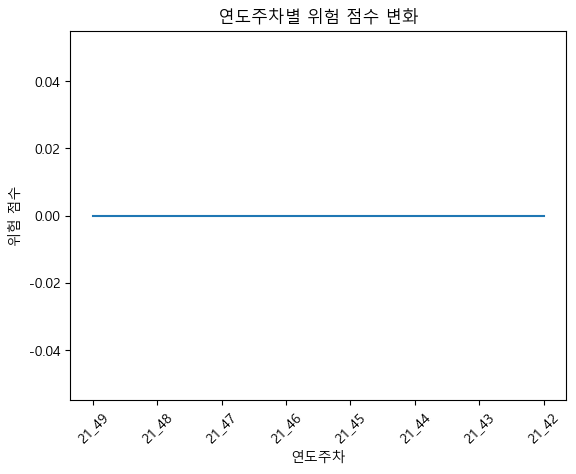

HS Code : 8542391000
21_49주차
0    2256.886
1    2242.619
2    2305.941
3    2781.164
4    2807.971
5    2761.921
6    2718.783
7    2557.276
8    2552.681
9    2749.718
10   2780.115
11   2647.720
12   2629.516
13   2468.133
14   2385.607
15   2466.182
16   2613.486
17   2703.610
18   2658.496
19   2801.852
20   2832.313
21   2719.244
22   2886.005
23   3027.613
24   2898.081
25   2923.625
26   2872.304
27   2555.152
28   2636.451
29   2869.053
30   2860.062
31   2879.000
32   2812.500
33   2607.264
34   2521.107
35   2405.614
36   2497.735
37   2528.978
38   2658.093
39   2616.743
40   2497.201
41   2465.869
42   2552.679
43   2662.523
44   2571.777
45   2676.266
46   2715.081
47   2634.333
48   2739.504
49   2821.855
50   2671.620
51   2790.034
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=951.213, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Ti

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    2132.867
1    2256.886
2    2242.619
3    2305.941
4    2781.164
5    2807.971
6    2761.921
7    2718.783
8    2557.276
9    2552.681
10   2749.718
11   2780.115
12   2647.720
13   2629.516
14   2468.133
15   2385.607
16   2466.182
17   2613.486
18   2703.610
19   2658.496
20   2801.852
21   2832.313
22   2719.244
23   2886.005
24   3027.613
25   2898.081
26   2923.625
27   2872.304
28   2555.152
29   2636.451
30   2869.053
31   2860.062
32   2879.000
33   2812.500
34   2607.264
35   2521.107
36   2405.614
37   2497.735
38   2528.978
39   2658.093
40   2616.743
41   2497.201
42   2465.869
43   2552.679
44   2662.523
45   2571.777
46   2676.266
47   2715.081
48   2634.333
49   2739.504
50   2821.855
51   2671.620
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0    2108.957
1    2121.899
2    2132.867
3    2256.886
4    2242.619
5    2305.941
6    2781.164
7    2807.971
8    2761.921
9    2718.783
10   2557.276
11   2552.681
12   2749.718
13   2780.115
14   2647.720
15   2629.516
16   2468.133
17   2385.607
18   2466.182
19   2613.486
20   2703.610
21   2658.496
22   2801.852
23   2832.313
24   2719.244
25   2886.005
26   3027.613
27   2898.081
28   2923.625
29   2872.304
30   2555.152
31   2636.451
32   2869.053
33   2860.062
34   2879.000
35   2812.500
36   2607.264
37   2521.107
38   2405.614
39   2497.735
40   2528.978
41   2658.093
42   2616.743
43   2497.201
44   2465.869
45   2552.679
46   2662.523
47   2571.777
48   2676.266
49   2715.081
50   2634.333
51   2739.504
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[

...

 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=948.875, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=651.485, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=648.845, Time=0.06 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=649.279, Time=0.08 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=646.830, Time=0.06 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=648.718, Time=0.10 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=650.681, Time=0.14 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=641.709, Time=0.07 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=649.953, Time=0.07 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=641.217

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(0,1,0)(0,0,0)[0]             : AIC=942.753, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=948.493, Time=0.05 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.132 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    2330.121
1    2319.455
2    2203.311
3    2035.302
4    2108.957
5    2121.899
6    2132.867
7    2256.886
8    2242.619
9    2305.941
10   2781.164
11   2807.971
12   2761.921
13   2718.783
14   2557.276
15   2552.681
16   2749.718
17   2780.115
18   2647.720
19   2629.516
20   2468.133
21   2385.607
22   2466.182
23   2613.486
24   2703.610
25   2658.496
26   2801.852
27   2832.313
28   2719.244
29   2886.005
30   3027.613
31   2898.081
32   2923.625
33   2872.304
34   2555.152
35   2636.451
36   2869.053
37   2860.062
38   2879.000
39   2812.500
40   2607.264
41   2521.107
42   2405.614
43   2497.735
44   2528.978
45   2658.093
46   2616.743
47   2497.201

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    59087.443
1    59766.603
2    59326.701
3    58986.152
4    58544.978
5    60032.578
6    62889.529
7    63850.649
8    60700.283
9    54490.840
10   53577.814
11   53873.643
12   58031.125
13   63704.304
14   64717.662
15   61313.521
16   56214.816
17   57786.492
18   56139.240
19   60781.844
20   65919.997
21   65911.369
22   68338.959
23   66497.641
24   69192.029
25   68168.037
26   68613.718
27   69126.845
28   66327.720
29   66368.793
30   66461.467
31   70040.871
32   69350.386
33   67404.706
34   66710.575
35   64802.143
36   65727.213
37   67994.939
38   66357.801
39   64729.049
40   62670.979
41   62764.928
42   61666.443
43   63515.818
44   64609.687
45   63312.367
46   65664.024
47   58722.211
48   66125.856
49   63802.615
50   60651.957
51   66794.558
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   

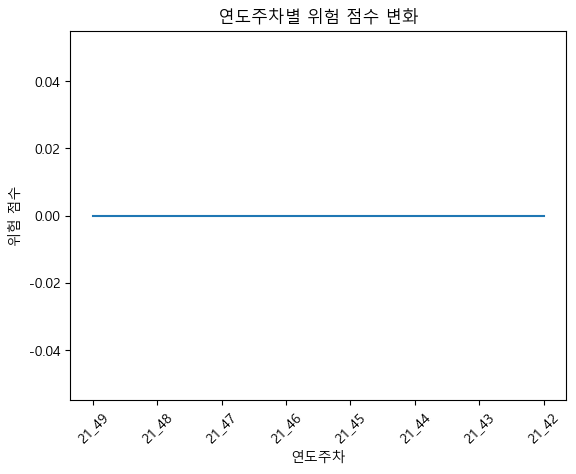

HS Code : 6109101000
21_49주차
0    23.925
1    25.071
2    26.246
3    25.052
4    24.693
5    24.251
6    23.896
7    24.105
8    24.540
9    24.040
10   23.204
11   23.723
12   23.581
13   22.758
14   22.995
15   21.824
16   20.911
17   21.489
18   21.456
19   21.403
20   21.996
21   21.933
22   22.313
23   22.951
24   22.849
25   22.531
26   22.500
27   23.974
28   24.004
29   24.344
30   24.130
31   24.132
32   24.172
33   24.955
34   23.940
35   22.848
36   22.947
37   21.375
38   21.525
39   20.103
40   19.431
41   19.184
42   19.041
43   19.373
44   20.153
45   20.896
46   21.317
47   21.456
48   21.058
49   21.662
50   22.473
51   23.765
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=107.455, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=108.731, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=108.760, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=1182.954, Time=0.01 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=1192.600, Time=0.00 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=1184.207, Time=0.02 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=1184.157, Time=0.02 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=1184.719, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=1181.228, Time=0.01 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=1182.042, Time=0.01 sec
 ARIMA(0,2,2)(0,0,0)[0]             : AIC=1181.903, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=1188.666, Time=0.01 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=1183.092, Time=0.03 sec

Best model:  ARIMA(0,2,1)(0,0,0)[0]          
Total fit time: 0.227 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    22.382
1    22.992
2    23.925
3    25.071
4    26.246
5    25.052
6    24.693
7    24.251
8    23.896
9    24.105
10   24.540
11   24.0

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1231.191, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1236.254, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1233.194, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1233.139, Time=0.05 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=1232.815, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=1228.393, Time=0.11 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=1225.923, Time=0.08 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=1225.330, Time=0.13 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=1228.866, Time=0.03 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=1225.866, Time=0.14 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=1226.555, Time=0.05 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=1228.015, Time=0.08 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=1223.761, Time=0.07 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=1232.295, Time=0.05 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=1226.549, Time=0.04 sec
 ARIMA(5,0

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0    20.352
1    19.366
2    20.716
3    22.459
4    22.382
5    22.992
6    23.925
7    25.071
8    26.246
9    25.052
10   24.693
11   24.251
12   23.896
13   24.105
14   24.540
15   24.040
16   23.204
17   23.723
18   23.581
19   22.758
20   22.995
21   21.824
22   20.911
23   21.489
24   21.456
25   21.403
26   21.996
27   21.933
28   22.313
29   22.951
30   22.849
31   22.531
32   22.500
33   23.974
34   24.004
35   24.344
36   24.130
37   24.132
38   24.172
39   24.955
40   23.940
41   22.848
42   22.947
43   21.375
44   21.525
45   20.103
46   19.431
47   19.184
48   19.041
49   19.373
50   20.153
51   20.896
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=465.202, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.00 sec

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    205193.052
1    208799.131
2    199090.151
3    182558.681
4    196411.517
5    201389.166
6    236235.962
7    249461.332
8    257769.357
9    347943.414
10   374962.800
11   440008.921
12   492790.831
13   496272.931
14   502448.792
15   556054.944
16   618732.455
17   604435.674
18   665011.716
19   712068.731
20   715810.698
21   872650.426
22   939812.717
23   928789.693
24   948204.910
25   882514.715
26   807553.246
27   742778.464
28   693137.735
29   616960.170
30   598763.631
31   618013.041
32   578206.952
33   516612.442
34   477899.593
35   433605.195
36   414416.509
37   416730.944
38   399856.540
39   354893.190
40   364071.580
41   350954.751
42   322802.760
43   328195.826
44   298013.337
45   302975.294
46   284270.597
47   285894.570
48   275910.890
49   247733.421
50   258139.695
51   234853.324
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


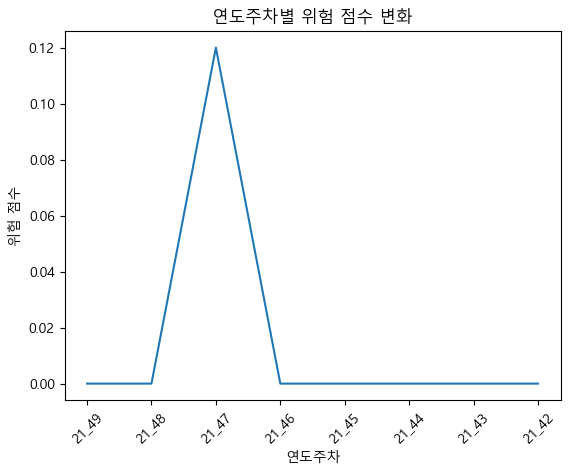

HS Code : 2934996000
21_49주차
0     28.606
1     27.447
2     13.863
3     11.236
4     22.536
5     23.756
6     25.531
7     11.229
8      9.159
9      8.996
10     8.717
11    22.087
12    33.561
13    31.723
14    25.376
15    16.853
16    15.676
17    18.773
18    16.361
19    15.949
20    17.563
21    13.767
22    17.856
23    19.525
24    14.938
25    11.916
26    11.108
27    10.050
28    11.546
29    24.292
30    15.135
31    20.345
32    20.420
33    25.873
34    66.601
35    76.920
36    21.054
37    17.107
38    19.446
39    17.662
40   107.723
41    29.228
42    22.686
43    27.045
44    28.083
45    65.921
46    31.501
47    23.281
48    21.387
49    14.191
50    15.392
51    14.963
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=445.770, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=493.695, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=455.534, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]         

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    18821.383
1    18862.281
2    15048.863
3    18815.891
4     7939.427
5     7909.596
6     7988.876
7    24979.876
8    25106.271
9    28840.466
10   35379.893
11   14619.165
12   10737.063
13   11520.767
14   16077.730
15   19829.516
16   22395.917
17   17856.616
18   24042.410
19   24064.265
20   22490.047
21   33740.466
22   20222.153
23   19011.696
24   19208.707
25   23707.086
26   23735.447
27   25083.470
28   23931.782
29    8168.822
30   16122.345
31   13146.499
32   13098.660
33   13099.198
34    5096.711
35    4156.396
36   20414.128
37   20403.587
38   16699.682
39   18103.931
40    1846.871
41   11630.620
42   15298.976
43   14043.247
44   14100.284
45    4422.167
46   10853.736
47   14521.340
48   18280.420
49   32932.036
50   26736.364
51   31285.905
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0     29.504
1     28.606
2     27.447
3     13.863
4     11.236
5     22.536
6     23.756
7     25.531
8     11.229
9      9.159
10     8.996
11     8.717
12    22.087
13    33.561
14    31.723
15    25.376
16    16.853
17    15.676
18    18.773
19    16.361
20    15.949
21    17.563
22    13.767
23    17.856
24    19.525
25    14.938
26    11.916
27    11.108
28    10.050
29    11.546
30    24.292
31    15.135
32    20.345
33    20.420
34    25.873
35    66.601
36    76.920
37    21.054
38    17.107
39    19.446
40    17.662
41   107.723
42    29.228
43    22.686
44    27.045
45    28.083
46    65.921
47    31.501
48    23.281
49    21.387
50    14.191
51    15.392
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=445.727, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=494.394, Time=0.00 sec
 ARI

...

 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1151.665, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1054.429, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1054.621, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1053.824, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1050.331, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1052.784, Time=0.07 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1051.288, Time=0.04 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=1056.087, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1046.671, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1044.688, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1045.404, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1042.690, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] i

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    14844.505
1    18603.185
2    26142.180
3    22404.916
4    21163.375
5    17366.822
6    18821.383
7    18862.281
8    15048.863
9    18815.891
10    7939.427
11    7909.596
12    7988.876
13   24979.876
14   25106.271
15   28840.466
16   35379.893
17   14619.165
18   10737.063
19   11520.767
20   16077.730
21   19829.516
22   22395.917
23   17856.616
24   24042.410
25   24064.265
26   22490.047
27   33740.466
28   20222.153
29   19011.696
30   19208.707
31   23707.086
32   23735.447
33   25083.470
34   23931.782
35    8168.822
36   16122.345
37   13146.499
38   13098.660
39   13099.198
40    5096.711
41    4156.396
42   20414.128
43   20403.587
44   16699.682
45   18103.931
46    1846.871
47   11630.620
48   15298.976
49   14043.247
50   14100.284
51    4422.167
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    18375.873
1    14844.505
2    18603.185
3    26142.180
4    22404.916
5    21163.375
6    17366.822
7    18821.383
8    18862.281
9    15048.863
10   18815.891
11    7939.427
12    7909.596
13    7988.876
14   24979.876
15   25106.271
16   28840.466
17   35379.893
18   14619.165
19   10737.063
20   11520.767
21   16077.730
22   19829.516
23   22395.917
24   17856.616
25   24042.410
26   24064.265
27   22490.047
28   33740.466
29   20222.153
30   19011.696
31   19208.707
32   23707.086
33   23735.447
34   25083.470
35   23931.782
36    8168.822
37   16122.345
38   13146.499
39   13098.660
40   13099.198
41    5096.711
42    4156.396
43   20414.128
44   20403.587
45   16699.682
46   18103.931
47    1846.871
48   11630.620
49   15298.976
50   14043.247
51   14100.284
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

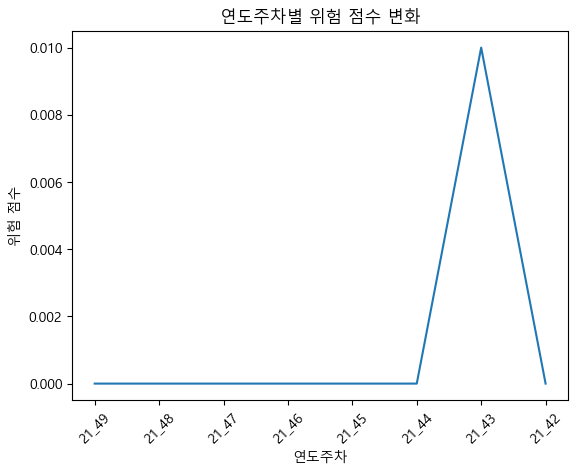

HS Code : 4016930000
21_49주차
0    34.964
1    36.334
2    36.767
3    38.210
4    38.089
5    36.646
6    39.592
7    38.335
8    36.446
9    40.501
10   40.052
11   45.578
12   49.965
13   50.065
14   46.072
15   42.161
16   43.278
17   42.829
18   45.216
19   44.219
20   44.366
21   41.591
22   42.556
23   44.247
24   41.460
25   41.786
26   40.328
27   39.917
28   38.604
29   38.424
30   41.718
31   41.623
32   43.638
33   48.012
34   44.963
35   44.949
36   44.890
37   44.164
38   45.132
39   43.587
40   42.196
41   37.635
42   38.165
43   39.788
44   42.177
45   45.030
46   44.373
47   39.100
48   35.789
49   35.687
50   31.437
51   33.010
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=527.007, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]        

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    104504.576
1     98283.787
2    100267.242
3     99946.791
4     97372.175
5     92455.967
6     94689.610
7     98809.827
8    104727.600
9    118160.091
10   112979.570
11    99891.753
12    92513.230
13    78766.203
14    80476.561
15    86805.219
16    93231.855
17    97816.822
18    94632.125
19    91410.564
20    83980.870
21    92772.956
22    91332.883
23    98136.791
24    97795.592
25    84961.463
26    88424.403
27    87811.152
28    92481.733
29    93346.291
30    96319.930
31    89162.166
32    89937.742
33    92982.405
34    85868.084
35    76576.080
36    85049.873
37    78698.679
38    79619.849
39    82744.229
40    70493.739
41    76204.696
42    68148.034
43    81537.011
44    77189.122
45    73995.291
46    79867.820
47    68833.236
48    71708.041
49    79219.858
50    87393.748
51    83756.169
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=240.986, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=242.522, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=233.083, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=232.635, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=285.026, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=232.843, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=232.348, Time=0.12 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=236.721, Time=0.15 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=234.741, Time=0.08 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=234.724

...

 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1025.668, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1026.831, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1026.982, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1023.755, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1028.937, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.180 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    40.487
1    38.235
2    36.441
3    36.458
4    34.381
5    34.080
6    35.074
7    34.964
8    36.334
9    36.767
10   38.210
11   38.089
12   36.646
13   39.592
14   38.335
15   36.446
16   40.501
17   40.052
18   45.578
19   49.965
20   50.065
21   46.072
22   42.161
23   43.278
24   42.829
25   45.216
26   44.219
27   44.366
28   41.591
29   42.556
30   44.247
31   41.460
32   41.786
33   40.328
34

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=223.453, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=225.317, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=225.311, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=221.455, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.350 seconds


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     86449.324
1     92859.179
2    101207.066
3    103475.251
4    108444.327
5    104504.576
6     98283.787
7    100267.242
8     99946.791
9     97372.175
10    92455.967
11    94689.610
12    98809.827
13   104727.600
14   118160.091
15   112979.570
16    99891.753
17    92513.230
18    78766.203
19    80476.561
20    86805.219
21    93231.855
22    97816.822
23    94632.125
24    91410.564
25    83980.870
26    92772.956
27    91332.883
28    98136.791
29    97795.592
30    84961.463
31    88424.403
32    87811.152
33    92481.733
34    93346.291
35    96319.930
36    89162.166
37    89937.742
38    92982.405
39    85868.084
40    76576.080
41    85049.873
42    78698.679
43    79619.849
44    82744.229
45    70493.739
46    76204.696
47    68148.034
48    81537.011
49    77189.122
50    73995.291
51    79867.820
Name: 신고중량, dtype: float64
Performing stepwise search 

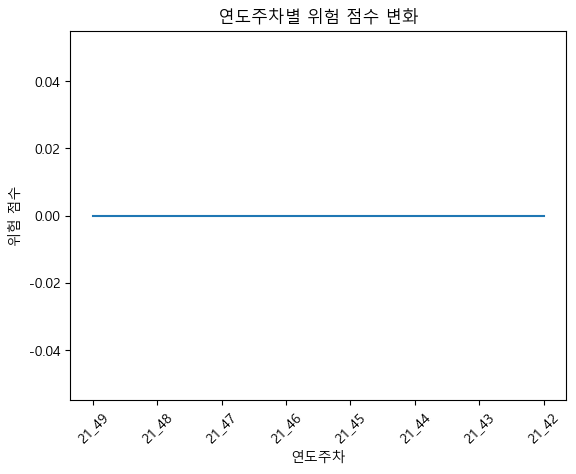

HS Code : 6110200000
21_49주차
0    29.242
1    31.971
2    29.360
3    28.236
4    27.051
5    26.557
6    26.970
7    28.380
8    30.147
9    31.425
10   34.940
11   39.486
12   40.695
13   41.860
14   43.280
15   40.787
16   43.373
17   45.237
18   47.186
19   53.835
20   56.008
21   59.799
22   57.506
23   59.377
24   58.055
25   51.578
26   52.098
27   48.919
28   42.901
29   43.594
30   38.884
31   36.076
32   32.105
33   30.618
34   28.697
35   28.287
36   28.307
37   27.167
38   27.181
39   25.334
40   25.229
41   24.506
42   23.943
43   24.304
44   24.689
45   25.488
46   26.261
47   28.087
48   28.842
49   29.952
50   29.433
51   29.035
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=225.954, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=517.082, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]    

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    274341.984
1    290656.063
2    299498.548
3    275640.367
4    297390.431
5    345911.408
6    363089.810
7    410319.862
8    437522.196
9    399271.177
10   377510.736
11   348515.607
12   285424.524
13   224653.800
14   196720.530
15   171201.544
16   151640.493
17   150454.720
18   127296.838
19   113382.112
20   106552.030
21    88683.924
22    78035.576
23    71602.144
24    76149.564
25    73984.084
26    82991.325
27    98366.740
28    93972.626
29   113234.487
30   150542.702
31   167251.436
32   218450.401
33   257252.360
34   318330.466
35   349277.878
36   413485.334
37   433176.196
38   440033.079
39   485690.108
40   516623.422
41   588906.316
42   557804.868
43   584349.055
44   527365.771
45   470512.983
46   510904.485
47   468842.053
48   467987.442
49   439229.849
50   383991.080
51   381517.140
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0    27.755
1    29.831
2    28.417
3    29.242
4    31.971
5    29.360
6    28.236
7    27.051
8    26.557
9    26.970
10   28.380
11   30.147
12   31.425
13   34.940
14   39.486
15   40.695
16   41.860
17   43.280
18   40.787
19   43.373
20   45.237
21   47.186
22   53.835
23   56.008
24   59.799
25   57.506
26   59.377
27   58.055
28   51.578
29   52.098
30   48.919
31   42.901
32   43.594
33   38.884
34   36.076
35   32.105
36   30.618
37   28.697
38   28.287
39   28.307
40   27.167
41   27.181
42   25.334
43   25.229
44   24.506
45   23.943
46   24.304
47   24.689
48   25.488
49   26.261
50   28.087
51   28.842
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=231.052, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=516.992, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    318120.708
1    308323.253
2    298612.587
3    294241.149
4    274341.984
5    290656.063
6    299498.548
7    275640.367
8    297390.431
9    345911.408
10   363089.810
11   410319.862
12   437522.196
13   399271.177
14   377510.736
15   348515.607
16   285424.524
17   224653.800
18   196720.530
19   171201.544
20   151640.493
21   150454.720
22   127296.838
23   113382.112
24   106552.030
25    88683.924
26    78035.576
27    71602.144
28    76149.564
29    73984.084
30    82991.325
31    98366.740
32    93972.626
33   113234.487
34   150542.702
35   167251.436
36   218450.401
37   257252.360
38   318330.466
39   349277.878
40   413485.334
41   433176.196
42   440033.079
43   485690.108
44   516623.422
45   588906.316
46   557804.868
47   584349.055
48   527365.771
49   470512.983
50   510904.485
51   468842.053
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    26.539
1    26.202
2    26.664
3    28.214
4    27.755
5    29.831
6    28.417
7    29.242
8    31.971
9    29.360
10   28.236
11   27.051
12   26.557
13   26.970
14   28.380
15   30.147
16   31.425
17   34.940
18   39.486
19   40.695
20   41.860
21   43.280
22   40.787
23   43.373
24   45.237
25   47.186
26   53.835
27   56.008
28   59.799
29   57.506
30   59.377
31   58.055
32   51.578
33   52.098
34   48.919
35   42.901
36   43.594
37   38.884
38   36.076
39   32.105
40   30.618
41   28.697
42   28.287
43   28.307
44   27.167
45   27.181
46   25.334
47   25.229
48   24.506
49   23.943
50   24.304
51   24.689
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=231.972, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=517.105, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


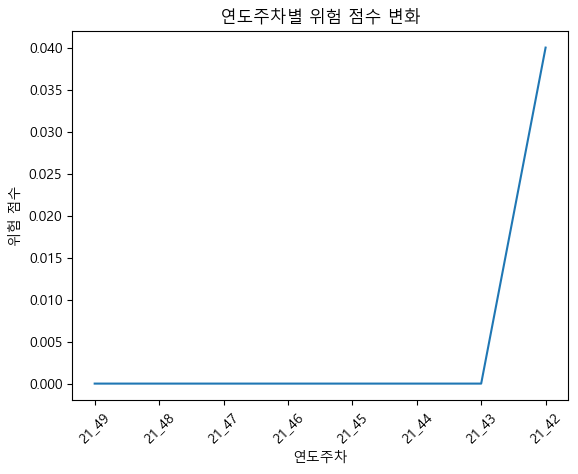

HS Code : 6211499000
21_49주차
0     96.327
1    102.811
2     85.643
3     87.263
4     79.523
5     78.595
6     73.966
7     69.008
8     70.526
9     63.778
10    80.995
11    96.713
12   101.430
13   110.217
14   102.788
15    87.171
16    82.433
17    80.998
18    71.119
19    75.749
20    73.745
21    67.025
22    69.800
23    62.408
24    57.960
25    56.332
26    55.327
27    59.201
28    60.941
29    67.440
30    66.584
31    67.730
32    67.393
33    66.757
34    73.343
35    74.225
36    84.551
37    96.160
38   104.628
39   114.019
40   117.450
41   110.432
42   100.889
43   105.202
44   109.434
45   118.172
46   118.344
47   127.502
48   136.372
49   145.321
50   164.524
51   159.496
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=350.715, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=347.195, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    26930.459
1    24421.996
2    25027.774
3    21604.538
4    22161.393
5    22568.227
6    26826.899
7    28972.130
8    25455.630
9    27769.148
10   21867.247
11   18280.738
12   19556.000
13   18692.384
14   20379.634
15   24753.296
16   25092.587
17   25113.794
18   26347.047
19   23875.302
20   25154.702
21   26195.039
22   24931.866
23   26747.747
24   27421.702
25   26681.170
26   25954.544
27   24207.117
28   24995.344
29   23005.472
30   26285.071
31   27927.277
32   28003.912
33   30946.812
34   27645.858
35   27631.550
36   25543.089
37   23822.939
38   23490.415
39   23577.738
40   22772.998
41   24642.840
42   27567.414
43   28357.225
44   31992.191
45   32554.913
46   34226.559
47   32949.703
48   30370.130
49   27891.669
50   25590.161
51   27028.707
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=358.570, Time=0.03 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=352.629, Time=0.09 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=351.297, Time=0.11 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=352.633, Time=0.16 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=352.212, Time=0.16 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(3,0,4)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=348.294, Time=0.17 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=348.771, Time=0.12 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=351.147, Time=0.10 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=350.066, Time=0.18 sec
 ARIMA(2,0,4)(0,0,0)[0] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=351.013

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    21761.330
1    24586.038
2    22767.428
3    25623.370
4    26930.459
5    24421.996
6    25027.774
7    21604.538
8    22161.393
9    22568.227
10   26826.899
11   28972.130
12   25455.630
13   27769.148
14   21867.247
15   18280.738
16   19556.000
17   18692.384
18   20379.634
19   24753.296
20   25092.587
21   25113.794
22   26347.047
23   23875.302
24   25154.702
25   26195.039
26   24931.866
27   26747.747
28   27421.702
29   26681.170
30   25954.544
31   24207.117
32   24995.344
33   23005.472
34   26285.071
35   27927.277
36   28003.912
37   30946.812
38   27645.858
39   27631.550
40   25543.089
41   23822.939
42   23490.415
43   23577.738
44   22772.998
45   24642.840
46   27567.414
47   28357.225
48   31992.191
49   32554.913
50   34226.559
51   32949.703
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    23725.444
1    21761.330
2    24586.038
3    22767.428
4    25623.370
5    26930.459
6    24421.996
7    25027.774
8    21604.538
9    22161.393
10   22568.227
11   26826.899
12   28972.130
13   25455.630
14   27769.148
15   21867.247
16   18280.738
17   19556.000
18   18692.384
19   20379.634
20   24753.296
21   25092.587
22   25113.794
23   26347.047
24   23875.302
25   25154.702
26   26195.039
27   24931.866
28   26747.747
29   27421.702
30   26681.170
31   25954.544
32   24207.117
33   24995.344
34   23005.472
35   26285.071
36   27927.277
37   28003.912
38   30946.812
39   27645.858
40   27631.550
41   25543.089
42   23822.939
43   23490.415
44   23577.738
45   22772.998
46   24642.840
47   27567.414
48   28357.225
49   31992.191
50   32554.913
51   34226.559
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    24157.113
1    23725.444
2    21761.330
3    24586.038
4    22767.428
5    25623.370
6    26930.459
7    24421.996
8    25027.774
9    21604.538
10   22161.393
11   22568.227
12   26826.899
13   28972.130
14   25455.630
15   27769.148
16   21867.247
17   18280.738
18   19556.000
19   18692.384
20   20379.634
21   24753.296
22   25092.587
23   25113.794
24   26347.047
25   23875.302
26   25154.702
27   26195.039
28   24931.866
29   26747.747
30   27421.702
31   26681.170
32   25954.544
33   24207.117
34   24995.344
35   23005.472
36   26285.071
37   27927.277
38   28003.912
39   30946.812
40   27645.858
41   27631.550
42   25543.089
43   23822.939
44   23490.415
45   23577.738
46   22772.998
47   24642.840
48   27567.414
49   28357.225
50   31992.191
51   32554.913
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

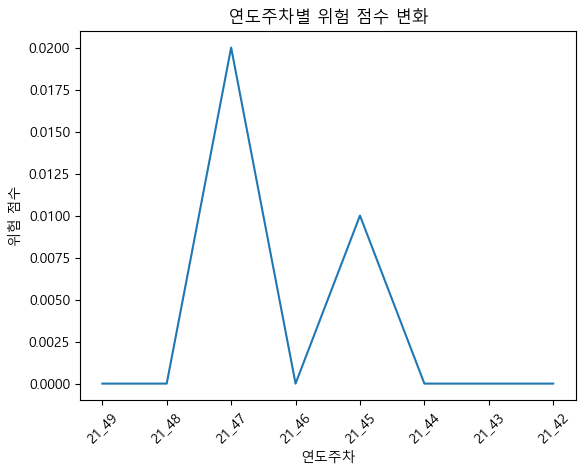

HS Code : 4202999000
21_49주차
0    34.122
1    34.382
2    34.261
3    35.999
4    34.259
5    30.404
6    30.961
7    32.569
8    33.650
9    45.540
10   54.492
11   63.134
12   66.367
13   49.232
14   42.242
15   38.988
16   35.145
17   37.519
18   41.410
19   42.431
20   41.669
21   41.410
22   39.800
23   35.176
24   38.123
25   35.823
26   37.131
27   44.852
28   44.968
29   45.023
30   42.262
31   41.153
32   36.810
33   41.165
34   41.135
35   40.156
36   45.728
37   48.495
38   47.793
39   44.326
40   46.424
41   40.933
42   38.527
43   39.665
44   39.015
45   37.981
46   40.386
47   38.123
48   39.121
49   43.100
50   40.884
51   44.380
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=527.055, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]        

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    64727.059
1    66723.245
2    67152.349
3    61066.964
4    55428.709
5    55706.149
6    63913.987
7    68270.610
8    69112.077
9    62976.340
10   47304.053
11   39131.426
12   31463.999
13   32201.121
14   43691.699
15   53012.843
16   59486.694
17   65225.049
18   61583.547
19   55881.757
20   57716.022
21   59666.627
22   58611.340
23   59282.937
24   63785.790
25   59075.356
26   62289.757
27   60217.443
28   50010.755
29   49202.336
30   49535.937
31   53348.804
32   52855.733
33   58966.901
34   50958.578
35   48476.045
36   47847.189
37   40827.168
38   39361.320
39   39138.140
40   44134.174
41   41307.308
42   47215.491
43   50667.020
44   49886.807
45   57060.781
46   58751.327
47   57035.059
48   60770.331
49   58016.397
50   52566.602
51   54655.934
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    59285.395
1    63827.313
2    64727.059
3    66723.245
4    67152.349
5    61066.964
6    55428.709
7    55706.149
8    63913.987
9    68270.610
10   69112.077
11   62976.340
12   47304.053
13   39131.426
14   31463.999
15   32201.121
16   43691.699
17   53012.843
18   59486.694
19   65225.049
20   61583.547
21   55881.757
22   57716.022
23   59666.627
24   58611.340
25   59282.937
26   63785.790
27   59075.356
28   62289.757
29   60217.443
30   50010.755
31   49202.336
32   49535.937
33   53348.804
34   52855.733
35   58966.901
36   50958.578
37   48476.045
38   47847.189
39   40827.168
40   39361.320
41   39138.140
42   44134.174
43   41307.308
44   47215.491
45   50667.020
46   49886.807
47   57060.781
48   58751.327
49   57035.059
50   60770.331
51   58016.397
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    42.221
1    42.390
2    38.003
3    37.639
4    33.032
5    32.629
6    33.474
7    34.122
8    34.382
9    34.261
10   35.999
11   34.259
12   30.404
13   30.961
14   32.569
15   33.650
16   45.540
17   54.492
18   63.134
19   66.367
20   49.232
21   42.242
22   38.988
23   35.145
24   37.519
25   41.410
26   42.431
27   41.669
28   41.410
29   39.800
30   35.176
31   38.123
32   35.823
33   37.131
34   44.852
35   44.968
36   45.023
37   42.262
38   41.153
39   36.810
40   41.165
41   41.135
42   40.156
43   45.728
44   48.495
45   47.793
46   44.326
47   46.424
48   40.933
49   38.527
50   39.665
51   39.015
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=303.189, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=526.245, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    51864.949
1    51323.149
2    57595.730
3    58431.123
4    59285.395
5    63827.313
6    64727.059
7    66723.245
8    67152.349
9    61066.964
10   55428.709
11   55706.149
12   63913.987
13   68270.610
14   69112.077
15   62976.340
16   47304.053
17   39131.426
18   31463.999
19   32201.121
20   43691.699
21   53012.843
22   59486.694
23   65225.049
24   61583.547
25   55881.757
26   57716.022
27   59666.627
28   58611.340
29   59282.937
30   63785.790
31   59075.356
32   62289.757
33   60217.443
34   50010.755
35   49202.336
36   49535.937
37   53348.804
38   52855.733
39   58966.901
40   50958.578
41   48476.045
42   47847.189
43   40827.168
44   39361.320
45   39138.140
46   44134.174
47   41307.308
48   47215.491
49   50667.020
50   49886.807
51   57060.781
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


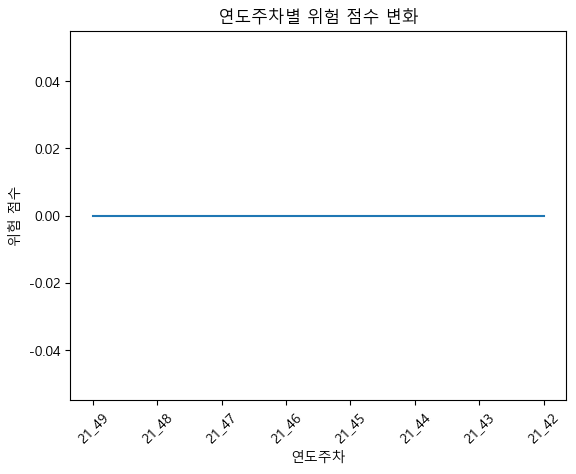

HS Code : 3304991000
21_49주차
0     86.209
1     90.662
2     87.106
3     83.125
4     89.438
5     84.440
6     90.622
7     97.621
8    101.033
9    103.631
10   102.218
11   100.352
12    92.587
13    89.308
14    87.586
15    86.982
16    90.305
17    91.645
18    88.063
19    87.028
20    97.857
21   100.398
22   105.771
23   101.253
24    93.449
25   102.502
26    89.798
27   100.392
28    93.211
29    92.208
30   102.791
31    97.401
32    93.918
33    82.582
34    75.572
35    79.222
36    84.726
37    95.474
38    96.160
39    96.530
40   103.886
41    93.192
42    94.514
43    90.522
44    84.103
45    87.149
46    87.620
47    93.232
48   100.862
49   102.075
50   101.132
51    94.004
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=336.837, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=609.486, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0     86.380
1     86.209
2     90.662
3     87.106
4     83.125
5     89.438
6     84.440
7     90.622
8     97.621
9    101.033
10   103.631
11   102.218
12   100.352
13    92.587
14    89.308
15    87.586
16    86.982
17    90.305
18    91.645
19    88.063
20    87.028
21    97.857
22   100.398
23   105.771
24   101.253
25    93.449
26   102.502
27    89.798
28   100.392
29    93.211
30    92.208
31   102.791
32    97.401
33    93.918
34    82.582
35    75.572
36    79.222
37    84.726
38    95.474
39    96.160
40    96.530
41   103.886
42    93.192
43    94.514
44    90.522
45    84.103
46    87.149
47    87.620
48    93.232
49   100.862
50   102.075
51   101.132
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=609.167, Time=0.00 sec
 ARIMA(1

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    806620.066
1    813954.435
2    729455.866
3    849781.143
4    845819.417
5    855045.945
6    895898.917
7    863778.879
8    773564.771
9    737856.007
10   693434.264
11   648984.694
12   752263.109
13   762292.448
14   712792.733
15   707502.222
16   791944.354
17   851615.701
18   946542.836
19   911068.268
20   788309.735
21   678862.908
22   609830.681
23   614372.756
24   657510.563
25   616650.975
26   710133.699
27   812113.305
28   791814.180
29   822443.864
30   684679.278
31   594627.936
32   633933.438
33   800177.722
34   853352.563
35   938352.973
36   961776.628
37   802083.205
38   845855.793
39   804272.893
40   835240.049
41   927412.114
42   926436.445
43   883914.840
44   947810.825
45   903737.995
46   833809.597
47   931299.077
48   831421.180
49   804589.785
50   948225.543
51   827092.531
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    825592.740
1    806620.066
2    813954.435
3    729455.866
4    849781.143
5    845819.417
6    855045.945
7    895898.917
8    863778.879
9    773564.771
10   737856.007
11   693434.264
12   648984.694
13   752263.109
14   762292.448
15   712792.733
16   707502.222
17   791944.354
18   851615.701
19   946542.836
20   911068.268
21   788309.735
22   678862.908
23   609830.681
24   614372.756
25   657510.563
26   616650.975
27   710133.699
28   812113.305
29   791814.180
30   822443.864
31   684679.278
32   594627.936
33   633933.438
34   800177.722
35   853352.563
36   938352.973
37   961776.628
38   802083.205
39   845855.793
40   804272.893
41   835240.049
42   927412.114
43   926436.445
44   883914.840
45   947810.825
46   903737.995
47   833809.597
48   931299.077
49   831421.180
50   804589.785
51   948225.543
Name: 신고중량, dtype: float64
Performing stepwise search 

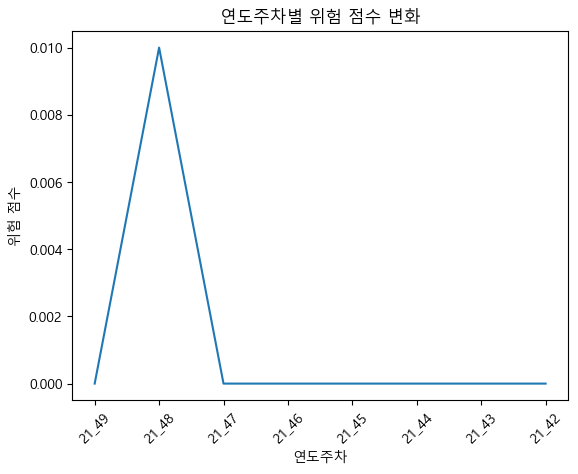

HS Code : 8544429090
21_49주차
0    33.005
1    32.264
2    32.498
3    31.718
4    30.811
5    31.764
6    31.790
7    31.511
8    30.684
9    29.947
10   31.312
11   40.186
12   44.108
13   46.488
14   38.744
15   33.197
16   30.249
17   26.857
18   27.152
19   27.316
20   28.151
21   31.244
22   31.697
23   30.831
24   29.622
25   30.586
26   28.875
27   29.252
28   30.389
29   28.860
30   30.077
31   29.858
32   29.927
33   29.275
34   34.111
35   32.204
36   36.544
37   33.690
38   31.450
39   35.713
40   37.022
41   39.309
42   41.930
43   39.240
44   35.037
45   37.018
46   35.180
47   35.981
48   31.080
49   29.912
50   28.823
51   28.628
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=260.130, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=503.724, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]    

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    33.187
1    33.005
2    32.264
3    32.498
4    31.718
5    30.811
6    31.764
7    31.790
8    31.511
9    30.684
10   29.947
11   31.312
12   40.186
13   44.108
14   46.488
15   38.744
16   33.197
17   30.249
18   26.857
19   27.152
20   27.316
21   28.151
22   31.244
23   31.697
24   30.831
25   29.622
26   30.586
27   28.875
28   29.252
29   30.389
30   28.860
31   30.077
32   29.858
33   29.927
34   29.275
35   34.111
36   32.204
37   36.544
38   33.690
39   31.450
40   35.713
41   37.022
42   39.309
43   41.930
44   39.240
45   35.037
46   37.018
47   35.180
48   35.981
49   31.080
50   29.912
51   28.823
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=503.970, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     94367.054
1     95193.824
2    100191.542
3    101156.466
4    104575.839
5     90694.047
6     91340.301
7     97390.501
8     93108.943
9    108288.520
10   114102.541
11   107743.333
12   110252.016
13    94104.531
14    73504.044
15    70308.645
16    72606.482
17    96151.522
18   106836.255
19   119633.426
20   134854.356
21   133557.645
22   138059.527
23   139239.920
24   121560.253
25   113327.270
26   114838.293
27   128562.463
28   127314.430
29   137821.567
30   136035.254
31   121862.583
32   129366.433
33   129812.106
34   127527.540
35   118953.236
36   113053.112
37   107584.864
38   113903.773
39   118003.728
40   133489.267
41   138924.272
42   134654.537
43   132284.163
44   128772.008
45   110506.666
46   113239.637
47   105713.957
48    91314.781
49    95608.976
50    87138.171
51   112774.511
Name: 신고중량, dtype: float64
Performing stepwise search 

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     97660.556
1     98647.152
2    100301.719
3     94367.054
4     95193.824
5    100191.542
6    101156.466
7    104575.839
8     90694.047
9     91340.301
10    97390.501
11    93108.943
12   108288.520
13   114102.541
14   107743.333
15   110252.016
16    94104.531
17    73504.044
18    70308.645
19    72606.482
20    96151.522
21   106836.255
22   119633.426
23   134854.356
24   133557.645
25   138059.527
26   139239.920
27   121560.253
28   113327.270
29   114838.293
30   128562.463
31   127314.430
32   137821.567
33   136035.254
34   121862.583
35   129366.433
36   129812.106
37   127527.540
38   118953.236
39   113053.112
40   107584.864
41   113903.773
42   118003.728
43   133489.267
44   138924.272
45   134654.537
46   132284.163
47   128772.008
48   110506.666
49   113239.637
50   105713.957
51    91314.781
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    31.589
1    34.058
2    33.389
3    32.400
4    34.398
5    33.360
6    33.187
7    33.005
8    32.264
9    32.498
10   31.718
11   30.811
12   31.764
13   31.790
14   31.511
15   30.684
16   29.947
17   31.312
18   40.186
19   44.108
20   46.488
21   38.744
22   33.197
23   30.249
24   26.857
25   27.152
26   27.316
27   28.151
28   31.244
29   31.697
30   30.831
31   29.622
32   30.586
33   28.875
34   29.252
35   30.389
36   28.860
37   30.077
38   29.858
39   29.927
40   29.275
41   34.111
42   32.204
43   36.544
44   33.690
45   31.450
46   35.713
47   37.022
48   39.309
49   41.930
50   39.240
51   35.037
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=254.037, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=503.631, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    103150.942
1     97660.556
2     98647.152
3    100301.719
4     94367.054
5     95193.824
6    100191.542
7    101156.466
8    104575.839
9     90694.047
10    91340.301
11    97390.501
12    93108.943
13   108288.520
14   114102.541
15   107743.333
16   110252.016
17    94104.531
18    73504.044
19    70308.645
20    72606.482
21    96151.522
22   106836.255
23   119633.426
24   134854.356
25   133557.645
26   138059.527
27   139239.920
28   121560.253
29   113327.270
30   114838.293
31   128562.463
32   127314.430
33   137821.567
34   136035.254
35   121862.583
36   129366.433
37   129812.106
38   127527.540
39   118953.236
40   113053.112
41   107584.864
42   113903.773
43   118003.728
44   133489.267
45   138924.272
46   134654.537
47   132284.163
48   128772.008
49   110506.666
50   113239.637
51   105713.957
Name: 신고중량, dtype: float64
Performing stepwise search 

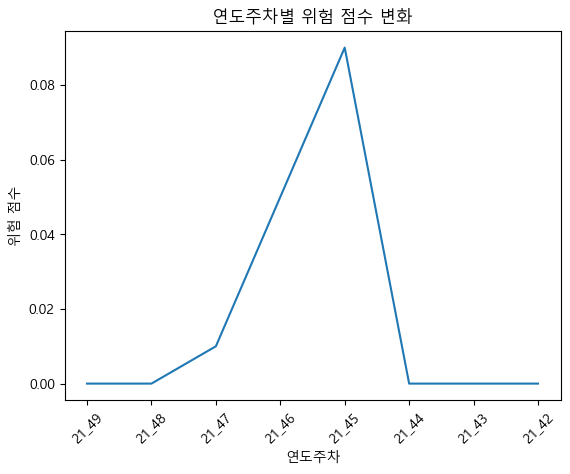

HS Code : 8481801090
21_49주차
0    25.851
1    26.282
2    27.341
3    25.815
4    25.447
5    25.375
6    24.835
7    26.846
8    27.876
9    26.938
10   29.803
11   29.993
12   31.451
13   34.726
14   27.255
15   26.708
16   24.905
17   24.714
18   27.729
19   27.359
20   27.358
21   24.365
22   23.351
23   23.010
24   22.514
25   24.061
26   24.182
27   25.071
28   28.037
29   26.870
30   29.777
31   29.891
32   27.262
33   30.132
34   28.334
35   28.621
36   30.185
37   29.069
38   28.940
39   28.355
40   26.087
41   26.331
42   27.637
43   29.827
44   32.096
45   32.221
46   31.919
47   31.963
48   30.497
49   30.985
50   29.167
51   28.663
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=218.221, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=486.181, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]    

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    26.119
1    26.779
2    25.851
3    26.282
4    27.341
5    25.815
6    25.447
7    25.375
8    24.835
9    26.846
10   27.876
11   26.938
12   29.803
13   29.993
14   31.451
15   34.726
16   27.255
17   26.708
18   24.905
19   24.714
20   27.729
21   27.359
22   27.358
23   24.365
24   23.351
25   23.010
26   22.514
27   24.061
28   24.182
29   25.071
30   28.037
31   26.870
32   29.777
33   29.891
34   27.262
35   30.132
36   28.334
37   28.621
38   30.185
39   29.069
40   28.940
41   28.355
42   26.087
43   26.331
44   27.637
45   29.827
46   32.096
47   32.221
48   31.919
49   31.963
50   30.497
51   30.985
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=218.454, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=485.649, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
0    26.824
1    27.363
2    26.119
3    26.779
4    25.851
5    26.282
6    27.341
7    25.815
8    25.447
9    25.375
10   24.835
11   26.846
12   27.876
13   26.938
14   29.803
15   29.993
16   31.451
17   34.726
18   27.255
19   26.708
20   24.905
21   24.714
22   27.729
23   27.359
24   27.358
25   24.365
26   23.351
27   23.010
28   22.514
29   24.061
30   24.182
31   25.071
32   28.037
33   26.870
34   29.777
35   29.891
36   27.262
37   30.132
38   28.334
39   28.621
40   30.185
41   29.069
42   28.940
43   28.355
44   26.087
45   26.331
46   27.637
47   29.827
48   32.096
49   32.221
50   31.919
51   31.963
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=218.028, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=485.017, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    733440.520
1    690005.848
2    720533.267
3    713461.161
4    730256.448
5    745657.387
6    735916.234
7    656786.258
8    626885.485
9    699180.763
10   718567.250
11   860693.386
12   905105.367
13   816191.459
14   853771.850
15   731216.577
16   686092.307
17   675586.253
18   616090.162
19   744523.519
20   775825.052
21   853465.530
22   856390.379
23   782330.475
24   790164.627
25   768365.829
26   869983.630
27   885629.355
28   955128.728
29   960218.899
30   910728.845
31   939013.289
32   902560.562
33   833864.725
34   829148.369
35   757008.066
36   715641.028
37   759853.742
38   671579.128
39   703141.498
40   670483.630
41   642616.048
42   718841.949
43   724158.294
44   754568.091
45   729300.417
46   731993.066
47   692933.386
48   711410.008
49   773027.618
50   770501.627
51   832751.237
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    734731.703
1    733440.520
2    690005.848
3    720533.267
4    713461.161
5    730256.448
6    745657.387
7    735916.234
8    656786.258
9    626885.485
10   699180.763
11   718567.250
12   860693.386
13   905105.367
14   816191.459
15   853771.850
16   731216.577
17   686092.307
18   675586.253
19   616090.162
20   744523.519
21   775825.052
22   853465.530
23   856390.379
24   782330.475
25   790164.627
26   768365.829
27   869983.630
28   885629.355
29   955128.728
30   960218.899
31   910728.845
32   939013.289
33   902560.562
34   833864.725
35   829148.369
36   757008.066
37   715641.028
38   759853.742
39   671579.128
40   703141.498
41   670483.630
42   642616.048
43   718841.949
44   724158.294
45   754568.091
46   729300.417
47   731993.066
48   692933.386
49   711410.008
50   773027.618
51   770501.627
Name: 신고중량, dtype: float64
Performing stepwise search 

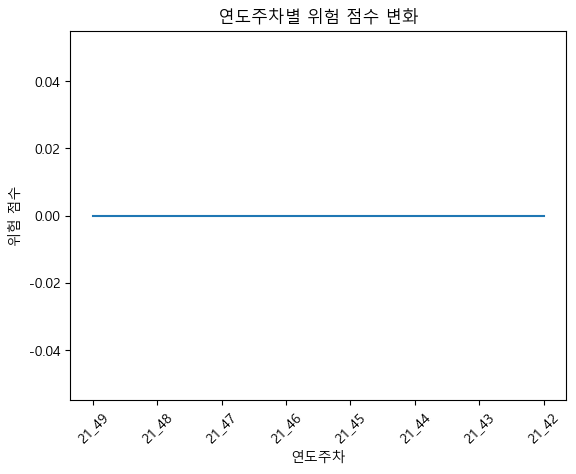

HS Code : 3304999000
21_49주차
0     90.809
1     93.545
2     88.786
3     83.044
4     80.828
5     78.896
6     92.117
7     92.729
8     91.215
9     90.842
10    82.403
11    78.346
12    76.600
13    77.672
14    75.443
15    74.243
16    71.886
17    73.915
18    78.705
19    79.987
20    82.923
21    81.802
22    76.558
23    85.536
24    87.232
25    88.889
26    93.692
27    88.415
28    83.085
29    83.627
30    80.657
31    82.861
32    87.510
33    82.528
34    89.455
35    83.277
36    84.880
37    96.618
38    88.420
39    97.880
40    96.303
41    85.821
42    82.497
43    74.574
44    75.490
45    83.791
46    87.179
47   104.167
48   105.345
49   106.571
50   108.641
51    90.883
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=329.123, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=601.633, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    69085.617
1    69945.386
2    63323.314
3    55280.012
4    58239.447
5    65541.687
6    77103.102
7    83607.440
8    76749.692
9    78091.016
10   72623.321
11   66754.132
12   68426.881
13   72709.815
14   66355.998
15   65671.971
16   61989.013
17   57669.616
18   66968.734
19   69269.887
20   67478.111
21   68916.611
22   65299.890
23   63595.200
24   65044.903
25   61328.417
26   56158.347
27   61009.977
28   59997.862
29   55924.739
30   60633.841
31   54774.001
32   59999.179
33   59201.526
34   64398.654
35   65276.598
36   61356.113
37   61398.719
38   51998.954
39   59043.005
40   57436.288
41   57358.990
42   63865.247
43   61862.042
44   64290.606
45   62892.462
46   58195.679
47   55871.336
48   54202.907
49   55450.908
50   57417.412
51   61359.202
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0     78.938
1     90.809
2     93.545
3     88.786
4     83.044
5     80.828
6     78.896
7     92.117
8     92.729
9     91.215
10    90.842
11    82.403
12    78.346
13    76.600
14    77.672
15    75.443
16    74.243
17    71.886
18    73.915
19    78.705
20    79.987
21    82.923
22    81.802
23    76.558
24    85.536
25    87.232
26    88.889
27    93.692
28    88.415
29    83.085
30    83.627
31    80.657
32    82.861
33    87.510
34    82.528
35    89.455
36    83.277
37    84.880
38    96.618
39    88.420
40    97.880
41    96.303
42    85.821
43    82.497
44    74.574
45    75.490
46    83.791
47    87.179
48   104.167
49   105.345
50   106.571
51   108.641
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=600.883, Time=0.00 sec
 ARIMA(1

...

 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=598.171, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=330.942, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=329.561, Time=0.07 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec

Best model:  ARIMA(1,0,2)(0,0,0)[0]          
Total fit time: 0.759 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    58996.159
1    57295.920
2    70734.980
3    64969.723
4    

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    73.481
1    81.639
2    82.149
3    74.338
4    67.371
5    70.632
6    78.938
7    90.809
8    93.545
9    88.786
10   83.044
11   80.828
12   78.896
13   92.117
14   92.729
15   91.215
16   90.842
17   82.403
18   78.346
19   76.600
20   77.672
21   75.443
22   74.243
23   71.886
24   73.915
25   78.705
26   79.987
27   82.923
28   81.802
29   76.558
30   85.536
31   87.232
32   88.889
33   93.692
34   88.415
35   83.085
36   83.627
37   80.657
38   82.861
39   87.510
40   82.528
41   89.455
42   83.277
43   84.880
44   96.618
45   88.420
46   97.880
47   96.303
48   85.821
49   82.497
50   74.574
51   75.490
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=598.128, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    68751.597
1    58996.159
2    57295.920
3    70734.980
4    64969.723
5    68809.707
6    73544.588
7    69085.617
8    69945.386
9    63323.314
10   55280.012
11   58239.447
12   65541.687
13   77103.102
14   83607.440
15   76749.692
16   78091.016
17   72623.321
18   66754.132
19   68426.881
20   72709.815
21   66355.998
22   65671.971
23   61989.013
24   57669.616
25   66968.734
26   69269.887
27   67478.111
28   68916.611
29   65299.890
30   63595.200
31   65044.903
32   61328.417
33   56158.347
34   61009.977
35   59997.862
36   55924.739
37   60633.841
38   54774.001
39   59999.179
40   59201.526
41   64398.654
42   65276.598
43   61356.113
44   61398.719
45   51998.954
46   59043.005
47   57436.288
48   57358.990
49   63865.247
50   61862.042
51   64290.606
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   

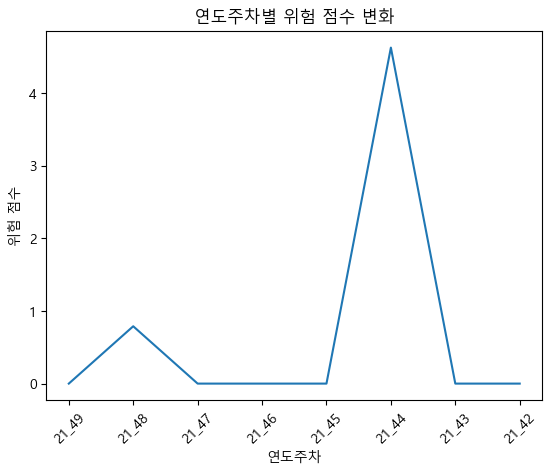

HS Code : 8543709090
21_49주차
0    185.806
1    175.138
2    187.684
3    180.225
4    187.441
5    214.822
6    206.267
7    200.597
8    193.947
9    171.738
10   168.679
11   174.741
12   213.336
13   226.724
14   242.045
15   248.765
16   198.314
17   169.820
18   168.075
19   166.659
20   156.142
21   159.779
22   142.664
23   130.261
24   121.516
25   120.152
26   110.349
27   110.439
28   112.164
29   106.178
30   109.278
31   110.306
32   108.890
33   113.440
34   121.427
35   130.636
36   150.367
37   154.827
38   170.150
39   171.385
40   167.506
41   181.017
42   189.340
43   180.390
44   193.337
45   217.973
46   186.991
47   211.707
48   224.265
49   190.379
50   208.686
51   187.917
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=672.782, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AI

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    114901.258
1    123705.927
2    118801.859
3    117365.541
4    114685.115
5    105548.869
6    107293.353
7    111569.125
8    103047.654
9    108044.975
10   111914.667
11   113309.133
12   126381.161
13   121721.579
14   118515.808
15   115308.265
16   125048.361
17   146069.620
18   160046.076
19   177543.913
20   191165.981
21   194055.995
22   201794.345
23   204975.944
24   217648.304
25   220474.764
26   239269.731
27   233514.368
28   224155.764
29   222957.758
30   203619.436
31   199763.627
32   193058.753
33   186304.523
34   180711.979
35   160550.785
36   158228.313
37   157483.594
38   142126.238
39   145411.160
40   126185.512
41   114960.827
42   110234.427
43   106899.182
44   108213.567
45    93291.519
46   106784.399
47   113036.191
48   107451.101
49   126009.944
50   111435.873
51   107860.957
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    184.651
1    185.806
2    175.138
3    187.684
4    180.225
5    187.441
6    214.822
7    206.267
8    200.597
9    193.947
10   171.738
11   168.679
12   174.741
13   213.336
14   226.724
15   242.045
16   248.765
17   198.314
18   169.820
19   168.075
20   166.659
21   156.142
22   159.779
23   142.664
24   130.261
25   121.516
26   120.152
27   110.349
28   110.439
29   112.164
30   106.178
31   109.278
32   110.306
33   108.890
34   113.440
35   121.427
36   130.636
37   150.367
38   154.827
39   170.150
40   171.385
41   167.506
42   181.017
43   189.340
44   180.390
45   193.337
46   217.973
47   186.991
48   211.707
49   224.265
50   190.379
51   208.686
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=435.427, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=672.468, Time=0.00 sec
 ARI

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0    166.791
1    169.812
2    173.447
3    189.891
4    184.513
5    184.651
6    185.806
7    175.138
8    187.684
9    180.225
10   187.441
11   214.822
12   206.267
13   200.597
14   193.947
15   171.738
16   168.679
17   174.741
18   213.336
19   226.724
20   242.045
21   248.765
22   198.314
23   169.820
24   168.075
25   166.659
26   156.142
27   159.779
28   142.664
29   130.261
30   121.516
31   120.152
32   110.349
33   110.439
34   112.164
35   106.178
36   109.278
37   110.306
38   108.890
39   113.440
40   121.427
41   130.636
42   150.367
43   154.827
44   170.150
45   171.385
46   167.506
47   181.017
48   189.340
49   180.390
50   193.337
51   217.973
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=407.081, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=408.577, Time=0.00 sec
 ARI

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    126139.539
1    114470.576
2    109551.146
3    104086.261
4    110911.685
5    114700.425
6    114901.258
7    123705.927
8    118801.859
9    117365.541
10   114685.115
11   105548.869
12   107293.353
13   111569.125
14   103047.654
15   108044.975
16   111914.667
17   113309.133
18   126381.161
19   121721.579
20   118515.808
21   115308.265
22   125048.361
23   146069.620
24   160046.076
25   177543.913
26   191165.981
27   194055.995
28   201794.345
29   204975.944
30   217648.304
31   220474.764
32   239269.731
33   233514.368
34   224155.764
35   222957.758
36   203619.436
37   199763.627
38   193058.753
39   186304.523
40   180711.979
41   160550.785
42   158228.313
43   157483.594
44   142126.238
45   145411.160
46   126185.512
47   114960.827
48   110234.427
49   106899.182
50   108213.567
51    93291.519
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    138543.802
1    126139.539
2    114470.576
3    109551.146
4    104086.261
5    110911.685
6    114700.425
7    114901.258
8    123705.927
9    118801.859
10   117365.541
11   114685.115
12   105548.869
13   107293.353
14   111569.125
15   103047.654
16   108044.975
17   111914.667
18   113309.133
19   126381.161
20   121721.579
21   118515.808
22   115308.265
23   125048.361
24   146069.620
25   160046.076
26   177543.913
27   191165.981
28   194055.995
29   201794.345
30   204975.944
31   217648.304
32   220474.764
33   239269.731
34   233514.368
35   224155.764
36   222957.758
37   203619.436
38   199763.627
39   193058.753
40   186304.523
41   180711.979
42   160550.785
43   158228.313
44   157483.594
45   142126.238
46   145411.160
47   126185.512
48   114960.827
49   110234.427
50   106899.182
51   108213.567
Name: 신고중량, dtype: float64
Performing stepwise search 

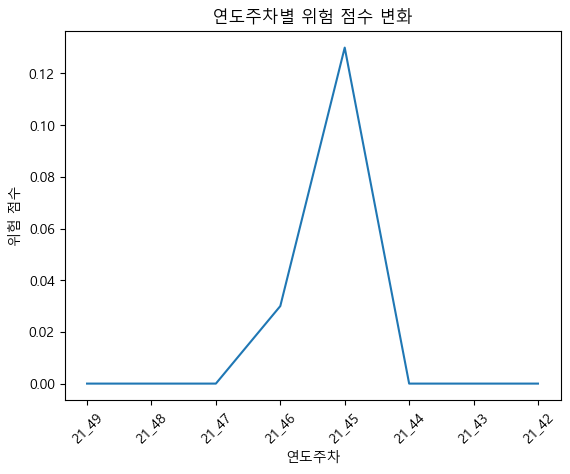

HS Code : 6404199000
21_49주차
0    26.107
1    26.332
2    27.300
3    27.052
4    27.120
5    26.879
6    26.282
7    24.838
8    25.147
9    26.510
10   26.764
11   29.931
12   29.733
13   28.611
14   27.297
15   26.070
16   25.384
17   23.329
18   22.967
19   22.176
20   21.762
21   22.408
22   23.019
23   23.241
24   24.135
25   25.168
26   26.675
27   26.259
28   25.973
29   26.258
30   25.590
31   27.248
32   27.612
33   27.337
34   25.865
35   24.969
36   24.645
37   23.625
38   23.983
39   23.247
40   23.144
41   22.715
42   22.672
43   23.052
44   22.798
45   23.146
46   22.770
47   22.460
48   22.579
49   23.060
50   23.676
51   24.246
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=135.400, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=133.066, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=134.186, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1240.013, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1482.652, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1449.733, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1238.211, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1444.272, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1243.693, Time=0.02 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=1245.008, Time=0.05 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=1441.728, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=1227.337, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=1252.172, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1235.193, Time=0.01 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=1225.101, Time=0.10 sec
 ARIMA(2,0,1)(0,0,0)[0] i

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    457056.707
1    491189.216
2    506323.318
3    520404.531
4    480924.053
5    447449.153
6    430692.927
7    420553.085
8    465878.654
9    515497.552
10   626515.750
11   610039.417
12   646050.059
13   621615.471
14   453071.774
15   451326.013
16   419521.646
17   458434.889
18   513141.071
19   531603.020
20   565620.770
21   567039.904
22   593108.625
23   586081.361
24   580144.762
25   526949.444
26   522894.222
27   532576.828
28   488479.528
29   470996.684
30   445754.218
31   452429.346
32   416223.727
33   439234.867
34   415301.195
35   397445.383
36   406966.966
37   399100.480
38   398622.968
39   383169.667
40   430987.492
41   410569.484
42   496142.057
43   459212.666
44   462817.919
45   522960.336
46   448142.256
47   473476.519
48   452314.845
49   414007.313
50   433659.240
51   456589.722
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    513042.983
1    484768.300
2    463897.216
3    468966.127
4    457056.707
5    491189.216
6    506323.318
7    520404.531
8    480924.053
9    447449.153
10   430692.927
11   420553.085
12   465878.654
13   515497.552
14   626515.750
15   610039.417
16   646050.059
17   621615.471
18   453071.774
19   451326.013
20   419521.646
21   458434.889
22   513141.071
23   531603.020
24   565620.770
25   567039.904
26   593108.625
27   586081.361
28   580144.762
29   526949.444
30   522894.222
31   532576.828
32   488479.528
33   470996.684
34   445754.218
35   452429.346
36   416223.727
37   439234.867
38   415301.195
39   397445.383
40   406966.966
41   399100.480
42   398622.968
43   383169.667
44   430987.492
45   410569.484
46   496142.057
47   459212.666
48   462817.919
49   522960.336
50   448142.256
51   473476.519
Name: 신고중량, dtype: float64
Performing stepwise search 

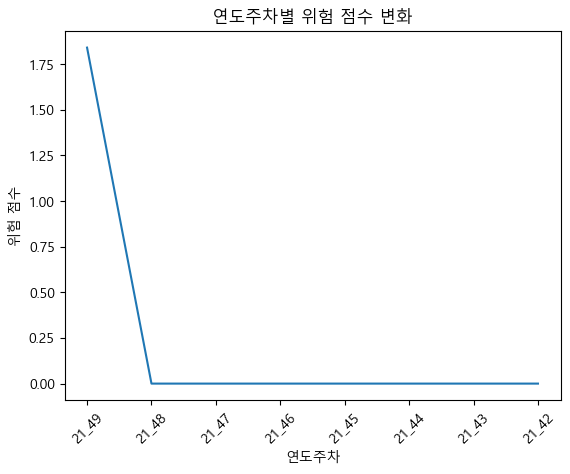

HS Code : 3004909900
21_49주차
0    72.796
1    72.107
2    57.935
3    42.160
4    43.867
5    50.219
6    53.415
7    57.702
8    59.048
9    63.257
10   60.350
11   62.814
12   64.728
13   51.076
14   58.894
15   52.509
16   47.063
17   59.577
18   55.215
19   58.703
20   66.742
21   55.482
22   62.488
23   61.766
24   57.237
25   59.045
26   55.729
27   52.862
28   56.255
29   63.097
30   61.379
31   59.834
32   63.857
33   53.727
34   53.481
35   58.276
36   52.408
37   53.161
38   55.121
39   49.323
40   48.118
41   47.538
42   46.265
43   52.151
44   53.245
45   58.752
46   55.915
47   59.597
48   66.250
49   66.192
50   68.993
51   61.552
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=334.289, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=560.197, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]    

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     970981.863
1     949155.776
2     884812.030
3     927750.900
4    1065655.376
5    1027494.291
6     998972.053
7    1128644.685
8    1067489.233
9     972902.547
10   1012630.833
11   1050135.055
12   1043717.554
13   1190000.295
14   1397844.594
15   1247817.151
16   1270493.676
17   1277965.616
18   1055536.420
19   1051105.706
20   1004817.653
21    900701.415
22   1127843.845
23   1198294.538
24   1249240.160
25   1242657.547
26   1115945.667
27    968106.127
28   1046822.982
29   1095854.790
30   1043910.511
31   1085118.332
32   1122807.477
33   1070099.580
34   1225273.587
35   1276076.698
36   1159680.355
37   1145971.005
38   1138257.570
39   1091298.170
40   1124451.854
41   1138836.319
42   1249408.647
43   1310582.297
44   1230162.957
45   1321952.663
46   1148860.570
47   1117226.300
48   1126124.575
49   1050016.868
50   1013102.833
51   1053043.879
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1034722.555
1     970981.863
2     949155.776
3     884812.030
4     927750.900
5    1065655.376
6    1027494.291
7     998972.053
8    1128644.685
9    1067489.233
10    972902.547
11   1012630.833
12   1050135.055
13   1043717.554
14   1190000.295
15   1397844.594
16   1247817.151
17   1270493.676
18   1277965.616
19   1055536.420
20   1051105.706
21   1004817.653
22    900701.415
23   1127843.845
24   1198294.538
25   1249240.160
26   1242657.547
27   1115945.667
28    968106.127
29   1046822.982
30   1095854.790
31   1043910.511
32   1085118.332
33   1122807.477
34   1070099.580
35   1225273.587
36   1276076.698
37   1159680.355
38   1145971.005
39   1138257.570
40   1091298.170
41   1124451.854
42   1138836.319
43   1249408.647
44   1310582.297
45   1230162.957
46   1321952.663
47   1148860.570
48   1117226.300
49   1126124.575
50   1050016.868
51   1013102.833
Na

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1112807.678
1    1034722.555
2     970981.863
3     949155.776
4     884812.030
5     927750.900
6    1065655.376
7    1027494.291
8     998972.053
9    1128644.685
10   1067489.233
11    972902.547
12   1012630.833
13   1050135.055
14   1043717.554
15   1190000.295
16   1397844.594
17   1247817.151
18   1270493.676
19   1277965.616
20   1055536.420
21   1051105.706
22   1004817.653
23    900701.415
24   1127843.845
25   1198294.538
26   1249240.160
27   1242657.547
28   1115945.667
29    968106.127
30   1046822.982
31   1095854.790
32   1043910.511
33   1085118.332
34   1122807.477
35   1070099.580
36   1225273.587
37   1276076.698
38   1159680.355
39   1145971.005
40   1138257.570
41   1091298.170
42   1124451.854
43   1138836.319
44   1249408.647
45   1310582.297
46   1230162.957
47   1321952.663
48   1148860.570
49   1117226.300
50   1126124.575
51   1050016.868
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1118121.181
1    1211315.580
2    1112807.678
3    1034722.555
4     970981.863
5     949155.776
6     884812.030
7     927750.900
8    1065655.376
9    1027494.291
10    998972.053
11   1128644.685
12   1067489.233
13    972902.547
14   1012630.833
15   1050135.055
16   1043717.554
17   1190000.295
18   1397844.594
19   1247817.151
20   1270493.676
21   1277965.616
22   1055536.420
23   1051105.706
24   1004817.653
25    900701.415
26   1127843.845
27   1198294.538
28   1249240.160
29   1242657.547
30   1115945.667
31    968106.127
32   1046822.982
33   1095854.790
34   1043910.511
35   1085118.332
36   1122807.477
37   1070099.580
38   1225273.587
39   1276076.698
40   1159680.355
41   1145971.005
42   1138257.570
43   1091298.170
44   1124451.854
45   1138836.319
46   1249408.647
47   1310582.297
48   1230162.957
49   1321952.663
50   1148860.570
51   1117226.300
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1142689.137
1    1191096.452
2    1118121.181
3    1211315.580
4    1112807.678
5    1034722.555
6     970981.863
7     949155.776
8     884812.030
9     927750.900
10   1065655.376
11   1027494.291
12    998972.053
13   1128644.685
14   1067489.233
15    972902.547
16   1012630.833
17   1050135.055
18   1043717.554
19   1190000.295
20   1397844.594
21   1247817.151
22   1270493.676
23   1277965.616
24   1055536.420
25   1051105.706
26   1004817.653
27    900701.415
28   1127843.845
29   1198294.538
30   1249240.160
31   1242657.547
32   1115945.667
33    968106.127
34   1046822.982
35   1095854.790
36   1043910.511
37   1085118.332
38   1122807.477
39   1070099.580
40   1225273.587
41   1276076.698
42   1159680.355
43   1145971.005
44   1138257.570
45   1091298.170
46   1124451.854
47   1138836.319
48   1249408.647
49   1310582.297
50   1230162.957
51   1321952.663
Na

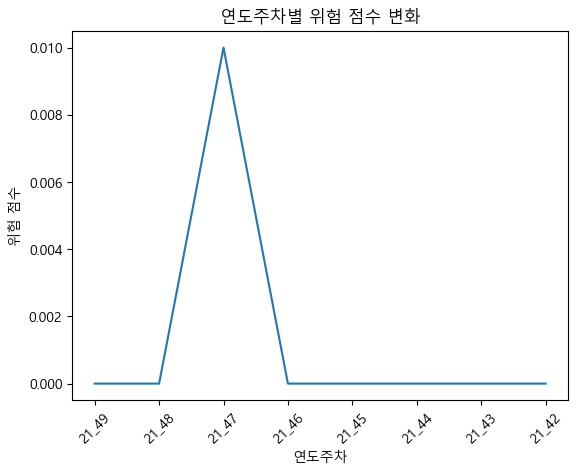

HS Code : 8542311000
21_49주차
0    5897.716
1    5861.924
2    5773.649
3    5821.261
4    5857.884
5    6034.880
6    5998.963
7    6075.663
8    6039.670
9    6257.799
10   5971.406
11   5941.204
12   5860.112
13   5708.886
14   5810.848
15   6049.501
16   7027.921
17   6761.460
18   6853.300
19   7193.001
20   7027.247
21   6992.967
22   7330.021
23   6594.990
24   6515.657
25   7125.140
26   6957.356
27   7681.144
28   7616.440
29   7337.001
30   7427.584
31   6919.421
32   6529.009
33   6529.001
34   6443.433
35   6234.506
36   6100.187
37   5957.534
38   5985.596
39   6074.701
40   6270.972
41   6157.426
42   6278.861
43   6171.803
44   6083.133
45   6015.000
46   5737.255
47   5797.395
48   5904.524
49   6124.873
50   6244.684
51   6384.862
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1040.584, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, T

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1073.707, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=927.270, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=929.258, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=930.405, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=925.829, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.07 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.165 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    5983.774
1    6045.243
2    5897.716
3    5861.924
4    5773.649
5    5821.261
6    5857.884
7    6034.880
8    5998.963
9    6075.663
10   6039.670
11   6257.799
12   5971.406
13   5941.204
14   5860.112
15   5708.886
16   5810.848
17   6049.501
18   7027.921
19   6761.460
20   6853.300
21   7193.001
22   7027.247
23   6992.967
24   7330.021
25   6594.990
26   6515.657
27   7125.140
28   6957.356
29   768

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=730.265, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=732.247, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=731.858, Time=0.06 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=724.536, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=722.671, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=791.989, Time=0.00 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=724.531, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=726.585, Time=0.03 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.445 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecas

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=930.795, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=926.098, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=926.480, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=926.462, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=924.495, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=927.916, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.145 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    6044.906
1    6059.934
2    5994.862
3    6029.047
4    5813.837
5    5983.774
6    6045.243
7    5897.716
8    5861.924
9    5773.649
10   5821.261
11   5857.884
12   6034.880
13   5998.963
14   6075.663
15   6039.670
16   6257.799
17   5971.406
18   5941.204
19   5860.112
20   5708.886
21   5810.848
22   6049.501
23   7027.921
24   6761.460
25   6853.300
26   7193.001
27   7027.247
28   6992.967
29   

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=921.344, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=922.770, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=922.829, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=919.413, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=921.152, Time=0.05 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.214 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


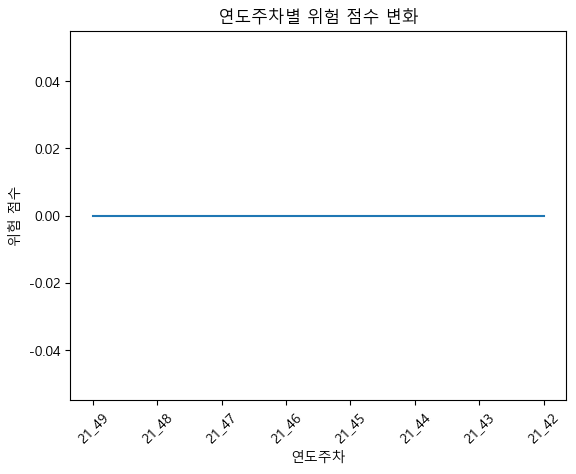

HS Code : 4901999000
21_49주차
0    17.773
1    18.268
2    18.230
3    16.762
4    18.023
5    17.131
6    19.855
7    19.629
8    20.078
9    20.758
10   18.398
11   19.621
12   18.932
13   18.715
14   18.463
15   17.863
16   18.134
17   17.406
18   18.422
19   19.333
20   17.770
21   18.294
22   18.096
23   17.033
24   18.093
25   18.971
26   18.037
27   19.325
28   19.567
29   19.201
30   20.917
31   20.649
32   20.510
33   20.395
34   19.203
35   20.015
36   20.523
37   18.392
38   18.243
39   18.380
40   17.349
41   18.436
42   18.164
43   18.141
44   19.173
45   20.736
46   21.396
47   22.489
48   22.892
49   23.189
50   22.876
51   21.194
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=145.047, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=141.839, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=142.639, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    120910.071
1    156112.714
2    146759.967
3    145173.954
4    162615.894
5    131172.290
6    144767.654
7    145953.964
8    147626.903
9    138382.624
10   131102.591
11   144898.737
12   128096.758
13   146242.413
14   149179.005
15   146818.156
16   146186.027
17   131721.284
18   122242.320
19   103508.030
20    99488.739
21   113927.592
22   118790.850
23   127594.879
24   138000.539
25   125582.861
26   109948.093
27   110078.550
28   112299.863
29   108977.843
30   126470.397
31   122653.449
32   115024.460
33   116001.479
34   117609.965
35   125133.436
36   118852.895
37   123557.456
38   134308.964
39   123579.268
40   117259.097
41   122517.436
42   116375.785
43   114705.423
44   140500.295
45   131214.905
46   110794.927
47   111379.585
48    86175.741
49    83803.100
50    84560.444
51    84297.157
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    107845.811
1    112533.566
2    120910.071
3    156112.714
4    146759.967
5    145173.954
6    162615.894
7    131172.290
8    144767.654
9    145953.964
10   147626.903
11   138382.624
12   131102.591
13   144898.737
14   128096.758
15   146242.413
16   149179.005
17   146818.156
18   146186.027
19   131721.284
20   122242.320
21   103508.030
22    99488.739
23   113927.592
24   118790.850
25   127594.879
26   138000.539
27   125582.861
28   109948.093
29   110078.550
30   112299.863
31   108977.843
32   126470.397
33   122653.449
34   115024.460
35   116001.479
36   117609.965
37   125133.436
38   118852.895
39   123557.456
40   134308.964
41   123579.268
42   117259.097
43   122517.436
44   116375.785
45   114705.423
46   140500.295
47   131214.905
48   110794.927
49   111379.585
50    86175.741
51    83803.100
Name: 신고중량, dtype: float64
Performing stepwise search 

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0    16.987
1    17.510
2    18.844
3    19.644
4    18.724
5    20.178
6    17.773
7    18.268
8    18.230
9    16.762
10   18.023
11   17.131
12   19.855
13   19.629
14   20.078
15   20.758
16   18.398
17   19.621
18   18.932
19   18.715
20   18.463
21   17.863
22   18.134
23   17.406
24   18.422
25   19.333
26   17.770
27   18.294
28   18.096
29   17.033
30   18.093
31   18.971
32   18.037
33   19.325
34   19.567
35   19.201
36   20.917
37   20.649
38   20.510
39   20.395
40   19.203
41   20.015
42   20.523
43   18.392
44   18.243
45   18.380
46   17.349
47   18.436
48   18.164
49   18.141
50   19.173
51   20.736
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=445.910, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    122758.050
1    112135.630
2    106325.159
3    107845.811
4    112533.566
5    120910.071
6    156112.714
7    146759.967
8    145173.954
9    162615.894
10   131172.290
11   144767.654
12   145953.964
13   147626.903
14   138382.624
15   131102.591
16   144898.737
17   128096.758
18   146242.413
19   149179.005
20   146818.156
21   146186.027
22   131721.284
23   122242.320
24   103508.030
25    99488.739
26   113927.592
27   118790.850
28   127594.879
29   138000.539
30   125582.861
31   109948.093
32   110078.550
33   112299.863
34   108977.843
35   126470.397
36   122653.449
37   115024.460
38   116001.479
39   117609.965
40   125133.436
41   118852.895
42   123557.456
43   134308.964
44   123579.268
45   117259.097
46   122517.436
47   116375.785
48   114705.423
49   140500.295
50   131214.905
51   110794.927
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


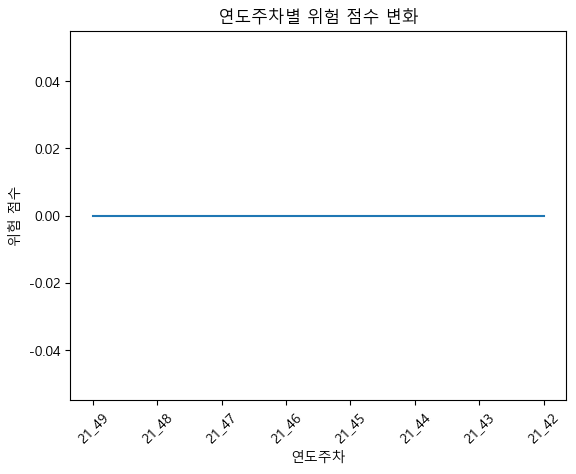

HS Code : 8473309090
21_49주차
0    116.975
1    119.995
2    129.909
3    128.393
4    113.742
5    109.996
6    107.696
7    105.213
8    108.393
9    124.189
10   149.396
11   156.130
12   161.192
13   179.458
14   158.973
15   151.916
16   160.053
17   135.055
18   123.243
19   126.628
20   103.421
21   102.523
22   104.975
23   101.953
24   125.612
25   125.336
26   132.466
27   136.789
28   149.625
29   157.319
30   167.218
31   168.500
32   172.812
33   177.887
34   174.864
35   168.911
36   164.509
37   159.592
38   152.232
39   158.485
40   132.298
41   127.672
42   154.763
43   156.874
44   154.148
45   154.734
46   156.252
47   150.455
48   163.778
49   187.395
50   160.073
51   179.469
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=398.575, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=397.272, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=399.230, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercep

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     91610.984
1     92051.675
2     77842.865
3     86542.998
4    100110.152
5    101947.967
6    117595.562
7    116982.294
8    107676.617
9    101035.314
10    97998.599
11    88765.762
12    92721.788
13    94079.364
14    91236.670
15    91985.670
16   100437.050
17    96740.772
18   103494.308
19   110084.233
20   112279.497
21   125013.417
22   129312.819
23   120107.387
24   117170.698
25   104144.267
26   107118.506
27   105750.325
28    97224.462
29   109545.895
30    89423.803
31    90840.655
32    85641.878
33    76660.066
34    88613.516
35    88669.811
36    94908.269
37    96888.480
38   102080.564
39    97627.307
40    94620.352
41   102444.507
42   102370.516
43   109530.033
44   117315.367
45   116302.247
46   114120.287
47   122478.686
48   117002.318
49   110201.079
50   113660.328
51   114775.596
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    117.026
1    116.975
2    119.995
3    129.909
4    128.393
5    113.742
6    109.996
7    107.696
8    105.213
9    108.393
10   124.189
11   149.396
12   156.130
13   161.192
14   179.458
15   158.973
16   151.916
17   160.053
18   135.055
19   123.243
20   126.628
21   103.421
22   102.523
23   104.975
24   101.953
25   125.612
26   125.336
27   132.466
28   136.789
29   149.625
30   157.319
31   167.218
32   168.500
33   172.812
34   177.887
35   174.864
36   168.911
37   164.509
38   159.592
39   152.232
40   158.485
41   132.298
42   127.672
43   154.763
44   156.874
45   154.148
46   154.734
47   156.252
48   150.455
49   163.778
50   187.395
51   160.073
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=393.202, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=391.671, Time=0.00 sec
 ARI

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0    141.889
1    140.539
2    143.993
3    123.177
4    116.075
5    117.026
6    116.975
7    119.995
8    129.909
9    128.393
10   113.742
11   109.996
12   107.696
13   105.213
14   108.393
15   124.189
16   149.396
17   156.130
18   161.192
19   179.458
20   158.973
21   151.916
22   160.053
23   135.055
24   123.243
25   126.628
26   103.421
27   102.523
28   104.975
29   101.953
30   125.612
31   125.336
32   132.466
33   136.789
34   149.625
35   157.319
36   167.218
37   168.500
38   172.812
39   177.887
40   174.864
41   168.911
42   164.509
43   159.592
44   152.232
45   158.485
46   132.298
47   127.672
48   154.763
49   156.874
50   154.148
51   154.734
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=403.360, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=651.258, Time=0.00 sec
 ARI

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     78045.328
1     79077.487
2     84780.416
3     95244.880
4     96277.207
5     95794.771
6     91610.984
7     92051.675
8     77842.865
9     86542.998
10   100110.152
11   101947.967
12   117595.562
13   116982.294
14   107676.617
15   101035.314
16    97998.599
17    88765.762
18    92721.788
19    94079.364
20    91236.670
21    91985.670
22   100437.050
23    96740.772
24   103494.308
25   110084.233
26   112279.497
27   125013.417
28   129312.819
29   120107.387
30   117170.698
31   104144.267
32   107118.506
33   105750.325
34    97224.462
35   109545.895
36    89423.803
37    90840.655
38    85641.878
39    76660.066
40    88613.516
41    88669.811
42    94908.269
43    96888.480
44   102080.564
45    97627.307
46    94620.352
47   102444.507
48   102370.516
49   109530.033
50   117315.367
51   116302.247
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     82740.746
1     78045.328
2     79077.487
3     84780.416
4     95244.880
5     96277.207
6     95794.771
7     91610.984
8     92051.675
9     77842.865
10    86542.998
11   100110.152
12   101947.967
13   117595.562
14   116982.294
15   107676.617
16   101035.314
17    97998.599
18    88765.762
19    92721.788
20    94079.364
21    91236.670
22    91985.670
23   100437.050
24    96740.772
25   103494.308
26   110084.233
27   112279.497
28   125013.417
29   129312.819
30   120107.387
31   117170.698
32   104144.267
33   107118.506
34   105750.325
35    97224.462
36   109545.895
37    89423.803
38    90840.655
39    85641.878
40    76660.066
41    88613.516
42    88669.811
43    94908.269
44    96888.480
45   102080.564
46    97627.307
47    94620.352
48   102444.507
49   102370.516
50   109530.033
51   117315.367
Name: 신고중량, dtype: float64
Performing stepwise search 

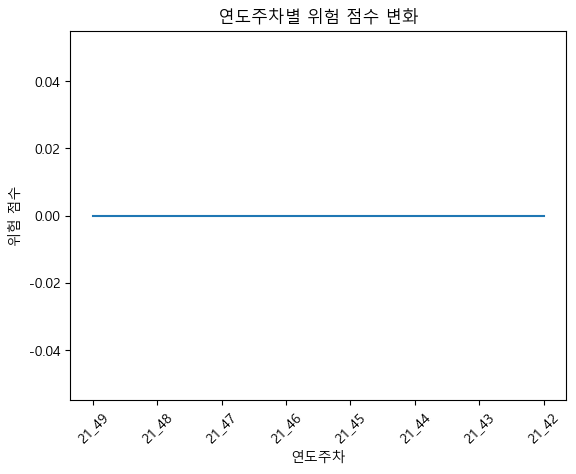

HS Code : 6307909000
21_49주차
0     9.547
1     9.611
2     9.595
3     9.457
4     9.841
5     9.571
6     9.180
7     8.332
8     7.836
9     8.226
10    8.828
11    9.895
12   10.217
13    9.504
14    8.929
15    8.419
16    8.443
17    8.362
18    8.549
19    8.373
20    8.222
21    8.435
22    8.692
23    8.929
24    8.953
25    9.085
26    8.744
27    8.699
28    8.699
29    8.687
30    8.444
31    8.566
32    8.676
33    8.561
34    8.888
35    9.112
36    9.393
37    9.190
38    9.037
39    8.809
40    8.703
41    8.859
42    9.323
43    9.419
44    8.898
45    9.191
46    9.045
47    8.942
48    9.002
49    8.622
50    8.304
51    8.290
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=37.100, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=370.073, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]     

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0     9.343
1     9.547
2     9.611
3     9.595
4     9.457
5     9.841
6     9.571
7     9.180
8     8.332
9     7.836
10    8.226
11    8.828
12    9.895
13   10.217
14    9.504
15    8.929
16    8.419
17    8.443
18    8.362
19    8.549
20    8.373
21    8.222
22    8.435
23    8.692
24    8.929
25    8.953
26    9.085
27    8.744
28    8.699
29    8.699
30    8.687
31    8.444
32    8.566
33    8.676
34    8.561
35    8.888
36    9.112
37    9.393
38    9.190
39    9.037
40    8.809
41    8.703
42    8.859
43    9.323
44    9.419
45    8.898
46    9.191
47    9.045
48    8.942
49    9.002
50    8.622
51    8.304
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=36.531, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=370.302, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    926480.144
1    900164.355
2    855200.547
3    860998.015
4    834873.097
5    807575.211
6    835761.196
7    827035.271
8    833551.007
9    757710.825
10   636615.410
11   526757.970
12   412525.561
13   418786.510
14   463819.705
15   550360.442
16   642785.004
17   686437.830
18   743660.789
19   738486.643
20   757444.456
21   773526.171
22   715247.841
23   713885.225
24   723029.542
25   732956.413
26   741670.551
27   726380.746
28   700386.878
29   667879.781
30   686270.619
31   701378.728
32   658479.693
33   646674.623
34   633453.625
35   643856.038
36   632335.006
37   627332.719
38   637452.332
39   603954.242
40   626212.656
41   589607.893
42   613309.255
43   600403.613
44   610250.728
45   701341.977
46   665559.071
47   699592.725
48   703276.673
49   724126.880
50   717603.245
51   727904.306
Name: 신고중량, dtype: float64
Performing stepwise search 

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    881649.785
1    879578.011
2    891283.425
3    919736.343
4    935148.927
5    926480.144
6    900164.355
7    855200.547
8    860998.015
9    834873.097
10   807575.211
11   835761.196
12   827035.271
13   833551.007
14   757710.825
15   636615.410
16   526757.970
17   412525.561
18   418786.510
19   463819.705
20   550360.442
21   642785.004
22   686437.830
23   743660.789
24   738486.643
25   757444.456
26   773526.171
27   715247.841
28   713885.225
29   723029.542
30   732956.413
31   741670.551
32   726380.746
33   700386.878
34   667879.781
35   686270.619
36   701378.728
37   658479.693
38   646674.623
39   633453.625
40   643856.038
41   632335.006
42   627332.719
43   637452.332
44   603954.242
45   626212.656
46   589607.893
47   613309.255
48   600403.613
49   610250.728
50   701341.977
51   665559.071
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=35.258, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=370.608, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=34.074, Time=0.10 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=37.889, Time=0.04 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=38.681, Time=0.05 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.16 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec

Best model:  ARIMA(1,0,2)(0,0,0)[0]          
Total fit time: 0.895 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    909354.356
1    881649.785
2    879578.011
3    891283.4

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1209.913, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1215.650, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1212.207, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1208.938, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1215.512, Time=0.05 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.234 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============


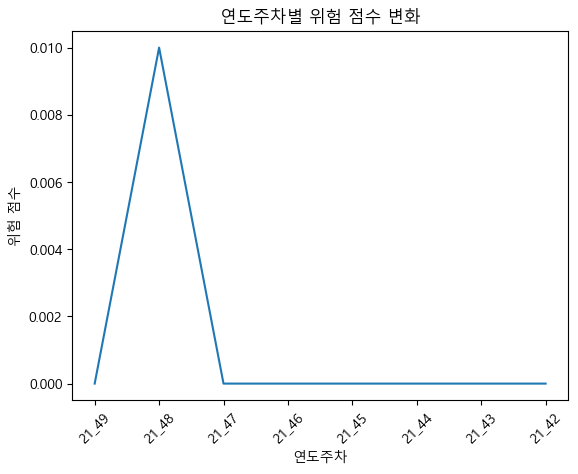

HS Code : 4202211090
21_49주차
0    532.888
1    562.267
2    559.074
3    594.320
4    562.698
5    511.775
6    480.364
7    407.497
8    387.076
9    408.303
10   444.226
11   579.200
12   632.317
13   633.766
14   611.083
15   576.630
16   585.641
17   551.504
18   538.231
19   499.418
20   518.520
21   518.526
22   526.152
23   551.234
24   539.571
25   517.689
26   548.410
27   547.065
28   539.563
29   581.856
30   534.638
31   545.491
32   552.816
33   550.585
34   564.913
35   515.215
36   510.957
37   472.780
38   430.172
39   404.045
40   391.638
41   369.524
42   417.996
43   532.298
44   504.559
45   555.486
46   505.680
47   463.503
48   491.484
49   514.371
50   518.964
51   510.120
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=784.873, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AI

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    557.400
1    532.888
2    562.267
3    559.074
4    594.320
5    562.698
6    511.775
7    480.364
8    407.497
9    387.076
10   408.303
11   444.226
12   579.200
13   632.317
14   633.766
15   611.083
16   576.630
17   585.641
18   551.504
19   538.231
20   499.418
21   518.520
22   518.526
23   526.152
24   551.234
25   539.571
26   517.689
27   548.410
28   547.065
29   539.563
30   581.856
31   534.638
32   545.491
33   552.816
34   550.585
35   564.913
36   515.215
37   510.957
38   472.780
39   430.172
40   404.045
41   391.638
42   369.524
43   417.996
44   532.298
45   504.559
46   555.486
47   505.680
48   463.503
49   491.484
50   514.371
51   518.964
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=785.025, Time=0.00 sec
 ARIMA(1

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    51930.337
1    52263.671
2    47838.790
3    43435.399
4    44503.772
5    42555.229
6    49707.213
7    56121.919
8    68872.104
9    71236.824
10   66766.088
11   64530.305
12   49156.903
13   48663.179
14   48036.599
15   50878.901
16   53759.516
17   51964.728
18   55250.921
19   54807.624
20   60789.986
21   62347.020
22   64190.178
23   61902.435
24   57922.386
25   57161.986
26   58930.013
27   57014.098
28   56651.065
29   57567.049
30   54416.429
31   59474.312
32   56963.876
33   55882.202
34   52134.267
35   51819.952
36   55624.114
37   55300.264
38   57703.269
39   59241.577
40   64137.902
41   61144.544
42   67722.705
43   60762.855
44   50604.607
45   59065.515
46   56297.069
47   64801.019
48   67281.234
49   65701.979
50   63666.548
51   59248.963
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0    451.814
1    462.233
2    582.466
3    584.050
4    599.078
5    557.400
6    532.888
7    562.267
8    559.074
9    594.320
10   562.698
11   511.775
12   480.364
13   407.497
14   387.076
15   408.303
16   444.226
17   579.200
18   632.317
19   633.766
20   611.083
21   576.630
22   585.641
23   551.504
24   538.231
25   499.418
26   518.520
27   518.526
28   526.152
29   551.234
30   539.571
31   517.689
32   548.410
33   547.065
34   539.563
35   581.856
36   534.638
37   545.491
38   552.816
39   550.585
40   564.913
41   515.215
42   510.957
43   472.780
44   430.172
45   404.045
46   391.638
47   369.524
48   417.996
49   532.298
50   504.559
51   555.486
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=534.149, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=785.651, Time=0.00 sec
 ARI

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    64867.994
1    62718.793
2    58603.191
3    49528.982
4    50706.137
5    51482.715
6    51930.337
7    52263.671
8    47838.790
9    43435.399
10   44503.772
11   42555.229
12   49707.213
13   56121.919
14   68872.104
15   71236.824
16   66766.088
17   64530.305
18   49156.903
19   48663.179
20   48036.599
21   50878.901
22   53759.516
23   51964.728
24   55250.921
25   54807.624
26   60789.986
27   62347.020
28   64190.178
29   61902.435
30   57922.386
31   57161.986
32   58930.013
33   57014.098
34   56651.065
35   57567.049
36   54416.429
37   59474.312
38   56963.876
39   55882.202
40   52134.267
41   51819.952
42   55624.114
43   55300.264
44   57703.269
45   59241.577
46   64137.902
47   61144.544
48   67722.705
49   60762.855
50   50604.607
51   59065.515
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


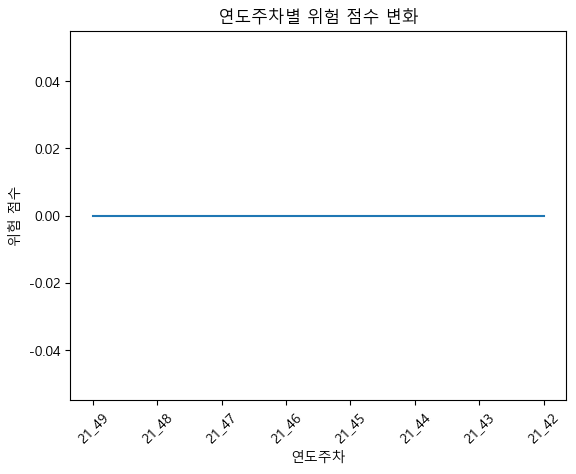

HS Code : 8536509090
21_49주차
0    85.099
1    82.137
2    78.638
3    69.344
4    72.158
5    71.439
6    69.392
7    71.418
8    72.657
9    76.307
10   85.275
11   93.516
12   91.223
13   94.811
14   90.528
15   93.330
16   84.828
17   79.927
18   76.219
19   72.972
20   76.040
21   80.754
22   97.287
23   96.739
24   97.849
25   95.330
26   84.542
27   81.667
28   83.073
29   81.083
30   79.433
31   82.349
32   80.432
33   79.090
34   79.353
35   77.382
36   69.909
37   72.651
38   73.838
39   75.369
40   80.473
41   80.186
42   84.189
43   83.043
44   86.676
45   97.034
46   91.014
47   98.956
48   98.024
49   87.348
50   84.222
51   81.281
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=324.438, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=597.833, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]    

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    84.183
1    85.099
2    82.137
3    78.638
4    69.344
5    72.158
6    71.439
7    69.392
8    71.418
9    72.657
10   76.307
11   85.275
12   93.516
13   91.223
14   94.811
15   90.528
16   93.330
17   84.828
18   79.927
19   76.219
20   72.972
21   76.040
22   80.754
23   97.287
24   96.739
25   97.849
26   95.330
27   84.542
28   81.667
29   83.073
30   81.083
31   79.433
32   82.349
33   80.432
34   79.090
35   79.353
36   77.382
37   69.909
38   72.651
39   73.838
40   75.369
41   80.473
42   80.186
43   84.189
44   83.043
45   86.676
46   97.034
47   91.014
48   98.956
49   98.024
50   87.348
51   84.222
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=324.591, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=597.832, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    79.533
1    84.183
2    85.099
3    82.137
4    78.638
5    69.344
6    72.158
7    71.439
8    69.392
9    71.418
10   72.657
11   76.307
12   85.275
13   93.516
14   91.223
15   94.811
16   90.528
17   93.330
18   84.828
19   79.927
20   76.219
21   72.972
22   76.040
23   80.754
24   97.287
25   96.739
26   97.849
27   95.330
28   84.542
29   81.667
30   83.073
31   81.083
32   79.433
33   82.349
34   80.432
35   79.090
36   79.353
37   77.382
38   69.909
39   72.651
40   73.838
41   75.369
42   80.473
43   80.186
44   84.189
45   83.043
46   86.676
47   97.034
48   91.014
49   98.956
50   98.024
51   87.348
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=323.876, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=597.644, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    55591.327
1    57472.110
2    63046.169
3    62675.256
4    62214.295
5    61082.831
6    60246.861
7    59881.584
8    55862.932
9    57719.618
10   57651.495
11   62709.417
12   73432.723
13   76198.813
14   69825.888
15   61976.343
16   53589.749
17   46231.214
18   52058.659
19   53888.197
20   55729.191
21   58278.385
22   60851.425
23   63938.195
24   68966.169
25   71665.670
26   68629.845
27   66029.588
28   64549.445
29   64838.267
30   69843.178
31   73062.585
32   72054.022
33   73131.471
34   68791.433
35   70023.747
36   72755.953
37   68491.653
38   69480.282
39   66202.060
40   64791.815
41   68134.273
42   71643.812
43   70910.772
44   67100.735
45   68808.384
46   59183.688
47   63215.745
48   59622.653
49   54587.757
50   57278.682
51   52906.475
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    77.811
1    78.764
2    76.537
3    74.849
4    76.452
5    79.533
6    84.183
7    85.099
8    82.137
9    78.638
10   69.344
11   72.158
12   71.439
13   69.392
14   71.418
15   72.657
16   76.307
17   85.275
18   93.516
19   91.223
20   94.811
21   90.528
22   93.330
23   84.828
24   79.927
25   76.219
26   72.972
27   76.040
28   80.754
29   97.287
30   96.739
31   97.849
32   95.330
33   84.542
34   81.667
35   83.073
36   81.083
37   79.433
38   82.349
39   80.432
40   79.090
41   79.353
42   77.382
43   69.909
44   72.651
45   73.838
46   75.369
47   80.473
48   80.186
49   84.189
50   83.043
51   86.676
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=310.908, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=595.420, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


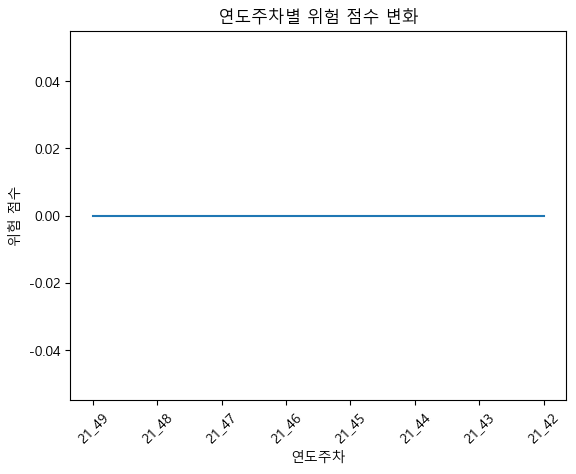

HS Code : 8538909000
21_49주차
0    44.517
1    44.468
2    45.969
3    41.606
4    41.303
5    41.855
6    44.280
7    44.402
8    47.252
9    47.261
10   47.157
11   47.639
12   46.980
13   46.245
14   44.880
15   46.484
16   46.653
17   45.336
18   44.233
19   45.809
20   44.076
21   46.153
22   48.046
23   45.465
24   48.912
25   48.933
26   48.667
27   48.262
28   47.099
29   47.629
30   47.328
31   49.162
32   45.950
33   45.796
34   44.813
35   43.603
36   45.402
37   45.389
38   46.317
39   44.513
40   43.664
41   41.954
42   41.529
43   43.033
44   43.300
45   43.901
46   47.470
47   48.566
48   50.086
49   48.073
50   43.266
51   43.083
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=536.700, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]        

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1083.325, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1084.588, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1355.458, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1071.127, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1082.124, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1069.169, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1099.995, Time=0.00 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1071.135, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1073.173, Time=0.05 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.407 seconds


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    48.729
1    44.517
2    44.468
3    45.969
4    41.606
5    41.303
6    41.855
7    44.280
8    44.402
9    47.252
10   47.261
11   47.157
12   47.639
13   46.980
14   46.245
15   44.880
16   46.484
17   46.653
18   45.336
19   44.233
20   45.809
21   44.076
22   46.153
23   48.046
24   45.465
25   48.912
26   48.933
27   48.667
28   48.262
29   47.099
30   47.629
31   47.328
32   49.162
33   45.950
34   45.796
35   44.813
36   43.603
37   45.402
38   45.389
39   46.317
40   44.513
41   43.664
42   41.954
43   41.529
44   43.033
45   43.300
46   43.901
47   47.470
48   48.566
49   50.086
50   48.073
51   43.266
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=536.940, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_44주차
0    50.105
1    50.038
2    52.198
3    46.877
4    48.729
5    44.517
6    44.468
7    45.969
8    41.606
9    41.303
10   41.855
11   44.280
12   44.402
13   47.252
14   47.261
15   47.157
16   47.639
17   46.980
18   46.245
19   44.880
20   46.484
21   46.653
22   45.336
23   44.233
24   45.809
25   44.076
26   46.153
27   48.046
28   45.465
29   48.912
30   48.933
31   48.667
32   48.262
33   47.099
34   47.629
35   47.328
36   49.162
37   45.950
38   45.796
39   44.813
40   43.603
41   45.402
42   45.389
43   46.317
44   44.513
45   43.664
46   41.954
47   41.529
48   43.033
49   43.300
50   43.901
51   47.470
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=214.251, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=537.179, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    193530.264
1    197608.454
2    186938.005
3    192899.825
4    196392.304
5    199761.115
6    199441.904
7    187885.608
8    194462.358
9    191117.803
10   200038.034
11   208605.636
12   216470.493
13   197672.697
14   188647.886
15   182415.817
16   181936.029
17   198798.902
18   210688.322
19   222716.960
20   224866.703
21   221231.820
22   226015.939
23   229038.843
24   218696.898
25   224361.777
26   208650.944
27   205020.536
28   205948.316
29   198469.953
30   208272.869
31   207890.690
32   207299.203
33   211281.924
34   211696.081
35   204108.060
36   200466.252
37   199819.663
38   187307.524
39   197126.450
40   198674.106
41   195437.835
42   197533.574
43   195054.206
44   203356.068
45   191907.244
46   210783.458
47   205122.084
48   197882.973
49   217859.742
50   206634.222
51   204718.757
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


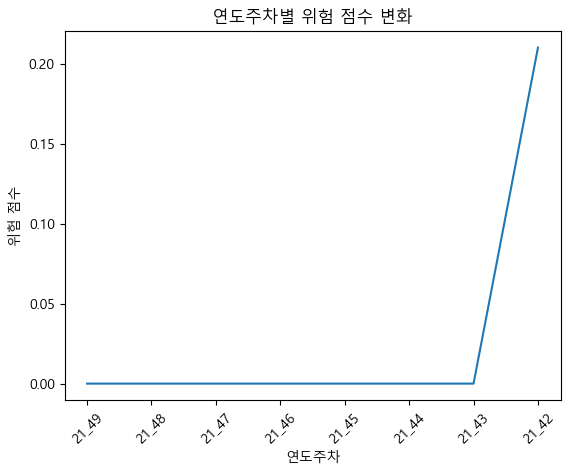

HS Code : 8479909090
21_49주차
0     64.157
1     62.357
2     61.663
3     61.273
4     55.378
5     59.379
6     49.154
7     49.234
8     48.910
9     49.231
10    65.946
11    72.278
12    86.389
13   117.158
14   132.569
15    99.392
16    81.133
17    53.975
18    44.030
19    44.517
20    33.962
21    37.538
22    41.488
23    42.419
24    68.942
25    64.212
26    68.428
27    73.599
28    76.181
29    85.475
30    84.109
31    87.860
32    86.586
33    79.431
34    71.496
35    62.311
36    45.071
37    45.827
38    44.331
39    43.439
40    52.496
41    51.583
42    52.871
43    60.567
44    61.039
45    49.894
46    57.751
47    60.865
48    57.898
49    67.700
50    66.052
51    53.840
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=396.784, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=574.639, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=396.948, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]         

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    112048.781
1    126766.957
2    125416.917
3    105350.832
4    100439.274
5    103018.610
6    151530.944
7    163666.752
8    160897.102
9    143558.380
10    93901.027
11    84863.768
12    82797.873
13    79444.750
14    75683.794
15   108633.485
16   128945.313
17   143757.616
18   154953.597
19   142790.867
20   203356.607
21   191812.873
22   204169.511
23   189986.617
24   115756.440
25   121356.489
26   102231.066
27   112846.854
28   114433.980
29   115168.452
30   119993.733
31   104367.571
32    96017.003
33    91278.054
34   102875.546
35   111890.800
36   155777.930
37   171014.271
38   181960.435
39   205102.444
40   163973.476
41   151471.874
42   136612.686
43   107335.853
44   105219.171
45   128521.757
46   123912.799
47   124247.103
48   133855.954
49   114923.410
50   107620.129
51   150180.005
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0     64.570
1     64.157
2     62.357
3     61.663
4     61.273
5     55.378
6     59.379
7     49.154
8     49.234
9     48.910
10    49.231
11    65.946
12    72.278
13    86.389
14   117.158
15   132.569
16    99.392
17    81.133
18    53.975
19    44.030
20    44.517
21    33.962
22    37.538
23    41.488
24    42.419
25    68.942
26    64.212
27    68.428
28    73.599
29    76.181
30    85.475
31    84.109
32    87.860
33    86.586
34    79.431
35    71.496
36    62.311
37    45.071
38    45.827
39    44.331
40    43.439
41    52.496
42    51.583
43    52.871
44    60.567
45    61.039
46    49.894
47    57.751
48    60.865
49    57.898
50    67.700
51    66.052
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=396.752, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=574.595, Time=0.00 sec
 ARI

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     97204.329
1    112048.781
2    126766.957
3    125416.917
4    105350.832
5    100439.274
6    103018.610
7    151530.944
8    163666.752
9    160897.102
10   143558.380
11    93901.027
12    84863.768
13    82797.873
14    79444.750
15    75683.794
16   108633.485
17   128945.313
18   143757.616
19   154953.597
20   142790.867
21   203356.607
22   191812.873
23   204169.511
24   189986.617
25   115756.440
26   121356.489
27   102231.066
28   112846.854
29   114433.980
30   115168.452
31   119993.733
32   104367.571
33    96017.003
34    91278.054
35   102875.546
36   111890.800
37   155777.930
38   171014.271
39   181960.435
40   205102.444
41   163973.476
42   151471.874
43   136612.686
44   107335.853
45   105219.171
46   128521.757
47   123912.799
48   124247.103
49   133855.954
50   114923.410
51   107620.129
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0     61.727
1     61.647
2     64.570
3     64.157
4     62.357
5     61.663
6     61.273
7     55.378
8     59.379
9     49.154
10    49.234
11    48.910
12    49.231
13    65.946
14    72.278
15    86.389
16   117.158
17   132.569
18    99.392
19    81.133
20    53.975
21    44.030
22    44.517
23    33.962
24    37.538
25    41.488
26    42.419
27    68.942
28    64.212
29    68.428
30    73.599
31    76.181
32    85.475
33    84.109
34    87.860
35    86.586
36    79.431
37    71.496
38    62.311
39    45.071
40    45.827
41    44.331
42    43.439
43    52.496
44    51.583
45    52.871
46    60.567
47    61.039
48    49.894
49    57.751
50    60.865
51    57.898
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=395.449, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=574.521, Time=0.00 sec
 ARI

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0     50.673
1     50.361
2     48.105
3     59.596
4     61.727
5     61.647
6     64.570
7     64.157
8     62.357
9     61.663
10    61.273
11    55.378
12    59.379
13    49.154
14    49.234
15    48.910
16    49.231
17    65.946
18    72.278
19    86.389
20   117.158
21   132.569
22    99.392
23    81.133
24    53.975
25    44.030
26    44.517
27    33.962
28    37.538
29    41.488
30    42.419
31    68.942
32    64.212
33    68.428
34    73.599
35    76.181
36    85.475
37    84.109
38    87.860
39    86.586
40    79.431
41    71.496
42    62.311
43    45.071
44    45.827
45    44.331
46    43.439
47    52.496
48    51.583
49    52.871
50    60.567
51    61.039
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=393.979, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=573.999, Time=0.00 sec
 ARI

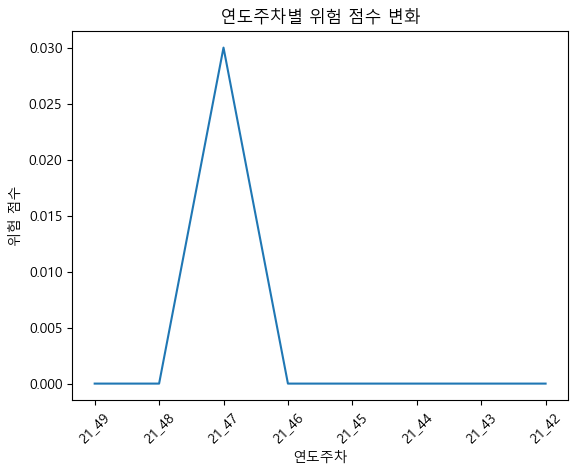

HS Code : 8504409099
21_49주차
0    57.371
1    55.380
2    56.259
3    49.127
4    46.403
5    47.287
6    50.613
7    55.072
8    58.554
9    62.636
10   57.057
11   61.944
12   65.624
13   65.674
14   65.911
15   62.710
16   61.841
17   59.745
18   58.933
19   56.677
20   57.154
21   54.684
22   55.870
23   58.598
24   55.352
25   59.309
26   59.674
27   62.783
28   64.598
29   63.587
30   65.332
31   62.849
32   60.227
33   64.155
34   60.945
35   60.127
36   59.616
37   58.937
38   57.624
39   56.870
40   59.037
41   56.394
42   61.257
43   60.718
44   58.303
45   59.012
46   54.035
47   57.603
48   62.106
49   61.445
50   67.145
51   64.038
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=562.973, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]        

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    57.917
1    57.371
2    55.380
3    56.259
4    49.127
5    46.403
6    47.287
7    50.613
8    55.072
9    58.554
10   62.636
11   57.057
12   61.944
13   65.624
14   65.674
15   65.911
16   62.710
17   61.841
18   59.745
19   58.933
20   56.677
21   57.154
22   54.684
23   55.870
24   58.598
25   55.352
26   59.309
27   59.674
28   62.783
29   64.598
30   63.587
31   65.332
32   62.849
33   60.227
34   64.155
35   60.945
36   60.127
37   59.616
38   58.937
39   57.624
40   56.870
41   59.037
42   56.394
43   61.257
44   60.718
45   58.303
46   59.012
47   54.035
48   57.603
49   62.106
50   61.445
51   67.145
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=264.880, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=562.643, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1354.102, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1119.934, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1115.783, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1118.954, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1117.424, Time=0.05 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1107.217, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1109.030, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1108.603, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=1109.198, Time=0.06 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=1110.058, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1108.626, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=1110.543, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0] i

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1387.995, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1354.196, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1123.586, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1120.119, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1121.233, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1124.867, Time=0.04 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1111.671, Time=0.07 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1113.892, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1113.644, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=1113.385, Time=0.08 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_44주차
0    51.136
1    53.253
2    52.701
3    53.378
4    57.917
5    57.371
6    55.380
7    56.259
8    49.127
9    46.403
10   47.287
11   50.613
12   55.072
13   58.554
14   62.636
15   57.057
16   61.944
17   65.624
18   65.674
19   65.911
20   62.710
21   61.841
22   59.745
23   58.933
24   56.677
25   57.154
26   54.684
27   55.870
28   58.598
29   55.352
30   59.309
31   59.674
32   62.783
33   64.598
34   63.587
35   65.332
36   62.849
37   60.227
38   64.155
39   60.945
40   60.127
41   59.616
42   58.937
43   57.624
44   56.870
45   59.037
46   56.394
47   61.257
48   60.718
49   58.303
50   59.012
51   54.035
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=260.796, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=561.834, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


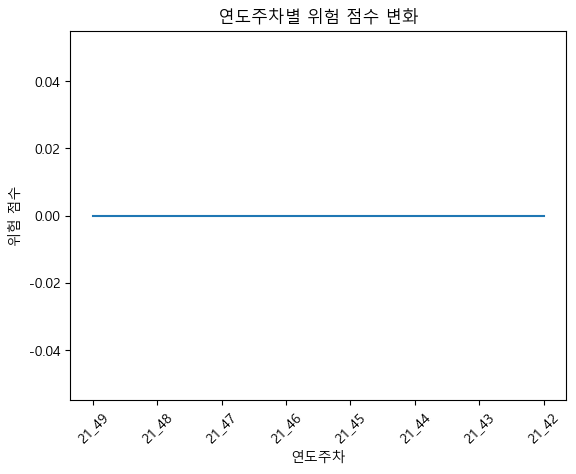

HS Code : 6110909000
21_49주차
0    230.083
1    223.795
2    221.519
3    220.911
4    215.150
5    213.682
6    201.197
7    190.919
8    187.096
9    203.584
10   209.001
11   212.172
12   222.675
13   205.204
14   205.717
15   205.161
16   203.507
17   161.331
18   135.862
19   127.686
20   128.000
21   146.982
22   192.656
23   232.298
24   238.980
25   269.959
26   273.808
27   279.394
28   266.955
29   258.400
30   263.276
31   249.477
32   243.947
33   230.844
34   207.815
35   216.129
36   196.998
37   176.285
38   159.754
39   130.254
40   126.816
41   128.006
42   120.542
43   131.173
44   151.910
45   159.887
46   171.356
47   179.326
48   173.626
49   179.574
50   198.118
51   213.035
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=428.182, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=688.297, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     8329.869
1     8464.396
2     7257.489
3     6288.368
4     6835.757
5     6779.111
6     8079.757
7     9089.175
8     8405.817
9     8296.678
10    8070.520
11    7537.493
12    7741.536
13    7979.335
14    7746.431
15    7554.070
16    7020.086
17    9755.739
18   11137.030
19   11854.092
20   11780.782
21    8407.641
22    6203.400
23    5058.238
24    4930.196
25    4734.483
26    4628.604
27    4246.866
28    4461.281
29    4800.432
30    4891.676
31    5535.059
32    5788.977
33    5688.744
34    6603.052
35    6293.580
36    6797.350
37    8019.029
38    9139.782
39   11714.179
40   12470.156
41   12586.524
42   12535.442
43   11383.473
44   10599.771
45   10235.388
46    9636.431
47    9440.897
48    9779.190
49    9376.521
50    8755.875
51    8156.627
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     8819.989
1     8906.381
2     8329.869
3     8464.396
4     7257.489
5     6288.368
6     6835.757
7     6779.111
8     8079.757
9     9089.175
10    8405.817
11    8296.678
12    8070.520
13    7537.493
14    7741.536
15    7979.335
16    7746.431
17    7554.070
18    7020.086
19    9755.739
20   11137.030
21   11854.092
22   11780.782
23    8407.641
24    6203.400
25    5058.238
26    4930.196
27    4734.483
28    4628.604
29    4246.866
30    4461.281
31    4800.432
32    4891.676
33    5535.059
34    5788.977
35    5688.744
36    6603.052
37    6293.580
38    6797.350
39    8019.029
40    9139.782
41   11714.179
42   12470.156
43   12586.524
44   12535.442
45   11383.473
46   10599.771
47   10235.388
48    9636.431
49    9440.897
50    9779.190
51    9376.521
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     9821.943
1     9779.158
2     9208.502
3     8819.989
4     8906.381
5     8329.869
6     8464.396
7     7257.489
8     6288.368
9     6835.757
10    6779.111
11    8079.757
12    9089.175
13    8405.817
14    8296.678
15    8070.520
16    7537.493
17    7741.536
18    7979.335
19    7746.431
20    7554.070
21    7020.086
22    9755.739
23   11137.030
24   11854.092
25   11780.782
26    8407.641
27    6203.400
28    5058.238
29    4930.196
30    4734.483
31    4628.604
32    4246.866
33    4461.281
34    4800.432
35    4891.676
36    5535.059
37    5788.977
38    5688.744
39    6603.052
40    6293.580
41    6797.350
42    8019.029
43    9139.782
44   11714.179
45   12470.156
46   12586.524
47   12535.442
48   11383.473
49   10599.771
50   10235.388
51    9636.431
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    11630.011
1     9821.943
2     9779.158
3     9208.502
4     8819.989
5     8906.381
6     8329.869
7     8464.396
8     7257.489
9     6288.368
10    6835.757
11    6779.111
12    8079.757
13    9089.175
14    8405.817
15    8296.678
16    8070.520
17    7537.493
18    7741.536
19    7979.335
20    7746.431
21    7554.070
22    7020.086
23    9755.739
24   11137.030
25   11854.092
26   11780.782
27    8407.641
28    6203.400
29    5058.238
30    4930.196
31    4734.483
32    4628.604
33    4246.866
34    4461.281
35    4800.432
36    4891.676
37    5535.059
38    5788.977
39    5688.744
40    6603.052
41    6293.580
42    6797.350
43    8019.029
44    9139.782
45   11714.179
46   12470.156
47   12586.524
48   12535.442
49   11383.473
50   10599.771
51   10235.388
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    160.796
1    156.777
2    177.908
3    177.594
4    185.866
5    209.917
6    223.613
7    230.083
8    223.795
9    221.519
10   220.911
11   215.150
12   213.682
13   201.197
14   190.919
15   187.096
16   203.584
17   209.001
18   212.172
19   222.675
20   205.204
21   205.717
22   205.161
23   203.507
24   161.331
25   135.862
26   127.686
27   128.000
28   146.982
29   192.656
30   232.298
31   238.980
32   269.959
33   273.808
34   279.394
35   266.955
36   258.400
37   263.276
38   249.477
39   243.947
40   230.844
41   207.815
42   216.129
43   196.998
44   176.285
45   159.754
46   130.254
47   126.816
48   128.006
49   120.542
50   131.173
51   151.910
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=429.111, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=689.036, Time=0.00 sec
 ARI

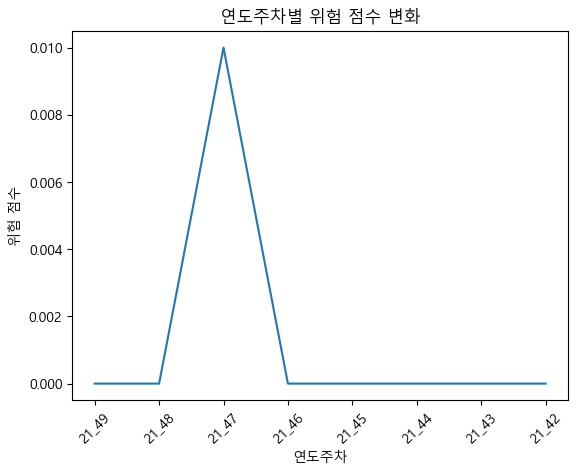

HS Code : 3923100000
21_49주차
0    3.784
1    3.863
2    3.893
3    4.086
4    4.202
5    4.231
6    4.255
7    3.998
8    4.134
9    3.977
10   3.924
11   3.838
12   3.621
13   3.564
14   3.571
15   3.623
16   3.708
17   3.721
18   3.709
19   3.758
20   3.701
21   3.777
22   3.768
23   3.754
24   3.745
25   3.721
26   3.823
27   3.787
28   3.772
29   3.759
30   3.672
31   3.765
32   3.852
33   3.944
34   4.054
35   4.054
36   4.080
37   4.045
38   3.977
39   4.052
40   4.139
41   4.122
42   4.391
43   4.294
44   4.338
45   4.386
46   4.264
47   4.131
48   3.954
49   3.873
50   3.781
51   3.895
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=286.393, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-77.813, Time=0.04 sec
 ARIMA(2,0,1)(0,0,

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    2791933.444
1    2849619.334
2    2760055.509
3    2747754.836
4    2656156.484
5    2646868.933
6    2671309.609
7    2683346.298
8    2764500.299
9    2772380.321
10   2513009.629
11   2562331.680
12   2640499.349
13   2539079.478
14   2771224.359
15   2820960.400
16   2744185.470
17   2827318.585
18   2782199.998
19   2740199.480
20   2718235.256
21   2716759.946
22   2716977.223
23   2643542.802
24   2694008.953
25   2668632.471
26   2792509.116
27   2892573.942
28   2788654.483
29   2749768.365
30   2680352.248
31   2664357.786
32   2750525.043
33   2810178.279
34   2734749.803
35   2621414.039
36   2606494.357
37   2530923.871
38   2586072.799
39   2733623.846
40   2772844.732
41   2694135.490
42   2520020.841
43   2514992.634
44   2410200.205
45   2452681.530
46   2461986.009
47   2472739.614
48   2536284.745
49   2666145.525
50   2823337.816
51   2758204.996
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    2839079.590
1    2796697.421
2    2791933.444
3    2849619.334
4    2760055.509
5    2747754.836
6    2656156.484
7    2646868.933
8    2671309.609
9    2683346.298
10   2764500.299
11   2772380.321
12   2513009.629
13   2562331.680
14   2640499.349
15   2539079.478
16   2771224.359
17   2820960.400
18   2744185.470
19   2827318.585
20   2782199.998
21   2740199.480
22   2718235.256
23   2716759.946
24   2716977.223
25   2643542.802
26   2694008.953
27   2668632.471
28   2792509.116
29   2892573.942
30   2788654.483
31   2749768.365
32   2680352.248
33   2664357.786
34   2750525.043
35   2810178.279
36   2734749.803
37   2621414.039
38   2606494.357
39   2530923.871
40   2586072.799
41   2733623.846
42   2772844.732
43   2694135.490
44   2520020.841
45   2514992.634
46   2410200.205
47   2452681.530
48   2461986.009
49   2472739.614
50   2536284.745
51   2666145.525
Na

...

 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1278.858, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1279.878, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1281.318, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1281.381, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1278.145, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1283.133, Time=0.04 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.213 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0    3.625
1    3.597
2    3.675
3    3.724
4    3.678
5    3.835
6    3.784
7    3.863
8    3.893
9    4.086
10   4.202
11   4.231
12   4.255
13   3.998
14   4.134
15   3.977
16   3.924
17   3.838
18   3.621
19   3.564
20   3.571
21   3.623
22   3.708
23   3.721
24   3.709
25   3.758
26   3.701
27   3.777
28   3.768
29   3.754
30   3.745
31   3.721
32   3.823
33   3.787
34   3.772
35   3.759
36   3.67

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    3.583
1    3.625
2    3.597
3    3.675
4    3.724
5    3.678
6    3.835
7    3.784
8    3.863
9    3.893
10   4.086
11   4.202
12   4.231
13   4.255
14   3.998
15   4.134
16   3.977
17   3.924
18   3.838
19   3.621
20   3.564
21   3.571
22   3.623
23   3.708
24   3.721
25   3.709
26   3.758
27   3.701
28   3.777
29   3.768
30   3.754
31   3.745
32   3.721
33   3.823
34   3.787
35   3.772
36   3.759
37   3.672
38   3.765
39   3.852
40   3.944
41   4.054
42   4.054
43   4.080
44   4.045
45   3.977
46   4.052
47   4.139
48   4.122
49   4.391
50   4.294
51   4.338
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=284.837, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    2844410.848
1    2821602.812
2    2774850.789
3    2839079.590
4    2796697.421
5    2791933.444
6    2849619.334
7    2760055.509
8    2747754.836
9    2656156.484
10   2646868.933
11   2671309.609
12   2683346.298
13   2764500.299
14   2772380.321
15   2513009.629
16   2562331.680
17   2640499.349
18   2539079.478
19   2771224.359
20   2820960.400
21   2744185.470
22   2827318.585
23   2782199.998
24   2740199.480
25   2718235.256
26   2716759.946
27   2716977.223
28   2643542.802
29   2694008.953
30   2668632.471
31   2792509.116
32   2892573.942
33   2788654.483
34   2749768.365
35   2680352.248
36   2664357.786
37   2750525.043
38   2810178.279
39   2734749.803
40   2621414.039
41   2606494.357
42   2530923.871
43   2586072.799
44   2733623.846
45   2772844.732
46   2694135.490
47   2520020.841
48   2514992.634
49   2410200.205
50   2452681.530
51   2461986.009
Na

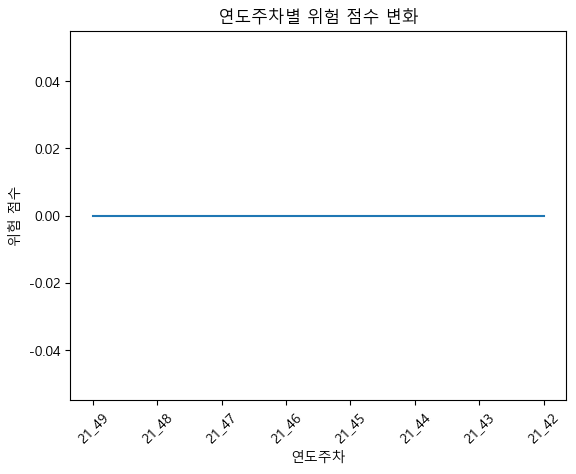

HS Code : 8544422090
21_49주차
0    18.150
1    18.275
2    18.896
3    18.444
4    17.789
5    18.320
6    17.953
7    18.371
8    19.266
9    19.051
10   19.459
11   20.049
12   19.321
13   19.410
14   19.554
15   18.859
16   19.067
17   18.707
18   18.396
19   18.062
20   17.683
21   18.073
22   17.843
23   18.486
24   18.727
25   18.048
26   18.282
27   18.524
28   18.565
29   18.714
30   19.329
31   18.759
32   19.044
33   19.447
34   18.185
35   18.060
36   18.017
37   17.750
38   18.403
39   18.933
40   18.584
41   19.038
42   18.972
43   18.469
44   19.475
45   19.720
46   19.434
47   20.475
48   19.686
49   19.832
50   19.172
51   19.781
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=445.867, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]        

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    592554.243
1    594159.720
2    542417.829
3    555542.468
4    575473.396
5    556596.500
6    608890.774
7    619072.457
8    596437.152
9    587936.560
10   535538.496
11   502699.259
12   529489.940
13   551338.563
14   609617.063
15   651213.323
16   662395.741
17   679611.653
18   690655.017
19   704209.197
20   708044.196
21   693730.049
22   693236.784
23   648364.668
24   651708.669
25   658263.496
26   642450.528
27   637310.535
28   641261.290
29   646440.738
30   644340.554
31   658469.509
32   623322.266
33   578704.487
34   610574.283
35   601538.838
36   613575.430
37   678850.777
38   626588.502
39   643880.257
40   592754.735
41   575369.397
42   569907.662
43   544593.456
44   562571.419
45   542053.535
46   589463.106
47   579034.367
48   608628.172
49   595439.399
50   609342.726
51   618771.152
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    18.501
1    18.265
2    18.150
3    18.275
4    18.896
5    18.444
6    17.789
7    18.320
8    17.953
9    18.371
10   19.266
11   19.051
12   19.459
13   20.049
14   19.321
15   19.410
16   19.554
17   18.859
18   19.067
19   18.707
20   18.396
21   18.062
22   17.683
23   18.073
24   17.843
25   18.486
26   18.727
27   18.048
28   18.282
29   18.524
30   18.565
31   18.714
32   19.329
33   18.759
34   19.044
35   19.447
36   18.185
37   18.060
38   18.017
39   17.750
40   18.403
41   18.933
42   18.584
43   19.038
44   18.972
45   18.469
46   19.475
47   19.720
48   19.434
49   20.475
50   19.686
51   19.832
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=445.626, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0    17.756
1    18.105
2    18.620
3    18.598
4    18.501
5    18.265
6    18.150
7    18.275
8    18.896
9    18.444
10   17.789
11   18.320
12   17.953
13   18.371
14   19.266
15   19.051
16   19.459
17   20.049
18   19.321
19   19.410
20   19.554
21   18.859
22   19.067
23   18.707
24   18.396
25   18.062
26   17.683
27   18.073
28   17.843
29   18.486
30   18.727
31   18.048
32   18.282
33   18.524
34   18.565
35   18.714
36   19.329
37   18.759
38   19.044
39   19.447
40   18.185
41   18.060
42   18.017
43   17.750
44   18.403
45   18.933
46   18.584
47   19.038
48   18.972
49   18.469
50   19.475
51   19.720
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=444.944, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    17.362
1    17.756
2    18.105
3    18.620
4    18.598
5    18.501
6    18.265
7    18.150
8    18.275
9    18.896
10   18.444
11   17.789
12   18.320
13   17.953
14   18.371
15   19.266
16   19.051
17   19.459
18   20.049
19   19.321
20   19.410
21   19.554
22   18.859
23   19.067
24   18.707
25   18.396
26   18.062
27   17.683
28   18.073
29   17.843
30   18.486
31   18.727
32   18.048
33   18.282
34   18.524
35   18.565
36   18.714
37   19.329
38   18.759
39   19.044
40   19.447
41   18.185
42   18.060
43   18.017
44   17.750
45   18.403
46   18.933
47   18.584
48   19.038
49   18.972
50   18.469
51   19.475
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=444.719, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    638693.301
1    615523.596
2    613763.052
3    607418.906
4    607132.131
5    607795.945
6    611372.793
7    592554.243
8    594159.720
9    542417.829
10   555542.468
11   575473.396
12   556596.500
13   608890.774
14   619072.457
15   596437.152
16   587936.560
17   535538.496
18   502699.259
19   529489.940
20   551338.563
21   609617.063
22   651213.323
23   662395.741
24   679611.653
25   690655.017
26   704209.197
27   708044.196
28   693730.049
29   693236.784
30   648364.668
31   651708.669
32   658263.496
33   642450.528
34   637310.535
35   641261.290
36   646440.738
37   644340.554
38   658469.509
39   623322.266
40   578704.487
41   610574.283
42   601538.838
43   613575.430
44   678850.777
45   626588.502
46   643880.257
47   592754.735
48   575369.397
49   569907.662
50   544593.456
51   562571.419
Name: 신고중량, dtype: float64
Performing stepwise search 

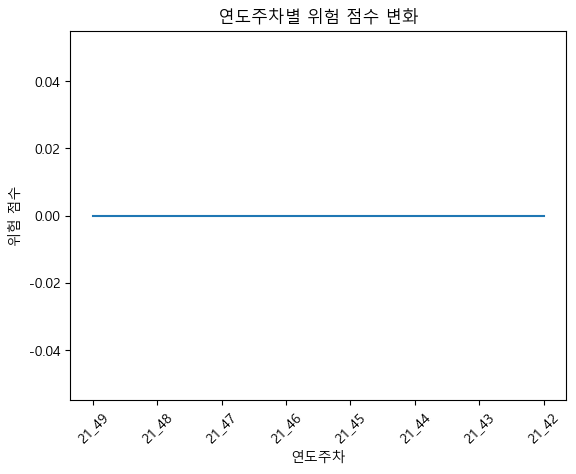

HS Code : 8537109000
21_49주차
0    121.533
1    119.151
2    121.484
3    109.484
4    103.164
5    112.247
6    105.113
7    106.896
8    105.495
9    100.688
10   108.479
11   107.766
12   130.263
13   141.074
14   136.860
15   140.723
16   121.952
17   117.837
18   116.896
19   127.843
20   112.688
21   120.568
22   118.297
23   106.699
24   129.171
25   117.856
26   120.825
27   120.359
28   117.090
29   117.314
30   120.714
31   119.751
32   121.220
33   121.785
34   114.615
35   118.646
36   119.103
37   118.774
38   114.379
39   115.288
40   110.967
41   108.241
42   113.204
43   111.172
44   108.772
45   112.590
46   116.501
47   114.967
48   125.424
49   108.517
50   114.129
51   120.655
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=632.707, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AI

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    125.462
1    121.533
2    119.151
3    121.484
4    109.484
5    103.164
6    112.247
7    105.113
8    106.896
9    105.495
10   100.688
11   108.479
12   107.766
13   130.263
14   141.074
15   136.860
16   140.723
17   121.952
18   117.837
19   116.896
20   127.843
21   112.688
22   120.568
23   118.297
24   106.699
25   129.171
26   117.856
27   120.825
28   120.359
29   117.090
30   117.314
31   120.714
32   119.751
33   121.220
34   121.785
35   114.615
36   118.646
37   119.103
38   118.774
39   114.379
40   115.288
41   110.967
42   108.241
43   113.204
44   111.172
45   108.772
46   112.590
47   116.501
48   114.967
49   125.424
50   108.517
51   114.129
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=632.904, Time=0.00 sec
 ARIMA(1

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1026.165, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1286.721, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1026.679, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1026.737, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=1016.641, Time=0.07 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1020.803, Time=0.06 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=1018.625, Time=0.15 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=1019.078, Time=0.09 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=1025.860, Time=0.07 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=1020.837, Time=0.08 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=inf, Time=0.18 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=1006.920, Time=0.06 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=1010.7

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    114.771
1    111.570
2    103.893
3     98.585
4     97.569
5     99.789
6    125.462
7    121.533
8    119.151
9    121.484
10   109.484
11   103.164
12   112.247
13   105.113
14   106.896
15   105.495
16   100.688
17   108.479
18   107.766
19   130.263
20   141.074
21   136.860
22   140.723
23   121.952
24   117.837
25   116.896
26   127.843
27   112.688
28   120.568
29   118.297
30   106.699
31   129.171
32   117.856
33   120.825
34   120.359
35   117.090
36   117.314
37   120.714
38   119.751
39   121.220
40   121.785
41   114.615
42   118.646
43   119.103
44   118.774
45   114.379
46   115.288
47   110.967
48   108.241
49   113.204
50   111.172
51   108.772
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=373.071, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=631.940, Time=0.00 sec
 ARI

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    77184.254
1    80887.032
2    85197.806
3    89650.907
4    93148.357
5    85949.515
6    71109.438
7    74592.855
8    73949.129
9    68330.765
10   69954.558
11   68034.449
12   64513.579
13   77855.183
14   76620.841
15   77345.098
16   85454.958
17   73300.009
18   76587.261
19   78790.947
20   69704.942
21   72391.245
22   68572.360
23   64021.203
24   64935.287
25   65468.412
26   62095.634
27   77515.754
28   73790.957
29   78130.993
30   80567.066
31   67788.136
32   75763.816
33   71878.339
34   72832.569
35   67338.546
36   67918.086
37   68214.203
38   72355.603
39   69023.532
40   63995.537
41   68789.229
42   64471.302
43   65153.326
44   70452.124
45   70138.466
46   74916.758
47   72811.560
48   74958.909
49   70089.915
50   65012.782
51   75079.697
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


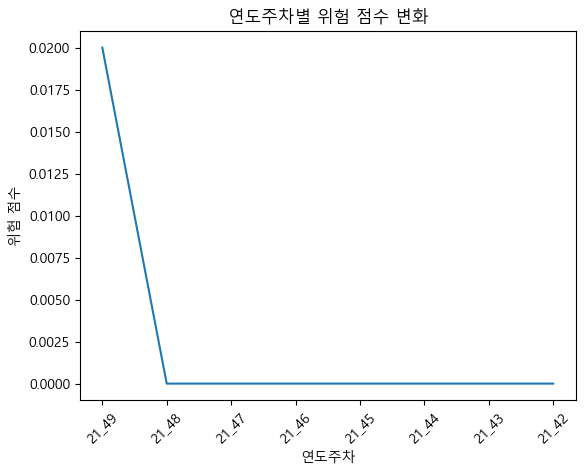

HS Code : 8536699000
21_49주차
0    39.716
1    39.465
2    36.673
3    36.482
4    33.927
5    32.773
6    36.297
7    34.217
8    33.531
9    34.163
10   33.269
11   39.946
12   42.713
13   42.639
14   42.488
15   38.892
16   37.374
17   37.257
18   36.511
19   35.134
20   37.554
21   36.604
22   34.946
23   36.903
24   36.012
25   37.228
26   42.078
27   39.141
28   35.843
29   35.608
30   33.002
31   32.177
32   34.251
33   32.591
34   35.432
35   38.719
36   37.138
37   38.715
38   36.827
39   37.694
40   37.051
41   39.277
42   38.969
43   35.232
44   39.793
45   40.547
46   37.076
47   39.193
48   36.843
49   33.335
50   35.026
51   35.547
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=515.163, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]        

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    131426.537
1    128069.363
2    127105.610
3    130369.402
4    122272.494
5    137565.283
6    149963.333
7    144977.549
8    166590.883
9    159418.604
10   152072.122
11   151573.824
12   117350.798
13   116455.800
14   112737.595
15   120929.632
16   138426.899
17   146031.757
18   153382.350
19   152844.359
20   154429.435
21   140406.318
22   136227.571
23   144984.728
24   137638.730
25   145161.396
26   147985.332
27   128614.835
28   137769.859
29   149936.850
30   142002.905
31   163849.396
32   170749.419
33   153664.103
34   151614.902
35   132697.429
36   110936.073
37   123599.201
38   123768.768
39   121213.679
40   130607.708
41   116624.726
42   117256.377
43   126526.663
44   130895.728
45   129847.120
46   131199.055
47   143075.682
48   138958.040
49   146357.837
50   154058.545
51   142992.821
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    37.575
1    38.104
2    39.716
3    39.465
4    36.673
5    36.482
6    33.927
7    32.773
8    36.297
9    34.217
10   33.531
11   34.163
12   33.269
13   39.946
14   42.713
15   42.639
16   42.488
17   38.892
18   37.374
19   37.257
20   36.511
21   35.134
22   37.554
23   36.604
24   34.946
25   36.903
26   36.012
27   37.228
28   42.078
29   39.141
30   35.843
31   35.608
32   33.002
33   32.177
34   34.251
35   32.591
36   35.432
37   38.719
38   37.138
39   38.715
40   36.827
41   37.694
42   37.051
43   39.277
44   38.969
45   35.232
46   39.793
47   40.547
48   37.076
49   39.193
50   36.843
51   33.335
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=515.545, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_44주차
0    37.763
1    36.943
2    39.263
3    37.575
4    38.104
5    39.716
6    39.465
7    36.673
8    36.482
9    33.927
10   32.773
11   36.297
12   34.217
13   33.531
14   34.163
15   33.269
16   39.946
17   42.713
18   42.639
19   42.488
20   38.892
21   37.374
22   37.257
23   36.511
24   35.134
25   37.554
26   36.604
27   34.946
28   36.903
29   36.012
30   37.228
31   42.078
32   39.141
33   35.843
34   35.608
35   33.002
36   32.177
37   34.251
38   32.591
39   35.432
40   38.719
41   37.138
42   38.715
43   36.827
44   37.694
45   37.051
46   39.277
47   38.969
48   35.232
49   39.793
50   40.547
51   37.076
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=515.591, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    39.427
1    39.129
2    37.763
3    36.943
4    39.263
5    37.575
6    38.104
7    39.716
8    39.465
9    36.673
10   36.482
11   33.927
12   32.773
13   36.297
14   34.217
15   33.531
16   34.163
17   33.269
18   39.946
19   42.713
20   42.639
21   42.488
22   38.892
23   37.374
24   37.257
25   36.511
26   35.134
27   37.554
28   36.604
29   34.946
30   36.903
31   36.012
32   37.228
33   42.078
34   39.141
35   35.843
36   35.608
37   33.002
38   32.177
39   34.251
40   32.591
41   35.432
42   38.719
43   37.138
44   38.715
45   36.827
46   37.694
47   37.051
48   39.277
49   38.969
50   35.232
51   39.793
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=515.489, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


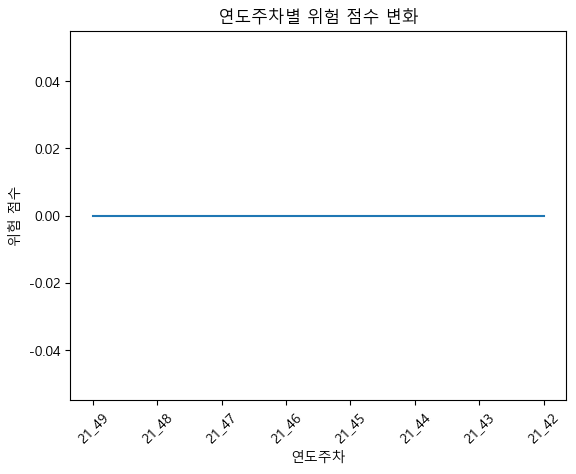

HS Code : 3102109000
21_14주차
0    0.274
1    0.275
2    0.273
3    0.273
4    0.271
5    0.269
6    0.268
7    0.266
8    0.263
9    0.263
10   0.261
11   0.258
12   0.257
13   0.254
14   0.252
15   0.253
16   0.254
17   0.254
18   0.254
19   0.254
20   0.256
21   0.268
22   0.274
23   0.278
24   0.276
25   0.275
26   0.273
27   0.276
28   0.277
29   0.278
30   0.281
31   0.284
32   0.285
33   0.285
34   0.287
35   0.287
36   0.302
37   0.307
38   0.308
39   0.310
40   0.304
41   0.304
42   0.306
43   0.310
44   0.312
45   0.320
46   0.329
47   0.332
48   0.341
49   0.347
50   0.351
51   0.360
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=-400.138, Time=0.12 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-395.166, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-399.350, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=-401.940, Time=0.04 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-397.151, Time=0.02 sec
 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     8259101.927
1     7595152.514
2     6690618.513
3     4845948.741
4     5082300.688
5     6711051.035
6     6433905.144
7     7739305.729
8     8280687.614
9     8150787.332
10    8345732.808
11    7001619.634
12    5895656.384
13    5435314.991
14    5974286.142
15    7965065.094
16    9219891.994
17    9042738.254
18   11076218.961
19    8122886.807
20    6505523.432
21    5793011.707
22    3575184.192
23    2996353.069
24    3415777.144
25    2940932.594
26    4572083.900
27    5892192.336
28    8621320.361
29   10201257.261
30    8196479.362
31    6882415.227
32    8418110.158
33    7855938.056
34    8487338.055
35    8919522.904
36    4435313.673
37    6660056.188
38    6811887.337
39    7471432.525
40    7864346.467
41    5347890.630
42    7432961.455
43    8070404.966
44    8843312.073
45   10624074.923
46    8296150.698
47    8180610.250
48    8354064.775
49  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_12주차
0    0.274
1    0.274
2    0.274
3    0.275
4    0.273
5    0.273
6    0.271
7    0.269
8    0.268
9    0.266
10   0.263
11   0.263
12   0.261
13   0.258
14   0.257
15   0.254
16   0.252
17   0.253
18   0.254
19   0.254
20   0.254
21   0.254
22   0.256
23   0.268
24   0.274
25   0.278
26   0.276
27   0.275
28   0.273
29   0.276
30   0.277
31   0.278
32   0.281
33   0.284
34   0.285
35   0.285
36   0.287
37   0.287
38   0.302
39   0.307
40   0.308
41   0.310
42   0.304
43   0.304
44   0.306
45   0.310
46   0.312
47   0.320
48   0.329
49   0.332
50   0.341
51   0.347
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-396.451, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-400.127, Time=0.04 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=-40

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     9483336.547
1     8259101.927
2     7595152.514
3     6690618.513
4     4845948.741
5     5082300.688
6     6711051.035
7     6433905.144
8     7739305.729
9     8280687.614
10    8150787.332
11    8345732.808
12    7001619.634
13    5895656.384
14    5435314.991
15    5974286.142
16    7965065.094
17    9219891.994
18    9042738.254
19   11076218.961
20    8122886.807
21    6505523.432
22    5793011.707
23    3575184.192
24    2996353.069
25    3415777.144
26    2940932.594
27    4572083.900
28    5892192.336
29    8621320.361
30   10201257.261
31    8196479.362
32    6882415.227
33    8418110.158
34    7855938.056
35    8487338.055
36    8919522.904
37    4435313.673
38    6660056.188
39    6811887.337
40    7471432.525
41    7864346.467
42    5347890.630
43    7432961.455
44    8070404.966
45    8843312.073
46   10624074.923
47    8296150.698
48    8180610.250
49  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_10주차
0    0.272
1    0.274
2    0.274
3    0.274
4    0.274
5    0.275
6    0.273
7    0.273
8    0.271
9    0.269
10   0.268
11   0.266
12   0.263
13   0.263
14   0.261
15   0.258
16   0.257
17   0.254
18   0.252
19   0.253
20   0.254
21   0.254
22   0.254
23   0.254
24   0.256
25   0.268
26   0.274
27   0.278
28   0.276
29   0.275
30   0.273
31   0.276
32   0.277
33   0.278
34   0.281
35   0.284
36   0.285
37   0.285
38   0.287
39   0.287
40   0.302
41   0.307
42   0.308
43   0.310
44   0.304
45   0.304
46   0.306
47   0.310
48   0.312
49   0.320
50   0.329
51   0.332
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=-399.722, Time=0.14 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-403.178, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-405.018, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AI

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     7794531.962
1     9470342.189
2     9167924.819
3     6927560.260
4     9483336.547
5     8259101.927
6     7595152.514
7     6690618.513
8     4845948.741
9     5082300.688
10    6711051.035
11    6433905.144
12    7739305.729
13    8280687.614
14    8150787.332
15    8345732.808
16    7001619.634
17    5895656.384
18    5435314.991
19    5974286.142
20    7965065.094
21    9219891.994
22    9042738.254
23   11076218.961
24    8122886.807
25    6505523.432
26    5793011.707
27    3575184.192
28    2996353.069
29    3415777.144
30    2940932.594
31    4572083.900
32    5892192.336
33    8621320.361
34   10201257.261
35    8196479.362
36    6882415.227
37    8418110.158
38    7855938.056
39    8487338.055
40    8919522.904
41    4435313.673
42    6660056.188
43    6811887.337
44    7471432.525
45    7864346.467
46    5347890.630
47    7432961.455
48    8070404.966
49  

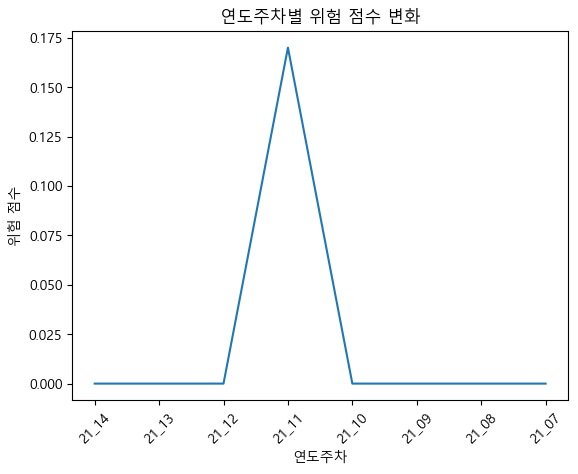

HS Code : 3707901010
19_04주차
0    271.040
1    293.099
2    289.509
3    292.766
4    282.884
5    235.897
6    226.780
7    230.105
8    229.657
9    289.352
10   281.922
11   292.480
12   276.840
13   265.564
14   274.529
15   272.450
16   271.794
17   249.537
18   275.049
19   264.655
20   275.712
21   263.955
22   257.525
23   258.863
24   226.261
25   260.158
26   232.394
27   239.664
28   243.658
29   241.069
30   270.627
31   241.770
32   275.102
33   270.882
34   274.426
35   273.856
36   243.639
37   240.823
38   231.794
39   251.146
40   277.998
41   272.614
42   292.676
43   274.076
44   287.220
45   326.250
46   296.285
47   286.282
48   246.525
49   210.616
50   234.737
51   244.200
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=715.734, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AI

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    18501.504
1    15865.119
2    20173.728
3    20496.747
4    19101.228
5    18561.987
6    19144.031
7    23132.675
8    26499.160
9    24589.869
10   24220.195
11   21052.534
12   22522.304
13   26227.010
14   24903.522
15   20615.000
16   19288.663
17   18193.278
18   18840.737
19   22285.820
20   20773.943
21   20864.880
22   20625.178
23   20649.105
24   22119.247
25   21859.940
26   24197.684
27   23064.973
28   23492.327
29   25873.863
30   23569.524
31   23905.783
32   22048.571
33   23912.596
34   22698.219
35   23856.776
36   21067.980
37   20785.282
38   27609.976
39   27166.385
40   30817.958
41   26050.878
42   22238.050
43   23637.975
44   22112.843
45   23692.447
46   24448.219
47   23265.845
48   26184.196
49   28616.635
50   23505.060
51   23269.247
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
19_01주차
0    206.006
1    173.031
2    235.521
3    271.040
4    293.099
5    289.509
6    292.766
7    282.884
8    235.897
9    226.780
10   230.105
11   229.657
12   289.352
13   281.922
14   292.480
15   276.840
16   265.564
17   274.529
18   272.450
19   271.794
20   249.537
21   275.049
22   264.655
23   275.712
24   263.955
25   257.525
26   258.863
27   226.261
28   260.158
29   232.394
30   239.664
31   243.658
32   241.069
33   270.627
34   241.770
35   275.102
36   270.882
37   274.426
38   273.856
39   243.639
40   240.823
41   231.794
42   251.146
43   277.998
44   272.614
45   292.676
46   274.076
47   287.220
48   326.250
49   296.285
50   286.282
51   246.525
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=475.507, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=715.270, Time=0.00 sec
 ARI

...

 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=922.355, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=925.911, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=925.424, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=924.054, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=924.040, Time=0.00 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=921.081, Time=0.09 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=922.355, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=922.960, Time=0.05 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=922.819, Time=0.14 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=924.296, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=924.585, Time=0.06 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=919.931, Time=0.08 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=921.466, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=922.465, Time=0.02 sec
 ARIMA(2,1,2)(0,0,0)[0]      

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    22179.855
1    22667.052
2    18501.504
3    15865.119
4    20173.728
5    20496.747
6    19101.228
7    18561.987
8    19144.031
9    23132.675
10   26499.160
11   24589.869
12   24220.195
13   21052.534
14   22522.304
15   26227.010
16   24903.522
17   20615.000
18   19288.663
19   18193.278
20   18840.737
21   22285.820
22   20773.943
23   20864.880
24   20625.178
25   20649.105
26   22119.247
27   21859.940
28   24197.684
29   23064.973
30   23492.327
31   25873.863
32   23569.524
33   23905.783
34   22048.571
35   23912.596
36   22698.219
37   23856.776
38   21067.980
39   20785.282
40   27609.976
41   27166.385
42   30817.958
43   26050.878
44   22238.050
45   23637.975
46   22112.843
47   23692.447
48   24448.219
49   23265.845
50   26184.196
51   28616.635
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    22302.226
1    25647.622
2    22179.855
3    22667.052
4    18501.504
5    15865.119
6    20173.728
7    20496.747
8    19101.228
9    18561.987
10   19144.031
11   23132.675
12   26499.160
13   24589.869
14   24220.195
15   21052.534
16   22522.304
17   26227.010
18   24903.522
19   20615.000
20   19288.663
21   18193.278
22   18840.737
23   22285.820
24   20773.943
25   20864.880
26   20625.178
27   20649.105
28   22119.247
29   21859.940
30   24197.684
31   23064.973
32   23492.327
33   25873.863
34   23569.524
35   23905.783
36   22048.571
37   23912.596
38   22698.219
39   23856.776
40   21067.980
41   20785.282
42   27609.976
43   27166.385
44   30817.958
45   26050.878
46   22238.050
47   23637.975
48   22112.843
49   23692.447
50   24448.219
51   23265.845
Name: 신고중량, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             

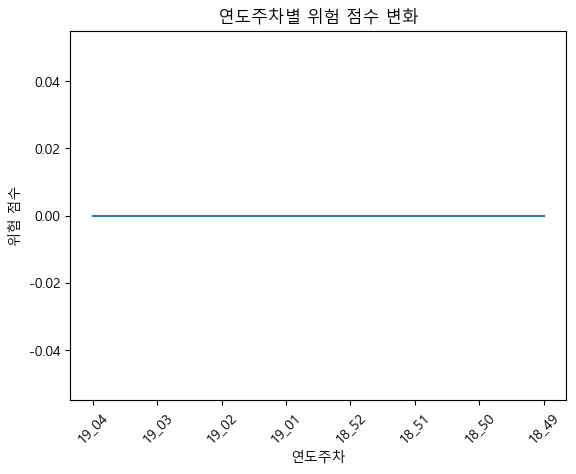

HS Code : 4407191000
20_41주차
0    1.121
1    1.127
2    1.129
3    1.277
4    1.320
5    1.341
6    1.338
7    1.299
8    1.252
9    1.252
10   1.259
11   1.247
12   1.240
13   1.188
14   1.127
15   1.129
16   1.127
17   1.160
18   1.237
19   1.268
20   1.253
21   1.261
22   1.290
23   1.208
24   1.205
25   1.207
26   1.168
27   1.273
28   1.278
29   1.296
30   1.307
31   1.282
32   1.246
33   1.225
34   1.222
35   1.217
36   1.240
37   1.241
38   1.239
39   1.256
40   1.291
41   1.279
42   1.276
43   1.256
44   1.236
45   1.272
46   1.268
47   1.283
48   1.301
49   1.275
50   1.316
51   1.192
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=169.039, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-176.375, Time=0.05 sec
 ARIMA(2,0,1)(0,0

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1185.925, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1348.556, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1199.758, Time=0.01 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=1188.701, Time=0.04 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=1348.782, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=1171.466, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=1187.280, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1189.380, Time=0.01 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=1167.629, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.11 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=1169.352, Time=0.07 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=1170.989, Time=0.04 sec
 ARIMA(3,0,1)(0,0,0)[0] interc

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    218752.500
1    142855.500
2    167602.578
3    172108.328
4    151083.578
5    195233.725
6    168487.397
7    192482.647
8    201823.397
9    183001.500
10   199930.250
11   172237.330
12   189899.330
13   200884.830
14   214903.655
15   264579.340
16   275269.840
17   236470.223
18   208230.898
19   122825.633
20    91211.383
21    94948.500
22   138382.343
23   188889.978
24   240923.167
25   245405.167
26   255033.016
27   232849.132
28   208142.443
29   212974.443
30   174660.487
31   192153.237
32   174147.462
33   208127.462
34   197927.225
35   169040.725
36   189372.250
37   165649.963
38   171324.713
39   171240.088
40   180231.838
41   141282.547
42   167364.547
43   177168.922
44   156222.672
45   213491.250
46   192786.750
47   188341.750
48   193563.500
49   174705.000
50   172996.750
51   184079.750
Name: 신고중량, dtype: float64
Performing stepwise search 

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    152585.464
1    160447.714
2    241972.706
3    220762.500
4    219813.250
5    218752.500
6    142855.500
7    167602.578
8    172108.328
9    151083.578
10   195233.725
11   168487.397
12   192482.647
13   201823.397
14   183001.500
15   199930.250
16   172237.330
17   189899.330
18   200884.830
19   214903.655
20   264579.340
21   275269.840
22   236470.223
23   208230.898
24   122825.633
25    91211.383
26    94948.500
27   138382.343
28   188889.978
29   240923.167
30   245405.167
31   255033.016
32   232849.132
33   208142.443
34   212974.443
35   174660.487
36   192153.237
37   174147.462
38   208127.462
39   197927.225
40   169040.725
41   189372.250
42   165649.963
43   171324.713
44   171240.088
45   180231.838
46   141282.547
47   167364.547
48   177168.922
49   156222.672
50   213491.250
51   192786.750
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    155226.426
1    152585.464
2    160447.714
3    241972.706
4    220762.500
5    219813.250
6    218752.500
7    142855.500
8    167602.578
9    172108.328
10   151083.578
11   195233.725
12   168487.397
13   192482.647
14   201823.397
15   183001.500
16   199930.250
17   172237.330
18   189899.330
19   200884.830
20   214903.655
21   264579.340
22   275269.840
23   236470.223
24   208230.898
25   122825.633
26    91211.383
27    94948.500
28   138382.343
29   188889.978
30   240923.167
31   245405.167
32   255033.016
33   232849.132
34   208142.443
35   212974.443
36   174660.487
37   192153.237
38   174147.462
39   208127.462
40   197927.225
41   169040.725
42   189372.250
43   165649.963
44   171324.713
45   171240.088
46   180231.838
47   141282.547
48   167364.547
49   177168.922
50   156222.672
51   213491.250
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


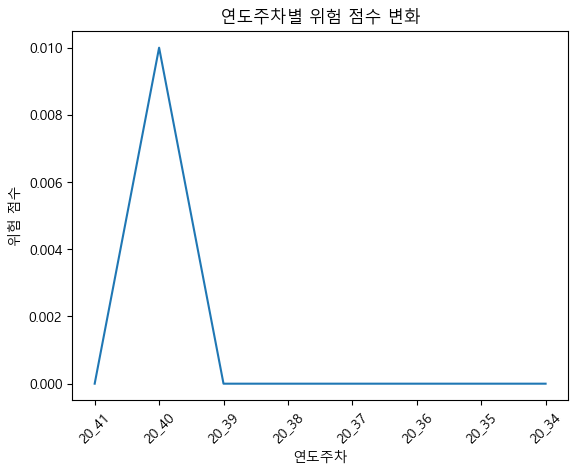

HS Code : 8111000000
21_19주차
0    1.538
1    1.546
2    1.543
3    1.550
4    1.577
5    1.559
6    1.580
7    1.593
8    1.562
9    1.523
10   1.464
11   1.446
12   1.460
13   1.466
14   1.516
15   1.498
16   1.465
17   1.462
18   1.457
19   1.449
20   1.502
21   1.525
22   1.526
23   1.536
24   1.513
25   1.520
26   1.529
27   1.524
28   1.523
29   1.519
30   1.540
31   1.577
32   1.619
33   1.670
34   1.729
35   1.849
36   1.911
37   1.981
38   2.053
39   2.281
40   2.331
41   2.448
42   2.445
43   2.461
44   2.481
45   2.490
46   2.479
47   2.496
48   2.483
49   2.499
50   2.559
51   2.567
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=-166.852, Time=0.12 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-154.473, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-169.547, Time=0.02 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=-168.615, Time=0.04 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-156.449, Time=0.01 sec
 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    2411149.567
1    2243092.258
2    2094445.660
3    1657916.090
4    1245858.371
5    1534800.232
6    1307604.550
7    1293489.455
8    1212797.974
9    1030512.490
10   1799550.890
11   1732697.468
12   1666406.519
13   1451579.890
14    881444.005
15   1486463.236
16   1926003.335
17   2151619.315
18   2236845.100
19   1560972.306
20   1526437.145
21   1216028.464
22   1503132.158
23   1716228.895
24   1499314.407
25   1864895.908
26   1838912.570
27   1881359.907
28   2331514.192
29   2123058.496
30   1726439.953
31   2127137.453
32   1450353.759
33   1715679.800
34   1913412.288
35   1845113.619
36   1992666.875
37   1927276.746
38   1775287.477
39   1647085.896
40   2087361.094
41   1930276.436
42   1892042.360
43   2327552.947
44   2080499.897
45   1978193.060
46   2013177.680
47   1261457.280
48   1229109.535
49   1599007.763
50   1391967.667
51   1454628.980
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1999301.464
1    2686076.264
2    2411149.567
3    2243092.258
4    2094445.660
5    1657916.090
6    1245858.371
7    1534800.232
8    1307604.550
9    1293489.455
10   1212797.974
11   1030512.490
12   1799550.890
13   1732697.468
14   1666406.519
15   1451579.890
16    881444.005
17   1486463.236
18   1926003.335
19   2151619.315
20   2236845.100
21   1560972.306
22   1526437.145
23   1216028.464
24   1503132.158
25   1716228.895
26   1499314.407
27   1864895.908
28   1838912.570
29   1881359.907
30   2331514.192
31   2123058.496
32   1726439.953
33   2127137.453
34   1450353.759
35   1715679.800
36   1913412.288
37   1845113.619
38   1992666.875
39   1927276.746
40   1775287.477
41   1647085.896
42   2087361.094
43   1930276.436
44   1892042.360
45   2327552.947
46   2080499.897
47   1978193.060
48   2013177.680
49   1261457.280
50   1229109.535
51   1599007.763
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1661448.784
1    1975722.300
2    1756647.361
3    1999301.464
4    2686076.264
5    2411149.567
6    2243092.258
7    2094445.660
8    1657916.090
9    1245858.371
10   1534800.232
11   1307604.550
12   1293489.455
13   1212797.974
14   1030512.490
15   1799550.890
16   1732697.468
17   1666406.519
18   1451579.890
19    881444.005
20   1486463.236
21   1926003.335
22   2151619.315
23   2236845.100
24   1560972.306
25   1526437.145
26   1216028.464
27   1503132.158
28   1716228.895
29   1499314.407
30   1864895.908
31   1838912.570
32   1881359.907
33   2331514.192
34   2123058.496
35   1726439.953
36   2127137.453
37   1450353.759
38   1715679.800
39   1913412.288
40   1845113.619
41   1992666.875
42   1927276.746
43   1775287.477
44   1647085.896
45   2087361.094
46   1930276.436
47   1892042.360
48   2327552.947
49   2080499.897
50   1978193.060
51   2013177.680
Na

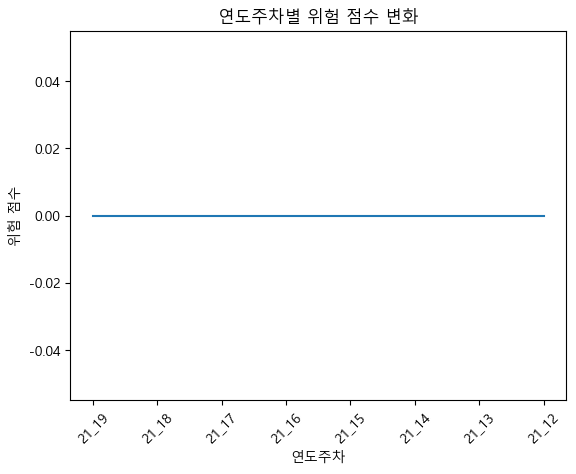

HS Code : 2701129010
21_25주차
0    0.105
1    0.106
2    0.109
3    0.105
4    0.104
5    0.104
6    0.100
7    0.104
8    0.107
9    0.104
10   0.104
11   0.096
12   0.098
13   0.097
14   0.097
15   0.100
16   0.095
17   0.096
18   0.101
19   0.105
20   0.105
21   0.104
22   0.111
23   0.106
24   0.107
25   0.107
26   0.103
27   0.107
28   0.107
29   0.110
30   0.113
31   0.116
32   0.116
33   0.126
34   0.122
35   0.119
36   0.127
37   0.123
38   0.136
39   0.134
40   0.131
41   0.127
42   0.116
43   0.115
44   0.130
45   0.130
46   0.130
47   0.131
48   0.120
49   0.128
50   0.134
51   0.134
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-376.241, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-382.124, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-381.960, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-382.677, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-383.457, Time=0.01 sec
 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     90509788.706
1     77669185.200
2    120276473.100
3    144388042.100
4    164400070.350
5    169156920.350
6    155045125.750
7    173889515.750
8    152513175.000
9    157102201.460
10   174937717.460
11   158211262.460
12   222905251.404
13   226670762.444
14   186675146.444
15   187277646.444
16   156835390.000
17   162396417.250
18   158470734.750
19   206851071.829
20   200732196.329
21   230270214.079
22   244174568.017
23   200210940.938
24   189521504.668
25   157750269.985
26   219737703.548
27   225731607.798
28   183787999.567
29   224709651.750
30   202500680.500
31   217664043.000
32   242124105.935
33   234179063.435
34   209051809.935
35   270433729.435
36   246078410.135
37   236893702.635
38   274214557.385
39   221917945.020
40   306853383.385
41   279513383.385
42   233950465.885
43   161579432.000
44   130868025.000
45   197016285.000
46   2041830

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1881.885, Time=0.01 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.071 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_22주차
0    0.114
1    0.114
2    0.106
3    0.105
4    0.106
5    0.109
6    0.105
7    0.104
8    0.104
9    0.100
10   0.104
11   0.107
12   0.104
13   0.104
14   0.096
15   0.098
16   0.097
17   0.097
18   0.100
19   0.095
20   0.096
21   0.101
22   0.105
23   0.105
24   0.104
25   0.111
26   0.106
27   0.107
28   0.107
29   0.103
30   0.107
31   0.107
32   0.110
33   0.113
34   0.116
35   0.116
36   0.126
37   0.122
38   0.119
39   0.127
40   0.123
41   0.136
42   0.134
43   0.131
44   0.127
45   0.116
46   0.115
47   0.130
48   0.130
49   0.130
50   0.131
51   0.120
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-381.630, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0] inter

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1880.349, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1882.639, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1876.424, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1878.527, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1880.958, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1878.333, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=1878.308, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1876.921, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1880.608, Time=0.01 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=1879.300, Time=0.03 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0]          
Total fit time: 0.288 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_19주차
0    0.128
1    0.127
2    0.115
3    0.114
4    0.114
5    0.106
6    0.105
7    0.106
8    0.109
9    0.105
10   0.104
11   0.104
12   0.10

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    229211413.260
1    230625663.260
2    151017434.266
3    107059723.466
4     97484538.706
5     90509788.706
6     77669185.200
7    120276473.100
8    144388042.100
9    164400070.350
10   169156920.350
11   155045125.750
12   173889515.750
13   152513175.000
14   157102201.460
15   174937717.460
16   158211262.460
17   222905251.404
18   226670762.444
19   186675146.444
20   187277646.444
21   156835390.000
22   162396417.250
23   158470734.750
24   206851071.829
25   200732196.329
26   230270214.079
27   244174568.017
28   200210940.938
29   189521504.668
30   157750269.985
31   219737703.548
32   225731607.798
33   183787999.567
34   224709651.750
35   202500680.500
36   217664043.000
37   242124105.935
38   234179063.435
39   209051809.935
40   270433729.435
41   246078410.135
42   236893702.635
43   274214557.385
44   221917945.020
45   306853383.385
46   2795133

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


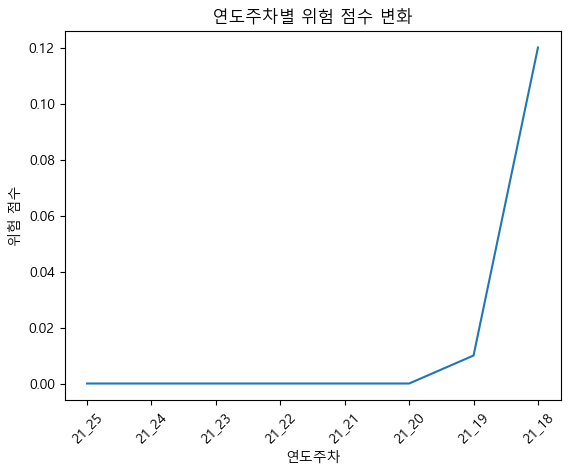

HS Code : 2804701000
21_25주차
0    3.132
1    3.061
2    3.033
3    3.104
4    3.077
5    3.083
6    3.106
7    3.078
8    3.124
9    3.050
10   3.092
11   3.035
12   3.008
13   3.051
14   3.076
15   3.085
16   3.012
17   3.027
18   2.965
19   2.976
20   3.003
21   2.965
22   2.951
23   2.920
24   2.930
25   2.884
26   2.941
27   3.446
28   3.332
29   3.499
30   3.310
31   2.799
32   2.863
33   2.831
34   2.821
35   2.890
36   2.824
37   2.865
38   2.883
39   2.876
40   2.908
41   2.917
42   2.906
43   2.891
44   2.912
45   2.931
46   2.909
47   2.869
48   2.830
49   2.816
50   2.820
51   2.829
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-72.326, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-70.475, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-68.665, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-68.668, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-72.327, Time=0.01 sec
 ARIMA

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1211.236, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1211.278, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1213.648, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.04 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.217 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_24주차
0    3.021
1    3.132
2    3.061
3    3.033
4    3.104
5    3.077
6    3.083
7    3.106
8    3.078
9    3.124
10   3.050
11   3.092
12   3.035
13   3.008
14   3.051
15   3.076
16   3.085
17   3.012
18   3.027
19   2.965
20   2.976
21   3.003
22   2.965
23   2.951
24   2.920
25   2.930
26   2.884
27   2.941
28   3.446
29   3.332
30   3.499
31   3.310
32   2.799
33   2.863
34   2.831
35   2.821
36   2.890
37   2.824
38   2.865
39   2.883
40   2.876
41   2.908
42   2.917
43   2.906
44   2.891
45   2.912
46   2.931
47   2.909
48   2.869
49 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_23주차
0    3.134
1    3.021
2    3.132
3    3.061
4    3.033
5    3.104
6    3.077
7    3.083
8    3.106
9    3.078
10   3.124
11   3.050
12   3.092
13   3.035
14   3.008
15   3.051
16   3.076
17   3.085
18   3.012
19   3.027
20   2.965
21   2.976
22   3.003
23   2.965
24   2.951
25   2.920
26   2.930
27   2.884
28   2.941
29   3.446
30   3.332
31   3.499
32   3.310
33   2.799
34   2.863
35   2.831
36   2.821
37   2.890
38   2.824
39   2.865
40   2.883
41   2.876
42   2.908
43   2.917
44   2.906
45   2.891
46   2.912
47   2.931
48   2.909
49   2.869
50   2.830
51   2.816
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=259.071, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_18주차
0    3.125
1    3.116
2    3.176
3    3.119
4    3.194
5    3.134
6    3.021
7    3.132
8    3.061
9    3.033
10   3.104
11   3.077
12   3.083
13   3.106
14   3.078
15   3.124
16   3.050
17   3.092
18   3.035
19   3.008
20   3.051
21   3.076
22   3.085
23   3.012
24   3.027
25   2.965
26   2.976
27   3.003
28   2.965
29   2.951
30   2.920
31   2.930
32   2.884
33   2.941
34   3.446
35   3.332
36   3.499
37   3.310
38   2.799
39   2.863
40   2.831
41   2.821
42   2.890
43   2.824
44   2.865
45   2.883
46   2.876
47   2.908
48   2.917
49   2.906
50   2.891
51   2.912
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=259.918, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    198930.000
1    230035.000
2    225997.500
3    158060.000
4    214722.500
5    186895.000
6    156267.500
7    202037.500
8    194845.000
9    185672.500
10   251832.500
11   203832.500
12   198382.500
13   187587.500
14   154830.000
15   172505.000
16   170010.000
17   193452.500
18   160070.000
19   140782.500
20   170230.000
21   174225.000
22   213700.000
23   257400.000
24   214935.000
25   207790.000
26   216800.000
27   149527.500
28   212565.000
29   203110.000
30   209822.500
31   240420.000
32   253835.025
33   254742.525
34   178310.470
35   196105.482
36   147182.957
37   187867.957
38   262452.513
39   280122.500
40   252057.500
41   253210.000
42   211705.000
43   222757.500
44   283655.000
45   246677.500
46   237352.500
47   224752.500
48   209272.500
49   171292.500
50   187030.000
51   150935.000
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


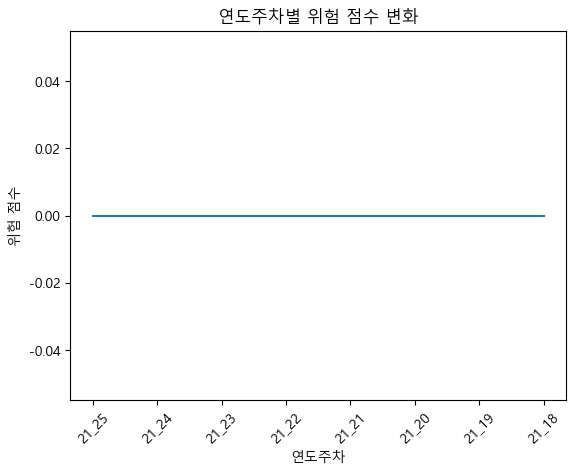

HS Code : 1511901000
21_29주차
0    0.621
1    0.643
2    0.646
3    0.620
4    0.620
5    0.633
6    0.627
7    0.642
8    0.653
9    0.646
10   0.699
11   0.680
12   0.695
13   0.698
14   0.730
15   0.771
16   0.784
17   0.794
18   0.788
19   0.843
20   0.879
21   0.869
22   0.869
23   0.905
24   0.919
25   0.948
26   0.938
27   0.929
28   0.964
29   0.970
30   1.038
31   1.039
32   1.047
33   1.055
34   1.030
35   1.030
36   1.033
37   1.022
38   1.038
39   1.037
40   1.030
41   1.036
42   1.043
43   1.050
44   1.048
45   1.040
46   1.088
47   1.083
48   1.091
49   1.091
50   1.162
51   1.105
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-229.005, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-235.939, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-235.045, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-235.083, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-227.076, Time=0.00 sec
 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=1453.584, Time=0.04 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1452.761, Time=0.01 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1450.748, Time=0.04 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=1440.317, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=1445.084, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1446.200, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=1451.323, Time=0.04 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1444.074, Time=0.02 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=1442.893, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=1446.708, Time=0.04 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1251654.250
1    1262784.250
2    1262809.750
3     149505.000
4     492634.500
5    1029870.750
6    1029830.375
7    1533380.425
8    1570067.175
9    1172577.175
10   1297327.624
11    787420.574
12    275626.824
13    622862.725
14    801885.201
15    926696.951
16   1303057.951
17   1215280.800
18   1492678.275
19   1375801.525
20    999440.631
21   1263995.631
22    963353.856
23   1457994.656
24   1457994.550
25   1537650.550
26   1535177.550
27   1032601.750
28   1655937.250
29    901391.250
30    973333.000
31   1148300.000
32   1083733.000
33   1088981.800
34    763810.916
35   1151875.166
36   1176337.916
37   1176921.116
38   1216909.500
39    654403.250
40   1242982.505
41   1237151.685
42   1172861.685
43   1246969.185
44    993985.680
45   1034286.500
46   1033762.562
47    959130.562
48    998984.062
49    958687.062
50   1065545.500
51   1065545.000
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1441.460, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1446.364, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1446.226, Time=0.06 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=1447.211, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1435.069, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1433.151, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1432.372, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1436.973, Time=0.00 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=1433.821, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1431.039, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1433.063, Time=0.01 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.447 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_24주차
0    0.637
1  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     959069.039
1     959084.039
2    1125508.750
3    1251654.250
4    1262784.250
5    1262809.750
6     149505.000
7     492634.500
8    1029870.750
9    1029830.375
10   1533380.425
11   1570067.175
12   1172577.175
13   1297327.624
14    787420.574
15    275626.824
16    622862.725
17    801885.201
18    926696.951
19   1303057.951
20   1215280.800
21   1492678.275
22   1375801.525
23    999440.631
24   1263995.631
25    963353.856
26   1457994.656
27   1457994.550
28   1537650.550
29   1535177.550
30   1032601.750
31   1655937.250
32    901391.250
33    973333.000
34   1148300.000
35   1083733.000
36   1088981.800
37    763810.916
38   1151875.166
39   1176337.916
40   1176921.116
41   1216909.500
42    654403.250
43   1242982.505
44   1237151.685
45   1172861.685
46   1246969.185
47    993985.680
48   1034286.500
49   1033762.562
50    959130.562
51    998984.062
Na

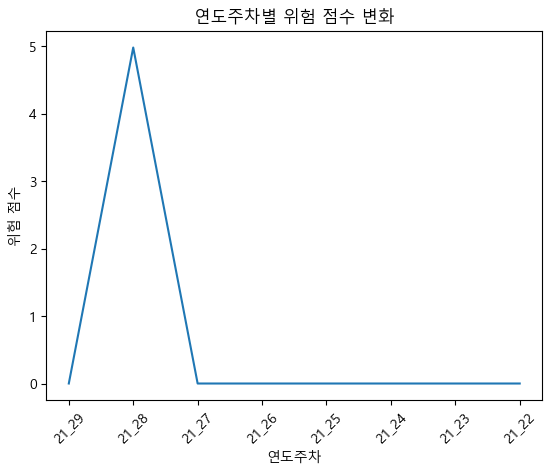

HS Code : 305531000
21_34주차
0    10.457
1    10.291
2    10.331
3    10.352
4    10.652
5    10.680
6    10.556
7    10.204
8    10.238
9     9.965
10    9.833
11   10.247
12   10.184
13   10.669
14   10.382
15   10.074
16   10.266
17    9.824
18   10.194
19   10.391
20    9.905
21    9.881
22    9.969
23    9.967
24    9.942
25   10.309
26   10.195
27   10.037
28   10.390
29   10.453
30   10.162
31    9.852
32    9.621
33    9.196
34    9.350
35    9.638
36   10.013
37    9.977
38   10.147
39   10.167
40    9.490
41    9.620
42    9.601
43    9.705
44   10.421
45   10.462
46   10.554
47   10.553
48   10.477
49   10.527
50   10.073
51   10.360
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=382.936, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]         

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    156099.745
1    164037.820
2    163524.378
3    155503.128
4    141043.857
5    139208.357
6    138356.500
7    163140.750
8    196490.750
9    203363.500
10   196634.500
11   166431.098
12   157746.348
13   151943.742
14   153117.812
15   168043.858
16   182001.148
17   188950.253
18   180399.433
19   177167.290
20   144132.675
21   127121.125
22   144520.875
23   123379.325
24   127691.400
25   109895.575
26    94605.349
27   119550.149
28   125476.449
29   146197.870
30   150753.546
31   140290.640
32   128867.112
33   114120.290
34   106992.423
35   101408.020
36   121817.874
37   125381.400
38   152749.953
39   164129.761
40   156312.136
41   155368.886
42   131997.200
43   147524.700
44   141420.950
45   163775.950
46   152476.650
47   135051.675
48   136310.425
49   121478.925
50   122820.025
51   123487.025
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_31주차
0    10.197
1    10.688
2    10.661
3    10.457
4    10.291
5    10.331
6    10.352
7    10.652
8    10.680
9    10.556
10   10.204
11   10.238
12    9.965
13    9.833
14   10.247
15   10.184
16   10.669
17   10.382
18   10.074
19   10.266
20    9.824
21   10.194
22   10.391
23    9.905
24    9.881
25    9.969
26    9.967
27    9.942
28   10.309
29   10.195
30   10.037
31   10.390
32   10.453
33   10.162
34    9.852
35    9.621
36    9.196
37    9.350
38    9.638
39   10.013
40    9.977
41   10.147
42   10.167
43    9.490
44    9.620
45    9.601
46    9.705
47   10.421
48   10.462
49   10.554
50   10.553
51   10.477
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=18.082, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=20.008, Time=0.01 s

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_29주차
0    10.055
1    10.136
2    10.197
3    10.688
4    10.661
5    10.457
6    10.291
7    10.331
8    10.352
9    10.652
10   10.680
11   10.556
12   10.204
13   10.238
14    9.965
15    9.833
16   10.247
17   10.184
18   10.669
19   10.382
20   10.074
21   10.266
22    9.824
23   10.194
24   10.391
25    9.905
26    9.881
27    9.969
28    9.967
29    9.942
30   10.309
31   10.195
32   10.037
33   10.390
34   10.453
35   10.162
36    9.852
37    9.621
38    9.196
39    9.350
40    9.638
41   10.013
42    9.977
43   10.147
44   10.167
45    9.490
46    9.620
47    9.601
48    9.705
49   10.421
50   10.462
51   10.554
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=18.096, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=20.050, Time=0.01 s

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_27주차
0    10.423
1     9.967
2    10.055
3    10.136
4    10.197
5    10.688
6    10.661
7    10.457
8    10.291
9    10.331
10   10.352
11   10.652
12   10.680
13   10.556
14   10.204
15   10.238
16    9.965
17    9.833
18   10.247
19   10.184
20   10.669
21   10.382
22   10.074
23   10.266
24    9.824
25   10.194
26   10.391
27    9.905
28    9.881
29    9.969
30    9.967
31    9.942
32   10.309
33   10.195
34   10.037
35   10.390
36   10.453
37   10.162
38    9.852
39    9.621
40    9.196
41    9.350
42    9.638
43   10.013
44    9.977
45   10.147
46   10.167
47    9.490
48    9.620
49    9.601
50    9.705
51   10.421
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=13.990, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=15.720, Time=0.01 s

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


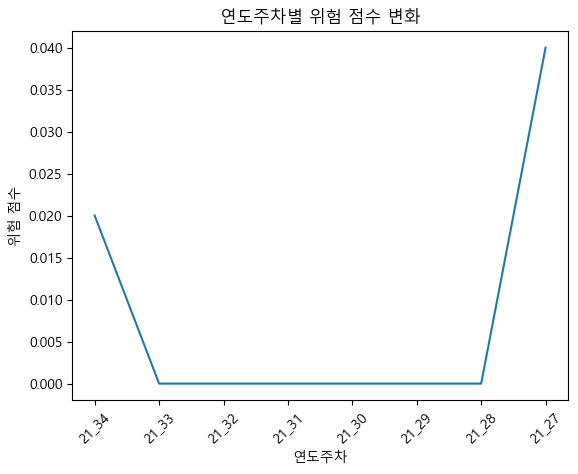

HS Code : 302140000
21_35주차
0     9.204
1     9.142
2     9.207
3     9.397
4     9.213
5     8.929
6     8.595
7     8.103
8     7.817
9     7.567
10    7.347
11    7.301
12    7.314
13    7.361
14    7.389
15    7.522
16    7.879
17    8.235
18    8.375
19    8.449
20    8.298
21    8.031
22    7.962
23    8.044
24    8.228
25    8.719
26    9.300
27    9.672
28    9.979
29   10.184
30   10.329
31   10.529
32   10.716
33   10.961
34   11.144
35   11.442
36   11.862
37   12.057
38   11.951
39   11.591
40   11.142
41   10.882
42   10.815
43   10.860
44   10.877
45   10.978
46   11.150
47   11.291
48   11.276
49   10.982
50   10.477
51    9.980
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-54.249, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9.660, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-40.573, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-37.273, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    432161.413
1    457808.887
2    494310.018
3    518436.598
4    520939.741
5    515701.217
6    509818.949
7    509845.362
8    511369.361
9    511072.253
10   511432.891
11   516992.998
12   505040.093
13   514337.020
14   515077.465
15   554803.830
16   590383.615
17   599942.585
18   594274.117
19   564973.938
20   556900.944
21   560299.449
22   559853.442
23   567748.774
24   588090.171
25   590361.155
26   615575.662
27   615668.297
28   608740.494
29   627113.382
30   585409.915
31   590562.853
32   581756.949
33   566239.359
34   605266.935
35   607921.714
36   610291.216
37   587542.344
38   568714.768
39   554575.273
40   548016.885
41   551181.215
42   555615.528
43   545638.383
44   529042.071
45   525406.401
46   509545.128
47   500883.440
48   518561.440
49   510946.748
50   514015.178
51   528387.253
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_34주차
0     9.252
1     9.204
2     9.142
3     9.207
4     9.397
5     9.213
6     8.929
7     8.595
8     8.103
9     7.817
10    7.567
11    7.347
12    7.301
13    7.314
14    7.361
15    7.389
16    7.522
17    7.879
18    8.235
19    8.375
20    8.449
21    8.298
22    8.031
23    7.962
24    8.044
25    8.228
26    8.719
27    9.300
28    9.672
29    9.979
30   10.184
31   10.329
32   10.529
33   10.716
34   10.961
35   11.144
36   11.442
37   11.862
38   12.057
39   11.951
40   11.591
41   11.142
42   10.882
43   10.815
44   10.860
45   10.877
46   10.978
47   11.150
48   11.291
49   11.276
50   10.982
51   10.477
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-55.801, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5.197, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-43.731, Time=0.

...

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-59.910, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3.758, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-47.138, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-44.885, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2.539, Time=0.00 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-61.342, Time=0.06 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-57.140, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-63.245, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-61.400, Time=0.07 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-57.552, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-65.076, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-46.273, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-49.081, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-63.254, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-63.189, Time=0.06 sec
 ARIMA(0,1,2)(0,0,0)[0]      

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    421865.923
1    431053.489
2    430721.924
3    441177.274
4    439893.064
5    441531.940
6    429810.985
7    432161.413
8    457808.887
9    494310.018
10   518436.598
11   520939.741
12   515701.217
13   509818.949
14   509845.362
15   511369.361
16   511072.253
17   511432.891
18   516992.998
19   505040.093
20   514337.020
21   515077.465
22   554803.830
23   590383.615
24   599942.585
25   594274.117
26   564973.938
27   556900.944
28   560299.449
29   559853.442
30   567748.774
31   588090.171
32   590361.155
33   615575.662
34   615668.297
35   608740.494
36   627113.382
37   585409.915
38   590562.853
39   581756.949
40   566239.359
41   605266.935
42   607921.714
43   610291.216
44   587542.344
45   568714.768
46   554575.273
47   548016.885
48   551181.215
49   555615.528
50   545638.383
51   529042.071
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


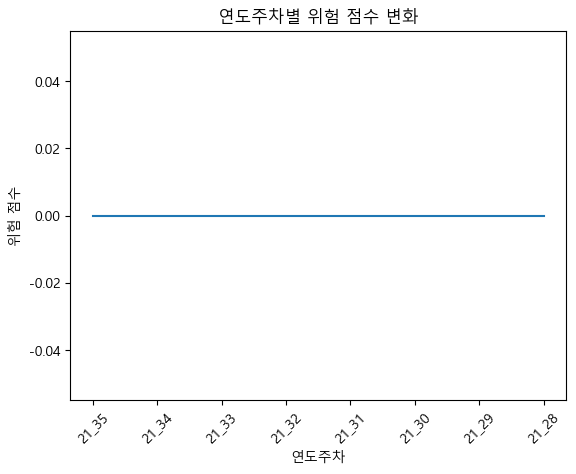

HS Code : 1003901000
21_34주차
0    0.236
1    0.236
2    0.231
3    0.233
4    0.234
5    0.234
6    0.258
7    0.285
8    0.285
9    0.241
10   0.241
11   0.233
12   0.237
13   0.238
14   0.240
15   0.238
16   0.232
17   0.232
18   0.229
19   0.229
20   0.223
21   0.221
22   0.218
23   0.218
24   0.216
25   0.216
26   0.216
27   0.217
28   0.217
29   0.217
30   0.217
31   0.216
32   0.216
33   0.216
34   0.216
35   0.223
36   0.225
37   0.227
38   0.224
39   0.216
40   0.222
41   0.222
42   0.224
43   0.226
44   0.224
45   0.231
46   0.228
47   0.230
48   0.228
49   0.223
50   0.225
51   0.219
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-329.682, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-328.923, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-328.078, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-328.683, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-330.891, Time=0.01 sec
 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1403.351, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1404.279, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1398.471, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1430.015, Time=0.00 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1399.267, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1400.732, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1406.715, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.05 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.289 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_32주차
0    0.263
1    0.410
2    0.236
3    0.236
4    0.231
5    0.233
6    0.234
7    0.234
8    0.258
9    0.285
10   0.285
11   0.241
12   0.241
13   0.233
14   0.237
15   0.238
16   0.240
17   0.238
18   0.232
19   0.2

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     506892.750
1     214265.250
2      10000.250
3     540667.500
4     540667.500
5    1053037.750
6    1170537.750
7     639870.250
8     639870.250
9     117500.000
10     56103.500
11     56103.500
12    263538.500
13    528096.500
14    679440.500
15   1055146.750
16    951616.750
17    842628.525
18    947456.025
19    881299.775
20    984647.275
21    932840.000
22    620565.000
23    727777.500
24    520525.000
25    624857.500
26    833205.000
27    623622.500
28    932005.000
29    828835.000
30    717547.500
31    615187.500
32    411495.000
33    364135.000
34    267075.000
35    417842.500
36    604052.500
37    648885.000
38    808762.000
39    630552.000
40    520297.000
41    703284.500
42    697550.000
43    855198.250
44    934663.250
45    959354.500
46    805212.000
47    841536.250
48    820790.750
49    843592.000
50   1156483.500
51   1040701.000
Na

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    1021607.500
1     711732.750
2     506892.750
3     214265.250
4      10000.250
5     540667.500
6     540667.500
7    1053037.750
8    1170537.750
9     639870.250
10    639870.250
11    117500.000
12     56103.500
13     56103.500
14    263538.500
15    528096.500
16    679440.500
17   1055146.750
18    951616.750
19    842628.525
20    947456.025
21    881299.775
22    984647.275
23    932840.000
24    620565.000
25    727777.500
26    520525.000
27    624857.500
28    833205.000
29    623622.500
30    932005.000
31    828835.000
32    717547.500
33    615187.500
34    411495.000
35    364135.000
36    267075.000
37    417842.500
38    604052.500
39    648885.000
40    808762.000
41    630552.000
42    520297.000
43    703284.500
44    697550.000
45    855198.250
46    934663.250
47    959354.500
48    805212.000
49    841536.250
50    820790.750
51    843592.000
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1389.676, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1480.021, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1405.964, Time=0.01 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=1390.658, Time=0.11 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=1481.468, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=1377.978, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=1392.452, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1397.369, Time=0.01 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=1376.519, Time=0.07 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=1373.417, Time=0.03 sec
 ARIMA(0,0,4)(0,0,0)[0] intercept   : AIC=1369.965, Time=0.08 sec
 ARIMA(1,0,4)(0,0,0)[0] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(0,0,5)(0,0,0)[0] interc

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     931560.000
1    1026820.000
2    1021607.500
3     711732.750
4     506892.750
5     214265.250
6      10000.250
7     540667.500
8     540667.500
9    1053037.750
10   1170537.750
11    639870.250
12    639870.250
13    117500.000
14     56103.500
15     56103.500
16    263538.500
17    528096.500
18    679440.500
19   1055146.750
20    951616.750
21    842628.525
22    947456.025
23    881299.775
24    984647.275
25    932840.000
26    620565.000
27    727777.500
28    520525.000
29    624857.500
30    833205.000
31    623622.500
32    932005.000
33    828835.000
34    717547.500
35    615187.500
36    411495.000
37    364135.000
38    267075.000
39    417842.500
40    604052.500
41    648885.000
42    808762.000
43    630552.000
44    520297.000
45    703284.500
46    697550.000
47    855198.250
48    934663.250
49    959354.500
50    805212.000
51    841536.250
Na

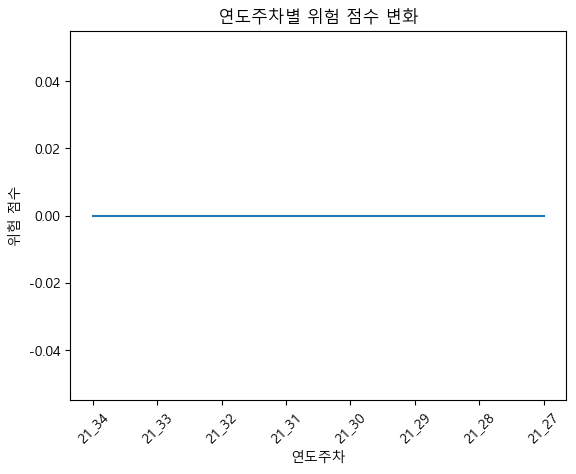

HS Code : 1003902000
21_34주차
0    0.284
1    0.252
2    0.238
3    0.228
4    0.224
5    0.224
6    0.228
7    0.285
8    0.266
9    0.244
10   0.243
11   0.218
12   0.217
13   0.206
14   0.210
15   0.211
16   0.213
17   0.215
18   0.217
19   0.224
20   0.225
21   0.242
22   0.249
23   0.250
24   0.250
25   0.250
26   0.244
27   0.239
28   0.236
29   0.247
30   0.254
31   0.254
32   0.246
33   0.256
34   0.283
35   0.283
36   0.283
37   0.282
38   0.278
39   0.272
40   0.272
41   0.269
42   0.281
43   0.293
44   0.293
45   0.287
46   0.268
47   0.269
48   0.269
49   0.277
50   0.279
51   0.289
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-280.853, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-287.776, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-286.598, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-286.708, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-289.772, Time=0.01 sec
 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     108114.500
1      80120.000
2     154445.000
3     149445.000
4     100475.000
5     100450.000
6      26125.000
7      56032.500
8      83782.500
9     161507.500
10    167257.500
11    189280.000
12    161530.000
13    109610.000
14    131335.000
15    199960.000
16    227122.500
17    175192.500
18    255790.000
19    135235.000
20    153807.500
21    998147.500
22   3067715.000
23   3253485.000
24   3652617.500
25   2992217.500
26    869097.500
27    683327.500
28    269977.500
29    164995.000
30    298164.750
31    298164.750
32    266651.000
33    235016.000
34    249818.000
35    249818.000
36    249814.250
37    376146.750
38    252635.000
39    380320.000
40    380320.000
41    357498.000
42    360203.750
43    232518.975
44    232518.975
45    156960.975
46    225107.725
47    278897.500
48    278897.500
49    229272.500
50     96159.750
51     42369.750
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,3)(0,0,0)[0]             : AIC=1458.483, Time=0.05 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=1456.636, Time=0.07 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=1474.924, Time=0.04 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=1459.183, Time=0.07 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1500.158, Time=0.01 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=1470.783, Time=0.03 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=1459.989, Time=0.09 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=1454.423, Time=0.04 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=1463.579, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=1470.915, Time=0.04 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=1456.322, Time=0.06 sec
 ARIMA(1,0,4)(0,0,0)[0] intercept   : AIC=1458.232, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=1492.415, Time=0.02 sec
 ARIMA(0,0,4)(0,0,0)[0] intercept   : AIC=1462.256, Time=0.04 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=1465.152, Time=0.03 sec
 ARIMA(2,0

...

 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=1458.489, Time=0.04 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=1456.642, Time=0.04 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=1475.030, Time=0.02 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=1459.165, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1500.169, Time=0.01 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=1470.893, Time=0.03 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=1459.939, Time=0.12 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=1454.362, Time=0.05 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=1463.636, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=1470.871, Time=0.04 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=1456.261, Time=0.06 sec
 ARIMA(1,0,4)(0,0,0)[0] intercept   : AIC=1458.114, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=1492.527, Time=0.02 sec
 ARIMA(0,0,4)(0,0,0)[0] intercept   : AIC=1462.184, Time=0.04 sec
 ARIMA(2,0,2)(0

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     269967.750
1     154560.250
2     154214.750
3     105364.500
4     110364.500
5     108114.500
6      80120.000
7     154445.000
8     149445.000
9     100475.000
10    100450.000
11     26125.000
12     56032.500
13     83782.500
14    161507.500
15    167257.500
16    189280.000
17    161530.000
18    109610.000
19    131335.000
20    199960.000
21    227122.500
22    175192.500
23    255790.000
24    135235.000
25    153807.500
26    998147.500
27   3067715.000
28   3253485.000
29   3652617.500
30   2992217.500
31    869097.500
32    683327.500
33    269977.500
34    164995.000
35    298164.750
36    298164.750
37    266651.000
38    235016.000
39    249818.000
40    249818.000
41    249814.250
42    376146.750
43    252635.000
44    380320.000
45    380320.000
46    357498.000
47    360203.750
48    232518.975
49    232518.975
50    156960.975
51    225107.725
Na

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     347832.500
1     321587.750
2     269967.750
3     154560.250
4     154214.750
5     105364.500
6     110364.500
7     108114.500
8      80120.000
9     154445.000
10    149445.000
11    100475.000
12    100450.000
13     26125.000
14     56032.500
15     83782.500
16    161507.500
17    167257.500
18    189280.000
19    161530.000
20    109610.000
21    131335.000
22    199960.000
23    227122.500
24    175192.500
25    255790.000
26    135235.000
27    153807.500
28    998147.500
29   3067715.000
30   3253485.000
31   3652617.500
32   2992217.500
33    869097.500
34    683327.500
35    269977.500
36    164995.000
37    298164.750
38    298164.750
39    266651.000
40    235016.000
41    249818.000
42    249818.000
43    249814.250
44    376146.750
45    252635.000
46    380320.000
47    380320.000
48    357498.000
49    360203.750
50    232518.975
51    232518.975
Na

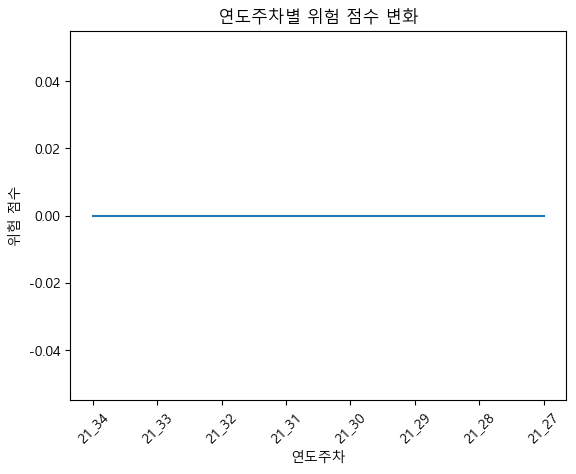

HS Code : 1104230000
21_34주차
0    0.397
1    0.396
2    0.391
3    0.394
4    0.406
5    0.404
6    0.409
7    0.406
8    0.402
9    0.392
10   0.383
11   0.359
12   0.359
13   0.359
14   0.359
15   0.360
16   6.909
17   8.119
18   0.416
19   0.402
20   0.403
21   0.400
22   0.377
23   0.386
24   0.402
25   0.407
26   0.415
27   0.410
28   0.404
29   0.412
30   0.411
31   0.414
32   0.410
33   0.424
34   0.414
35   0.418
36   0.420
37   0.408
38   0.414
39   0.407
40   0.405
41   0.392
42   0.392
43   0.392
44   0.394
45   0.394
46   0.396
47   0.397
48   0.395
49   0.395
50   0.394
51   0.394
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=190.972, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=173.115, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=162.527, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=164.148, Time=0.01 sec
 ARIMA(0,0

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1331.435, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1418.805, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1332.399, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1332.190, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1331.416, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1333.325, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1333.116, Time=0.01 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=1334.136, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=1333.651, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1325.462, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1324.395, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1338.276, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1325.382, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=1325.623, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1365.387, Time=0.00 sec
 ARIMA(0,0

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    356750.625
1    199500.625
2    199500.625
3    294500.625
4    384750.000
5    429250.000
6    516750.612
7    491500.612
8    562650.613
9    560900.613
10   502150.000
11   432400.000
12   332750.500
13   256750.500
14   180500.500
15   217313.000
16   112812.500
17    79567.800
18    36817.800
19       12.050
20       24.725
21   365769.425
22   498780.800
23   577286.988
24   667524.312
25   368274.537
26   235263.788
27   449250.850
28   359001.392
29   432751.167
30   475500.542
31   323250.542
32   405750.000
33   345500.125
34   364500.125
35   295501.375
36   255501.375
37   341751.250
38   467001.250
39   424251.000
40   394501.000
41   285251.000
42    98251.000
43   131500.000
44   213750.000
45   237500.000
46   266000.000
47   300750.000
48   262750.000
49   206000.000
50   353250.000
51   485000.000
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1335.152, Time=0.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1334.248, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1336.135, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1336.026, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=1337.243, Time=0.01 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=1336.698, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1328.743, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1327.879, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1340.439, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1328.920, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=1329.060, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1367.515, Time=0.00 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=1337.415, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1327.061, Time=0.01 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=1328.329, Time=0.02 sec
 ARIMA(3,0

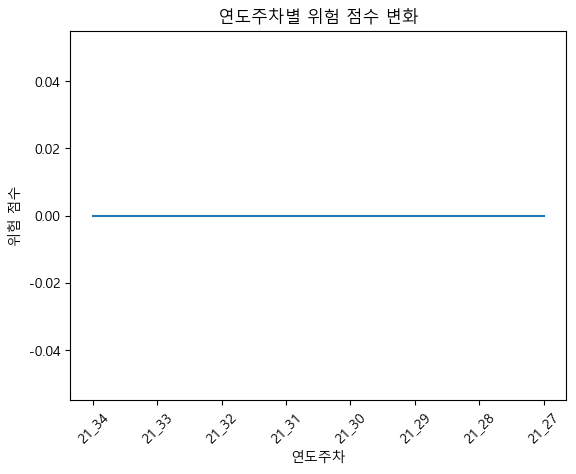

HS Code : 2710121000
21_34주차
0    0.425
1    0.427
2    0.425
3    0.423
4    0.424
5    0.415
6    0.395
7    0.388
8    0.388
9    0.386
10   0.382
11   0.382
12   0.387
13   0.395
14   0.402
15   0.405
16   0.410
17   0.435
18   0.481
19   0.480
20   0.460
21   0.485
22   0.482
23   0.505
24   0.530
25   0.556
26   0.557
27   0.587
28   0.587
29   0.598
30   0.633
31   0.647
32   0.646
33   0.642
34   0.633
35   0.622
36   0.633
37   0.634
38   0.663
39   0.658
40   0.527
41   0.571
42   0.570
43   0.559
44   0.679
45   0.687
46   0.724
47   0.730
48   0.733
49   0.733
50   0.732
51   0.782
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-203.273, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-206.832, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-205.206, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-205.196, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-206.696, Time=0.00 sec
 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     3776915.500
1     3776915.500
2     3773830.000
3     2512617.750
4     3666846.750
5    10449924.250
6    11686274.025
7     9174659.025
8    10728342.025
9     6959541.775
10   10025896.500
11   10462598.000
12    7754686.000
13    6958469.125
14    4186783.455
15    6381777.955
16   10343325.705
17    9071506.830
18    7539637.250
19    4907941.250
20    1940405.750
21    3015398.500
22    3015246.500
23    7815153.500
24   10787000.250
25    8765766.000
26   15930045.000
27   11130138.000
28   12556530.250
29   12704250.250
30    5539971.250
31    5569408.000
32     177156.750
33    1138045.250
34    7136791.200
35    8301232.700
36   11013298.730
37   14520791.730
38    8523733.280
39   11248927.030
40    8536861.000
41    3920911.075
42    4805742.575
43    3517106.575
44    4965419.825
45    4965268.250
46    4274324.250
47    1866883.750
48     418570.500
49  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     7373358.500
1     3776915.500
2     3776915.500
3     3773830.000
4     2512617.750
5     3666846.750
6    10449924.250
7    11686274.025
8     9174659.025
9    10728342.025
10    6959541.775
11   10025896.500
12   10462598.000
13    7754686.000
14    6958469.125
15    4186783.455
16    6381777.955
17   10343325.705
18    9071506.830
19    7539637.250
20    4907941.250
21    1940405.750
22    3015398.500
23    3015246.500
24    7815153.500
25   10787000.250
26    8765766.000
27   15930045.000
28   11130138.000
29   12556530.250
30   12704250.250
31    5539971.250
32    5569408.000
33     177156.750
34    1138045.250
35    7136791.200
36    8301232.700
37   11013298.730
38   14520791.730
39    8523733.280
40   11248927.030
41    8536861.000
42    3920911.075
43    4805742.575
44    3517106.575
45    4965419.825
46    4965268.250
47    4274324.250
48    1866883.750
49  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     7919316.975
1     5412275.350
2     7373358.500
3     3776915.500
4     3776915.500
5     3773830.000
6     2512617.750
7     3666846.750
8    10449924.250
9    11686274.025
10    9174659.025
11   10728342.025
12    6959541.775
13   10025896.500
14   10462598.000
15    7754686.000
16    6958469.125
17    4186783.455
18    6381777.955
19   10343325.705
20    9071506.830
21    7539637.250
22    4907941.250
23    1940405.750
24    3015398.500
25    3015246.500
26    7815153.500
27   10787000.250
28    8765766.000
29   15930045.000
30   11130138.000
31   12556530.250
32   12704250.250
33    5539971.250
34    5569408.000
35     177156.750
36    1138045.250
37    7136791.200
38    8301232.700
39   11013298.730
40   14520791.730
41    8523733.280
42   11248927.030
43    8536861.000
44    3920911.075
45    4805742.575
46    3517106.575
47    4965419.825
48    4965268.250
49  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1671.281, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=1670.587, Time=0.05 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1678.866, Time=0.03 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=1668.735, Time=0.05 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=1672.412, Time=0.05 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=1660.488, Time=0.13 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=1663.547, Time=0.04 sec
 ARIMA(5,0,3)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(5,0,2)(0,0,0)[0] intercept   : AIC=1653.405, Time=0.07 sec
 ARIMA(4,0,2)(0,0,0)[0] intercept   : AIC=1652.062, Time=0.06 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=1661.351, Time=0.06 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=1650.904, Time=0.04 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=1662.603, Time=0.03 sec
 ARIMA(4,0,0)(0,0,0)[0] i

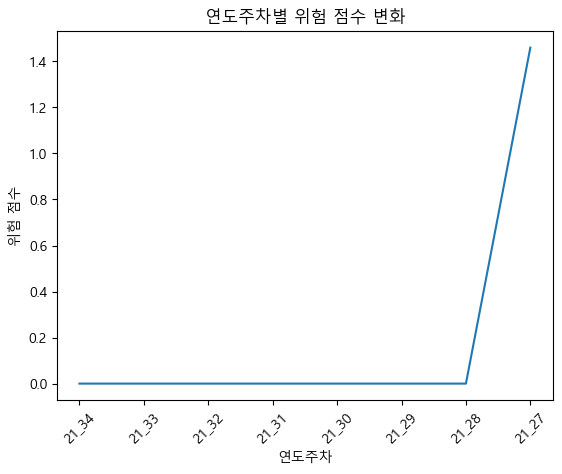

HS Code : 3104200000
21_34주차
0    0.265
1    0.264
2    0.267
3    0.265
4    0.265
5    0.266
6    0.265
7    0.264
8    0.301
9    0.266
10   0.267
11   0.267
12   0.267
13   0.286
14   0.304
15   0.268
16   0.269
17   0.270
18   0.267
19   0.270
20   0.269
21   0.268
22   0.273
23   0.271
24   0.272
25   0.269
26   0.265
27   0.271
28   0.268
29   0.272
30   0.261
31   0.260
32   0.260
33   0.260
34   0.299
35   0.280
36   0.279
37   0.280
38   0.276
39   0.299
40   0.283
41   0.283
42   0.278
43   0.278
44   0.274
45   0.280
46   0.286
47   0.288
48   0.295
49   0.343
50   0.356
51   0.368
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-274.954, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-279.355, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-279.758, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-280.298, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-280.556, Time=0.00 sec
 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     7729349.763
1     7679388.240
2     8524892.264
3     8463893.514
4     8984880.827
5     9816516.402
6     8973060.845
7     8956468.158
8      841401.158
9    15676446.743
10   17504398.025
11   17535235.902
12   17657580.584
13    2015822.659
14    1023508.009
15   10098557.994
16    9985289.768
17   12138499.133
18   19295637.995
19   10245594.258
20   11439086.318
21   10078878.595
22   17623980.602
23   18941973.165
24   19154089.112
25   26388053.882
26   10848408.987
27   10939364.025
28   17474054.190
29    9429601.715
30   23952649.830
31   23754948.883
32   16850661.767
33   17458618.276
34    3554086.133
35   12218383.606
36   12107366.281
37   11516935.784
38   10898136.424
39    2380387.074
40   12491971.349
41   13279410.200
42   21462436.948
43   21448138.023
44   18889077.523
45   32493832.810
46   27363068.125
47   28248164.212
48   19755683.589
49  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1712.635, Time=0.02 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1713.713, Time=0.04 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1716.759, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1712.979, Time=0.04 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=1715.146, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=1711.999, Time=0.02 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1714.808, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1712.300, Time=0.01 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=1713.271, Time=0.03 sec
 ARIMA(1,1,3)(0,0,0)[0]             : AIC=1713.066, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1713.964, Time=0.01 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=1713.373, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1711.067, Time=0.03 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1716.580, Time=0.01 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=1715.830, Time=0.03 sec
 ARIMA(1,1

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    15998240.953
1    16038303.377
2    14850239.602
3     5444339.000
4     7729349.763
5     7679388.240
6     8524892.264
7     8463893.514
8     8984880.827
9     9816516.402
10    8973060.845
11    8956468.158
12     841401.158
13   15676446.743
14   17504398.025
15   17535235.902
16   17657580.584
17    2015822.659
18    1023508.009
19   10098557.994
20    9985289.768
21   12138499.133
22   19295637.995
23   10245594.258
24   11439086.318
25   10078878.595
26   17623980.602
27   18941973.165
28   19154089.112
29   26388053.882
30   10848408.987
31   10939364.025
32   17474054.190
33    9429601.715
34   23952649.830
35   23754948.883
36   16850661.767
37   17458618.276
38    3554086.133
39   12218383.606
40   12107366.281
41   11516935.784
42   10898136.424
43    2380387.074
44   12491971.349
45   13279410.200
46   21462436.948
47   21448138.023
48   18889077.523
49  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0    10811701.562
1    10684741.215
2    15998240.953
3    16038303.377
4    14850239.602
5     5444339.000
6     7729349.763
7     7679388.240
8     8524892.264
9     8463893.514
10    8984880.827
11    9816516.402
12    8973060.845
13    8956468.158
14     841401.158
15   15676446.743
16   17504398.025
17   17535235.902
18   17657580.584
19    2015822.659
20    1023508.009
21   10098557.994
22    9985289.768
23   12138499.133
24   19295637.995
25   10245594.258
26   11439086.318
27   10078878.595
28   17623980.602
29   18941973.165
30   19154089.112
31   26388053.882
32   10848408.987
33   10939364.025
34   17474054.190
35    9429601.715
36   23952649.830
37   23754948.883
38   16850661.767
39   17458618.276
40    3554086.133
41   12218383.606
42   12107366.281
43   11516935.784
44   10898136.424
45    2380387.074
46   12491971.349
47   13279410.200
48   21462436.948
49  

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1740.977, Time=0.03 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=1743.000, Time=0.06 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=1743.663, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1743.960, Time=0.01 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=1743.750, Time=0.04 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1743.487, Time=0.04 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=1741.797, Time=0.09 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=1730.847, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=1734.673, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1736.332, Time=0.02 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=1732.545, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1734.374, Time=0.01 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=1731.874, Time=0.07 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=1737.289, Time=0.03 sec
 ARIMA(3,0,3)(0

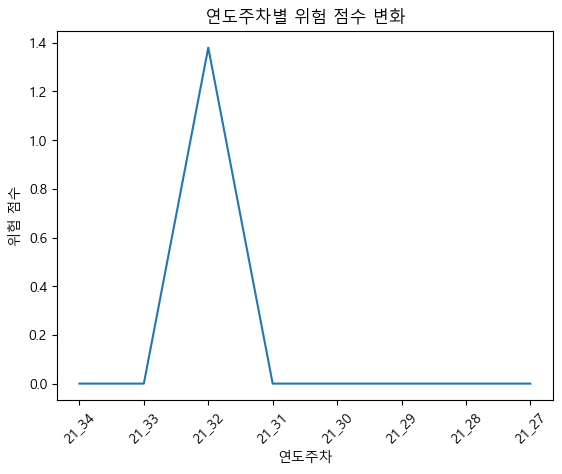

HS Code : 2905172000
21_43주차
0    1.418
1    1.404
2    1.404
3    1.385
4    1.572
5    1.555
6    1.567
7    1.605
8    1.475
9    1.488
10   1.527
11   1.552
12   1.537
13   1.632
14   1.652
15   1.632
16   1.721
17   1.638
18   1.687
19   1.763
20   1.750
21   1.776
22   1.813
23   1.771
24   1.838
25   1.870
26   1.868
27   1.884
28   1.888
29   1.972
30   1.982
31   2.164
32   2.211
33   2.363
34   2.266
35   2.237
36   2.206
37   2.106
38   2.144
39   2.074
40   2.136
41   2.217
42   2.281
43   2.268
44   2.303
45   2.208
46   2.411
47   2.438
48   2.393
49   2.378
50   2.260
51   2.278
Name: 단가, dtype: float64
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-116.817, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-116.616, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-116.322, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-116.176, Time=0.01 sec
 ARIMA

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     96282.475
1     85889.725
2     91147.250
3     98423.050
4     81478.300
5     78796.050
6     83173.275
7     87809.250
8     68608.075
9     80663.725
10    66336.850
11    49280.600
12    73217.605
13    71739.255
14    70456.130
15    79374.883
16    70663.053
17    73585.628
18    86598.553
19   112124.425
20   114662.050
21   105335.050
22    90309.875
23    77989.250
24    59863.625
25   102581.150
26   104593.403
27   103831.328
28   105693.828
29    74423.258
30    78403.830
31    91800.905
32    79802.405
33    68082.700
34    95649.625
35    88584.375
36   110632.875
37   104293.025
38   106678.025
39    75903.300
40    97053.180
41   122183.780
42    87141.280
43   103501.257
44    70622.625
45    58022.625
46    50237.625
47    52562.625
48    61041.878
49    82435.753
50    99243.253
51    89308.001
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     54228.725
1     96282.475
2     85889.725
3     91147.250
4     98423.050
5     81478.300
6     78796.050
7     83173.275
8     87809.250
9     68608.075
10    80663.725
11    66336.850
12    49280.600
13    73217.605
14    71739.255
15    70456.130
16    79374.883
17    70663.053
18    73585.628
19    86598.553
20   112124.425
21   114662.050
22   105335.050
23    90309.875
24    77989.250
25    59863.625
26   102581.150
27   104593.403
28   103831.328
29   105693.828
30    74423.258
31    78403.830
32    91800.905
33    79802.405
34    68082.700
35    95649.625
36    88584.375
37   110632.875
38   104293.025
39   106678.025
40    75903.300
41    97053.180
42   122183.780
43    87141.280
44   103501.257
45    70622.625
46    58022.625
47    50237.625
48    52562.625
49    61041.878
50    82435.753
51    99243.253
Name: 신고중량, dtype: float64
Performing stepwise search 

...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     36302.776
1     28702.776
2     29277.750
3     48503.000
4     54228.725
5     96282.475
6     85889.725
7     91147.250
8     98423.050
9     81478.300
10    78796.050
11    83173.275
12    87809.250
13    68608.075
14    80663.725
15    66336.850
16    49280.600
17    73217.605
18    71739.255
19    70456.130
20    79374.883
21    70663.053
22    73585.628
23    86598.553
24   112124.425
25   114662.050
26   105335.050
27    90309.875
28    77989.250
29    59863.625
30   102581.150
31   104593.403
32   103831.328
33   105693.828
34    74423.258
35    78403.830
36    91800.905
37    79802.405
38    68082.700
39    95649.625
40    88584.375
41   110632.875
42   104293.025
43   106678.025
44    75903.300
45    97053.180
46   122183.780
47    87141.280
48   103501.257
49    70622.625
50    58022.625
51    50237.625
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     41353.026
1     36302.776
2     28702.776
3     29277.750
4     48503.000
5     54228.725
6     96282.475
7     85889.725
8     91147.250
9     98423.050
10    81478.300
11    78796.050
12    83173.275
13    87809.250
14    68608.075
15    80663.725
16    66336.850
17    49280.600
18    73217.605
19    71739.255
20    70456.130
21    79374.883
22    70663.053
23    73585.628
24    86598.553
25   112124.425
26   114662.050
27   105335.050
28    90309.875
29    77989.250
30    59863.625
31   102581.150
32   104593.403
33   103831.328
34   105693.828
35    74423.258
36    78403.830
37    91800.905
38    79802.405
39    68082.700
40    95649.625
41    88584.375
42   110632.875
43   104293.025
44   106678.025
45    75903.300
46    97053.180
47   122183.780
48    87141.280
49   103501.257
50    70622.625
51    58022.625
Name: 신고중량, dtype: float64
Performing stepwise search 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-120.137, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-121.465, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-120.652, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-118.747, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-120.369, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-119.850, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-118.454, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-118.289, Time=0.01 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 0.280 seconds
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
0     47883.026
1     41353.026
2     36302.776
3     28702.776
4     29277.750
5     48503.000
6     54228.725
7     96282.475
8     85889.725
9     91147.250
10    98423.050
11    81478.300
12    78796.050
13    83173.

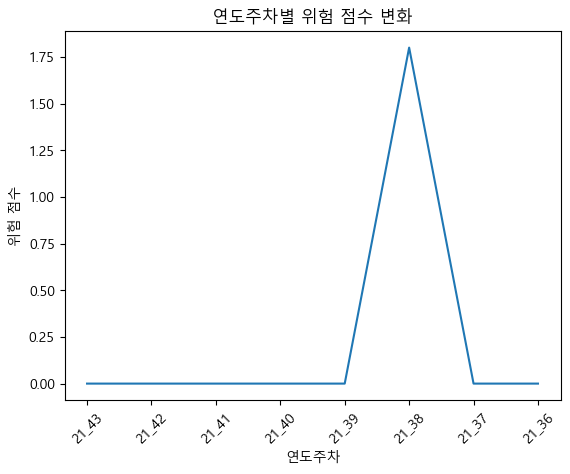

[0, 0, 0, np.float64(2.35), np.float64(0.01), 0, 0, 0, np.float64(0.12), np.float64(0.01), 0, np.float64(0.04), np.float64(0.02), 0, np.float64(0.01), np.float64(0.09), 0, np.float64(4.63), np.float64(0.13), np.float64(1.84), np.float64(0.01), 0, 0, 0, np.float64(0.01), 0, 0, np.float64(0.21), np.float64(0.03), 0, np.float64(0.01), 0, 0, np.float64(0.02), 0, np.float64(0.17), 0, np.float64(0.01), 0, np.float64(0.12), 0, np.float64(4.98), np.float64(0.04), 0, 0, 0, 0, np.float64(1.46), np.float64(1.38), np.float64(1.8)]
[0, 0, 0, 48, 42, 0, 0, 0, 44, 48, 0, 49, 44, 0, 43, 46, 0, 47, 46, 42, 44, 0, 0, 0, 43, 0, 0, 49, 44, 0, 44, 0, 0, 42, 0, 80, 0, 104, 0, 73, 0, 63, 64, 0, 0, 0, 0, 64, 59, 53]
DataFrame 길이: 15
리스트 k 길이: 50


In [3]:
리스트 = pd.read_excel('c:\python\list(m).xlsx')
추출용 = 리스트.iloc[:,0].tolist()
리스트 = pd.read_excel('c:\python\list(m1).xlsx')
b = 리스트.iloc[:,0].tolist()

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]

    

    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        res_resid = df_price_4w['단가'].iloc[p_eriod-l:-l]
        res_resid = res_resid.reset_index(drop=True)
        
        print(res_resid)
        n_test = 1
        
        train_y, test_y = res_resid[:-n_test], res_resid[-n_test:]
        
        model = pm.auto_arima(train_y, seasonal=False, trace=True)
        p, d, q = model.order

        model = SARIMAX(train_y, order=(p, d, q), seasonal_order=(1, 1, 1, 12), 
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)
        forecast1 = model_fit.forecast(steps=1)
                
        print('======================= 여기부터 GARCH 모델링 =================================')
        est_residuals = model_fit.resid
                
        # NaN 또는 inf가 있는 경우 제거하거나 대체
        est_residuals = est_residuals.replace([np.inf, -np.inf], np.nan)
        est_residuals = est_residuals.dropna()

        # GARCH에 적용
        if len(est_residuals) > 0:
            garch = arch.arch_model(est_residuals, vol="GARCH", p=1, q=1)
            garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        else:
            print("⚠ GARCH 입력 데이터가 부족합니다. 모델링 생략")
        
        print('=========== GARCH forecast =============')
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        stand_quant = (test_y.iloc[0] - forecast1.iloc[0])/ garch_std

        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)


      #=================== 신고중량 ======================
        res_resid = df_price_4w['신고중량'].iloc[p_eriod-l:-l]
        res_resid = res_resid.reset_index(drop=True)
        
        print(res_resid)
        n_test = 1
        
        train_y, test_y = res_resid[:-n_test], res_resid[-n_test:]
        
        model = pm.auto_arima(train_y, seasonal=False, trace=True)
        p, d, q = model.order

        model = SARIMAX(train_y, order=(p, d, q), seasonal_order=(1, 1, 1, 12), 
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)
        forecast1 = model_fit.forecast(steps=1)
                
        print('======================= 여기부터 GARCH 모델링 =================================')
        est_residuals = model_fit.resid
        # NaN 또는 inf가 있는 경우 제거하거나 대체
        est_residuals = est_residuals.replace([np.inf, -np.inf], np.nan)
        est_residuals = est_residuals.dropna()

        # GARCH에 적용
        if len(est_residuals) > 0:
            garch = arch.arch_model(est_residuals, vol="GARCH", p=1, q=1)
            garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        else:
            print("⚠ GARCH 입력 데이터가 부족합니다. 모델링 생략")
        
        print('=========== GARCH forecast =============')
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        stand_quant = (test_y.iloc[0] - forecast1.iloc[0])/ garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y
      
    if(z[j]<1.85):
        o[j] = 1
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)

print("DataFrame 길이:", len(collect['Model0(1)'].iloc[:-1]))
print("리스트 k 길이:", len(k))

# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:49, 'Model14(1)'] = o
collect.loc[50, 'Model14(1)'] = np.sum(o)
collect.loc[:49, 'Model14(2)'] = z
collect.loc[50, 'Model14(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[15:65, 'y_scores[15]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[15:65, 'y_scores[15]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[15:65, 'y_scores[15]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)